In [1]:
from __future__ import annotations

# Analysis Notebook with prediction of next grab based on prior model fixation

**IMPORTANT**: This is NOT for working in it. When you want to add function, download it, get a copy of it, test, add cells, idk. BUT, only upload the final functions or whatever you anted to add in teh cells already provided.

When you add code, then ALLWAYS annotate it with comments explaining what the steps do!!!!!!

**EVERYTHING should be functions based and be executed as line of code in the Cell at the very end**

## How it works
Put script with all required files in a folder.
Add folder "merged" in it containing synchronized datasets
Press "Run all"


## Input Configuration Overview

The script determines its working directories dynamically:

- **`SCRIPT_DIR`**  
  The directory containing the current Python script.  
  All output files generated during processing are saved here.

## Input Data: Merged Participant Datasets

The script expects the merged eye‑tracking and body‑tracking datasets to be located in:DATA_ROOT / "merged"

This folder contains one CSV file per participant.  
Each file represents a fully merged dataset combining:

- VR body‑tracking streams  
- Eye‑tracking streams  
- Additional metadata (timestamps, trial labels, etc.)


## Required Folder Structure and Configuration

The script expects the following folder structure relative to its own location:

```text
project_directory/
│
├── merged/                    # Input folder containing merged participant data
├── output/                    # Output folder (created automatically if it does not exist)
├── exclusion_tables.xlsx      # Excel file containing participant and model exclusions
├── x_z_variable_swap.xlsx     # Excel file specifying variables requiring X/Z swapping and inversion
└── study_project_analysis.ipynb (or the Python script)
```

## Required Configuration

### Input and Output Folders

| Variable | Description |
|----------|-------------|
| `INPUT_FOLDER` | Folder containing all merged input data files. |
| `OUTPUT_FOLDER` | Directory where all generated results are saved. The folder is created automatically if it does not already exist. |

### Participant Exclusion

| Variable | Description |
|----------|-------------|
| `PARTICIPANT_IDS_TO_EXCLUDE` | List of participant IDs that should always be excluded from the analysis (e.g., `["004", "036"]`). |

### Model Exclusion Table

The script requires an Excel file containing participant/model exclusions.

| Variable | Description |
|----------|-------------|
| `MODEL_EXCLUSION_EXCEL` | Path to `exclusion_tables.xlsx`. Set to `None` to disable model-level exclusions. |
| `MODEL_EXCLUSION_SHEET` | Name of the worksheet containing the exclusion table (`model-level_exclusion`). |

### Coordinate System Correction

Because Unity uses a different coordinate system orientation, certain variables require swapping and inversion.

| Variable | Description |
|----------|-------------|
| `excel_file` | Path to `x_z_variable_swap.xlsx`. |
| `sheet_name` | Worksheet containing the list of variables that require X/Z swapping and inversion (`Tabellenblatt1`). |

### Sampling Rate

| Variable | Description |
|----------|-------------|
| `SAMPLING_RATE_HZ` | Sampling frequency of the recorded data in Hertz. The script assumes **200 Hz**. |

# Import Libraries Needed

In [2]:
# Import Libraries
from collections.abc import Iterable
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from scipy.spatial.transform import Rotation as R
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Set the proper Paths for Input and Output

In [3]:
# Folder and sheet paths
DATA_DIR = Path("../data")
print("DATA_DIR resolves to:", DATA_DIR.resolve())

INPUT_FOLDER = DATA_DIR / "merged"  # folder with data
OUTPUT_FOLDER = DATA_DIR / "output" # where data is saved
OUTPUT_FOLDER.mkdir(exist_ok=True)

# Participant 004 not excluded anymore, because data was remerged (check: is yours redone, if not exclude 004)
PARTICIPANT_IDS_TO_EXCLUDE: list[str | int] = ["036"] # list with participants to exclude based on participant-level_exclusion sheet in exclusion_tables.xlsx
MODEL_EXCLUSION_EXCEL: Path | None = DATA_DIR / "exclusion_tables.xlsx"  # excel filepath or None to skip
MODEL_EXCLUSION_SHEET = "model-level_exclusion"  # sheet name within the Excel file for participant/model exclusions
excel_file = DATA_DIR / "x_z_variable_swap.xlsx"  # excel containing the variables which need to be switched and inverted due to Unity coordinate system orientation
sheet_name = "Tabellenblatt1" # sheet name for the x_z_variable_swap

SAMPLING_RATE_HZ = 200 # synchronized data has 200 Hz

PARTICIPANT_LIMIT: int | None = None # set to an int to only load/process the first N participant files (fast testing); set to None to process all participants

GRIP_THRESHOLD = 0.5 # grip_pressed is a continuous 0-1 value (window-averaged); a sample counts as "grabbing" when its grip value is >= this threshold

DATA_DIR resolves to: /Users/johannavenzke/Desktop/CogSci_MC/StudyProject/lego-vr-analysis/eye-classification/data


In [4]:
print(MODEL_EXCLUSION_EXCEL, MODEL_EXCLUSION_EXCEL.exists())
print(excel_file, excel_file.exists())

../data/exclusion_tables.xlsx True
../data/x_z_variable_swap.xlsx True


# Load the data

In [5]:

def participant_id_from_filename(filename: str) -> str:
    match = re.search(r"(\d{3})", filename)
    if not match:
        raise ValueError(f"Could not infer participant ID from filename: {filename}")
    return match.group(1)


def load_all_participant_data(folder: Path, limit: int | None = None) -> pd.DataFrame:
    """Load every participant CSV and add a participant/source identifier if needed.

    If ``limit`` is given, only the first ``limit`` CSV files are loaded. This is
    useful for fast testing on a single participant without reading all files.
    """
    csv_files = sorted(folder.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {folder}")

    # optionally restrict to the first N files (fast testing / lower memory use)
    if limit is not None:
        csv_files = csv_files[:limit]

    frames = []
    # progress bar over the files being read (the slow part of loading)
    for csv_file in tqdm(csv_files, desc="Loading participant CSVs", unit="file"):
        frame = pd.read_csv(csv_file, low_memory=False)
        frame = frame.loc[:, ~frame.columns.duplicated()].copy()
        if "source_file" not in frame.columns:
            frame["source_file"] = csv_file.name
        if "participant_id" not in frame.columns:
            frame["participant_id"] = participant_id_from_filename(csv_file.name)
        frame["participant_id"] = frame["participant_id"].astype("string").str.zfill(3)
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)

# Pre-processing functions

Before any analyses are performed, all participant datasets undergo a standardized preprocessing pipeline to ensure consistency across participants and experimental conditions.

## 1. Participant Exclusion

Participants listed in `PARTICIPANT_IDS_TO_EXCLUDE` are removed from the dataset. Participant IDs are converted to three-digit strings (e.g., `4` → `004`) before comparison to ensure consistent formatting.

## 2. Removal of Condition 0

All samples belonging to **condition 0** are removed. This condition is not included in subsequent analyses.

## 3. Removal of Non-Building Phases

Only samples corresponding to active model-building phases are retained. Rows with the `model_name` values:

* `TM`
* `None`

are removed, as these do not represent actual model-building tasks.

## 4. Participant-Specific Model Exclusion

Additional participant/model combinations are excluded based on the configuration specified in `exclusion_tables.xlsx` (worksheet: `model-level_exclusion`).

The exclusion table contains participant IDs and corresponding model names that should be omitted from the analyses. Each listed participant-model combination is removed while leaving all other data for that participant unchanged.

## 5. Coordinate System Correction

To account for Unity's coordinate system orientation, selected spatial variables are transformed according to the specifications in `x_z_variable_swap.xlsx`.

For every variable marked with `X_Z_Swap = TRUE`:

* the values of the **Z-axis** are multiplied by **−1**, and
* the corresponding **X** and **Z** coordinate columns are swapped.

Variables not marked for correction remain unchanged.

## 6. Technical Object Renaming

Columns containing object identifiers (i.e., columns whose names contain `obj` or `object`) are cleaned by replacing the following technical Unity objects with missing values (`None`):

* `Gaze Snap Volume`
* `XR Origin (XR Rig)`
* `Cube_Waist`

These objects represent technical components of the VR environment rather than meaningful task-related objects and are therefore excluded from subsequent object-based analyses.


## 1. Participant Exclusion

Participants listed in `PARTICIPANT_IDS_TO_EXCLUDE` are removed from the dataset. Participant IDs are converted to three-digit strings (e.g., `4` → `004`) before comparison to ensure consistent formatting.

In [6]:
def exclude_participants(
    data: pd.DataFrame,
    participant_ids_to_exclude: Iterable[str | int],
) -> pd.DataFrame:
    """Remove all rows for the provided participant IDs."""
    excluded_ids = {str(participant_id).zfill(3) for participant_id in participant_ids_to_exclude}
    participant_ids = data["participant_id"].astype("string").str.zfill(3)

    # identify actually excluded participants present in dataset
    present_excluded = sorted(set(participant_ids[participant_ids.isin(excluded_ids)].unique()))

    print(f"Excluded participants found and removed: {present_excluded}")

    return data.loc[~participant_ids.isin(excluded_ids)].copy()

## 2. Removal of Condition 0

All samples belonging to **condition 0** are removed. This condition is not included in subsequent analyses.

In [7]:
def remove_condition0(data: pd.DataFrame) -> pd.DataFrame:
    """Remove condition 0 for every participant."""
    condition_numbers = data["condition_number"].astype("string").str.strip()

    before = len(data)
    mask = condition_numbers != "0"
    data_out = data.loc[mask].copy()
    after = len(data_out)

    print(f"[remove_condition0] Removed {before - after} rows (condition 0). Remaining: {after}")

    return data_out

## 3. Removal of Non-Building Phases

Only samples corresponding to active model-building phases are retained. Rows with the `model_name` values:

* `TM`
* `None`

are removed, as these do not represent actual model-building tasks.

In [8]:
def _find_first_existing_column(
    data: pd.DataFrame,
    possible_column_names: Iterable[str],
) -> str | None:
    for column in possible_column_names:
        if column in data.columns:
            return column
    return None

def remove_specific_models_per_participant(
    data: pd.DataFrame,
    excel_path: str | Path | None,
    sheet_name: str = MODEL_EXCLUSION_SHEET,
) -> pd.DataFrame:
    """
    Remove participant/model combinations listed in an Excel sheet.
    """

    if excel_path is None:
        print("[model_exclusion] Skipped (no excel provided).")
        return data.copy()

    excel_file = Path(excel_path)
    if not excel_file.exists():
        print(f"[model_exclusion] File not found, skipped: {excel_file}")
        return data.copy()

    exclusions = pd.read_excel(excel_file, sheet_name=sheet_name, dtype="string")
    exclusions.columns = [column.strip().lower() for column in exclusions.columns]

    participant_column = _find_first_existing_column(exclusions, ["participant_id"])
    model_column = _find_first_existing_column(exclusions, ["model_name"])

    if participant_column is None or model_column is None:
        raise ValueError("Model exclusion sheet needs participant and model column.")

    exclusion_keys = set(
        zip(
            exclusions[participant_column].astype("string").str.zfill(3),
            exclusions[model_column].astype("string").str.strip(),
        )
    )

    participant_ids = data["participant_id"].astype("string").str.zfill(3)
    model_names = data["model_name"].astype("string").str.strip()
    row_keys = pd.MultiIndex.from_arrays([participant_ids, model_names])

    before = len(data)
    mask = ~row_keys.isin(exclusion_keys)
    data_out = data.loc[mask].copy()
    after = len(data_out)

    removed = before - after
    print(f"[model_exclusion] Removed {removed} rows via participant/model exclusions.")

    return data_out

## 4. Participant-Specific Model Exclusion

Additional participant/model combinations are excluded based on the configuration specified in `exclusion_tables.xlsx` (worksheet: `model-level_exclusion`).

The exclusion table contains participant IDs and corresponding model names that should be omitted from the analyses. Each listed participant-model combination is removed while leaving all other data for that participant unchanged.

In [9]:
def remove_non_building_models(data: pd.DataFrame) -> pd.DataFrame:
    """Remove TM and None model names, leaving only model-building phases."""

    model_names = data["model_name"].astype("string").str.strip()

    before = len(data)
    mask = ~model_names.isin(["TM", "None"]) & model_names.notna()
    data_out = data.loc[mask].copy()
    after = len(data_out)

    print(f"[remove_non_building_models] Removed {before - after} rows (TM/None). Remaining: {after}")

    return data_out

## 5. Coordinate System Correction

To account for Unity's coordinate system orientation, selected spatial variables are transformed according to the specifications in `x_z_variable_swap.xlsx`.

For every variable marked with `X_Z_Swap = TRUE`:

* the values of the **Z-axis** are multiplied by **−1**, and
* the corresponding **X** and **Z** coordinate columns are swapped.

Variables not marked for correction remain unchanged.

In [10]:
def swap_xz_columns(data: pd.DataFrame) -> pd.DataFrame:
    """Correct Unity X/Z convention based on external specification."""

    try:
        if excel_file.exists():
            spec = pd.read_excel(excel_file, sheet_name=sheet_name, dtype="string")
            spec.columns = [c.strip() for c in spec.columns]

            var_col = next((c for c in spec.columns if c.lower().startswith("var")), None)
            flag_col = next((c for c in spec.columns if c.lower().replace(" ", "_") == "x_z_swap"), None)

            if var_col and flag_col:
                to_swap = spec.loc[
                    spec[flag_col].astype(str).str.strip().str.lower().isin(["true"]),
                    var_col
                ].dropna().astype(str).str.strip().tolist()
            else:
                to_swap = []
        else:
            to_swap = []

    except Exception as e:
        print(f"[swap_xz_columns] Failed to read swap spec: {e}")
        to_swap = []

    rename_map = {}
    swapped_cols = []

    for col in to_swap:
        if col.endswith("_x"):
            partner = col[:-2] + "_z"
        elif col.endswith("_z"):
            partner = col[:-2] + "_x"
        else:
            continue

        if col.endswith("_z") and col in data.columns:
            data[col] = -data[col]

        if col in data.columns and partner in data.columns:
            rename_map[col] = partner
            rename_map[partner] = col
            swapped_cols.append(col)

    before_cols = len(data.columns)

    if rename_map:
        data = data.rename(columns=rename_map)

    after_cols = len(data.columns)

    print(f"[swap_xz_columns] Variables processed: {len(to_swap)} | Actually swapped: {len(swapped_cols)} | Columns: {before_cols} → {after_cols}")

    return data

## 6. Technical Object Renaming

Columns containing object identifiers (i.e., columns whose names contain `obj` or `object`) are cleaned by replacing the following technical Unity objects with missing values (`None`):

* `Gaze Snap Volume`
* `XR Origin (XR Rig)`
* `Cube_Waist`

These objects represent technical components of the VR environment rather than meaningful task-related objects and are therefore excluded from subsequent object-based analyses.

In [11]:
def tech_obj_renaming(df: pd.DataFrame):
    """Replace technical Unity object labels with None."""

    targets = ['Gaze Snap Volume', 'XR Origin (XR Rig)', 'Cube_Waist']
    changed = 0

    for col in df.columns:
        if 'obj' in col.lower() or 'object' in col.lower():
            before_unique = df[col].nunique(dropna=True)
            df[col] = df[col].replace(targets, None)
            after_unique = df[col].nunique(dropna=True)

            if before_unique != after_unique:
                changed += 1

    print(f"[tech_obj_renaming] Processed object columns: {changed}")

    return df

# Grab classification
This section defines spatial desk areas in the **post-swap X/Z coordinate frame** and classifies hand grasps by where the hand starts and ends each grab. The logic is adapted from Rivaldi & Dabria’s grasp-categorisation approach.



## Desk rectangles
Three desk areas are used:
| Desk | Source | Used for |
|------|--------|----------|
| **Resource desk** | Fixed bounds: x (−0.8, 0.6) is wrong - work is that. Let me fix | |
| **Work desk** | Fixed bounds | Grasp categorisation |
| **Resource desk** | Fixed bounds: x (0.7, 2.2), z (−0.8, 1.1) | Grasp categorisation + fixation desk assignment |
| **Work desk** | Fixed bounds: x (−0.8, 0.6), z (0.3, 1.15) | Grasp categorisation + fixation desk assignment |
| **Model desk** | Derived at runtime from template-brick `object_position_x/z` (q05–q95 + 8% padding) | Visualisation only (not used for grasp typing) |
All coordinates are in the post-swap frame (after preprocessing step 5).
## How it works for grabbing
The pipeline runs per participant via `run_grasp_analysis()`:
### Step 1 — Detect grasp episodes (`grasp_chunking`)
- For **Left** and **Right** hand separately:
- `Hand_grip_pressed` is a continuous 0–1 signal; samples with grip ≥ `GRIP_THRESHOLD` (0.5) count as “grabbing”.
- A new grasp **chunk** starts on each rising edge (not pressed → pressed).
- Each chunk gets a unique `Left_chunk_id` / `Right_chunk_id` for as long as grip stays pressed.
### Step 2 — Stabilise brick labels (`interpolate_brick_labels`)
- Within each chunk, inconsistent `Hand_grabbed_name` values are replaced by the **mode** of labels containing `brick_`.
- Reduces flicker between brick body vs. stud names during one continuous grasp.
### Step 3 — Extract onset/offset (`identify_grasp_onset_offset`)
- For each chunk, per hand and model:
  - **Onset** = first sample (time + hand position)
  - **Offset** = last sample (time + hand position)
- Timestamps use `raw_timestamp` (Unix ms).
- Also records `condition_number`, `trial_number`, and `brick_type` (grabbed object name).
### Step 4 — Classify grasp type (`categorise_grasps`)
- Compares onset and offset **hand positions** (X/Z) against the **resource** and **work** desk rectangles.
- Classification rules:
| Grasp type | Onset area | Offset area | Meaning |
|------------|------------|-------------|---------|
| **transport** | Resource | Work | Pick up from resource table, place on work table |
| **correction** | Resource | Resource | Adjust/reposition on resource table |
| **building** | Work | Work | Manipulate brick on work table |
| **returning** | Work | Resource | Move brick back to resource table |
| **unknown** | Anything else | | Does not match a rule |
### Step 5 — Validation & plotting
- `diagnose_grasp_areas()` prints quantile summaries of grasp positions vs. desk bounds.
- `derive_model_pos_from_template_bricks()` updates the model desk from template-brick gaze positions.
- `plot_grasp_areas()` draws a top-down X–Z map with desk rectangles and **transport + correction** grasps (onset → offset lines).
**Output:** one row per grasp event in `grasp_events`, with onset/offset times, positions, `grasp_type`, and metadata.


In [12]:
import pandas as pd

def grasp_chunking(df, hand):
    # label grasps by group ID (both hands are processed regardless of the `hand` argument)
    hands = ['Left', 'Right']

    for hand in hands:
        grip_col = f'{hand}Hand_grip_pressed'
        grasp_col = f'{hand}_chunk_id'

        # grip_pressed is a continuous 0-1 value in the merged data, not a boolean;
        # threshold it with the config-level GRIP_THRESHOLD to obtain a real "is pressed" mask
        grip = df[grip_col].fillna(0) >= GRIP_THRESHOLD

        # a new chunk starts on each rising edge (not pressed -> pressed);
        # cumsum numbers the chunks and .where(grip) keeps ids only while the grip is held
        df[grasp_col] = (
            grip & ~grip.shift(1, fill_value=False)
        ).cumsum().where(grip)

    return df

def interpolate_brick_labels(df):
    # replace inconsistent labels with dominating 'brick_' label
    left_grabs = df.groupby('Left_chunk_id')['LeftHand_grabbed_name'].agg(
        lambda x: x[x.str.contains('brick_', na= False)].mode()[0]
        if x.str.contains('brick_', na= False).any()
        else None
    )

    right_grabs = df.groupby('Right_chunk_id')['RightHand_grabbed_name'].agg(
        lambda x: x[x.str.contains('brick_', na= False)].mode()[0]
        if x.str.contains('brick_', na= False).any()
        else None
    )

    df['LeftHand_grabbed_name'] = df['Left_chunk_id'].map(left_grabs).fillna(df['LeftHand_grabbed_name'])
    df['RightHand_grabbed_name'] = df['Right_chunk_id'].map(right_grabs).fillna(df['RightHand_grabbed_name'])

    return df

# extract grasp onset and offset positions and times
def identify_grasp_onset_offset(df, hand):

    results = []
    df = df[df[f'{hand}_chunk_id'].notna()].copy()

    # loop through each model and grasp chunk
    for model in df['model_name'].unique():
        model_df = df[df['model_name'] == model].copy()
        for chunk in model_df[f'{hand}_chunk_id'].unique():
            chunk_df = model_df[model_df[f'{hand}_chunk_id'] == chunk].copy()

            if chunk_df.empty:
                print(f'No data for {model} - {hand} - {chunk}')
                continue

            # identify grasp onset and offset time
            # merged data has no 'trial_time'; use 'raw_timestamp' (Unix ms, monotonic, no NaNs)
            onset_time = chunk_df['raw_timestamp'].iloc[0]
            offset_time = chunk_df['raw_timestamp'].iloc[-1]

            # identify grasp onset and offset position
            onset_pos_x = chunk_df[f'{hand}Hand_pos_x'].iloc[0]
            onset_pos_y = chunk_df[f'{hand}Hand_pos_y'].iloc[0]
            onset_pos_z = chunk_df[f'{hand}Hand_pos_z'].iloc[0]

            offset_pos_x = chunk_df[f'{hand}Hand_pos_x'].iloc[-1]
            offset_pos_y = chunk_df[f'{hand}Hand_pos_y'].iloc[-1]
            offset_pos_z = chunk_df[f'{hand}Hand_pos_z'].iloc[-1]

            # save results
            result = {
                'model_name': model,
                'hand': hand,
                'chunk_id': chunk,
                'onset_time': onset_time,
                'offset_time': offset_time,
                'onset_pos_x': onset_pos_x,
                'onset_pos_y': onset_pos_y,
                'onset_pos_z': onset_pos_z,
                'offset_pos_x': offset_pos_x,
                'offset_pos_y': offset_pos_y,
                'offset_pos_z': offset_pos_z,
                # merged data has no 'trial_condition'; source it from 'condition_number' (kept output name stable for downstream)
                'trial_condition': chunk_df['condition_number'].iloc[0],
                # also carry the trial index for later per-trial event/analysis grouping
                'trial_number': chunk_df['trial_number'].iloc[0],
                'brick_type': next((v for v in chunk_df[f'{hand}Hand_grabbed_name'] if v), False)
            }

            results.append(result)

    return pd.DataFrame(results)

# categorise grasps based on their onset and offset positions relative to tables
def categorise_grasps(df, resource_pos, workplace_pos, hand):
    df['grasp_type'] = 'unknown'
    transport_chunk_ids = []

    for id in df['chunk_id'].unique():
        grasp_event = df[df['chunk_id'] == id].copy()

        # retrieve onset and offset positions
        onset_x = grasp_event['onset_pos_x'].iloc[0]
        onset_z = grasp_event['onset_pos_z'].iloc[0]
        offset_x = grasp_event['offset_pos_x'].iloc[0]
        offset_z = grasp_event['offset_pos_z'].iloc[0]

        # determine where tables are in relation to the onset and offset positions
        onset_on_resource = (
            resource_pos['x'][0] <= onset_x <= resource_pos['x'][1] and
            resource_pos['z'][0] <= onset_z <= resource_pos['z'][1]
        )

        offset_on_resource = (
            resource_pos['x'][0] <= offset_x <= resource_pos['x'][1] and
            resource_pos['z'][0] <= offset_z <= resource_pos['z'][1]
        )

        onset_on_work = (
            workplace_pos['x'][0] <= onset_x <= workplace_pos['x'][1] and
            workplace_pos['z'][0] <= onset_z <= workplace_pos['z'][1]
        )

        offset_on_work = (
            workplace_pos['x'][0] <= offset_x <= workplace_pos['x'][1] and
            workplace_pos['z'][0] <= offset_z <= workplace_pos['z'][1]
        )

        # categorise grasps
        if onset_on_resource and offset_on_work:
            df.loc[df['chunk_id'] == id, 'grasp_type'] = 'transport'
            transport_chunk_ids.append(id)

        elif onset_on_resource and offset_on_resource:
            df.loc[df['chunk_id'] == id, 'grasp_type'] = 'correction'

        elif onset_on_work and offset_on_work:
            df.loc[df['chunk_id'] == id, 'grasp_type'] = 'building'

        elif onset_on_work and offset_on_resource:
            df.loc[df['chunk_id'] == id, 'grasp_type'] = 'returning'

    # print(f'Transport grasp IDs: {transport_chunk_ids}')
    print(f'Grasp type counts:\n{df.drop_duplicates("chunk_id")["grasp_type"].value_counts()}')

    return df, transport_chunk_ids

def diagnose_grasp_areas(grasp_events, resource_pos, workplace_pos):
    """Print onset/offset position distributions vs. the area boundaries.

    Used to validate that work_pos / resource_pos actually line up with the data.
    Compares the grab pickup (onset) and placement (offset) clusters, and highlights
    where resource bricks (grabbed_name contains '_res_') are picked up.
    """
    if grasp_events.empty:
        print("[diagnose_grasp_areas] No grasp events to inspect.")
        return

    def _q(series):
        # compact quantile summary of a coordinate distribution
        return (f"q05={series.quantile(.05):.2f} q25={series.quantile(.25):.2f} "
                f"med={series.median():.2f} q75={series.quantile(.75):.2f} q95={series.quantile(.95):.2f}")

    print("[diagnose_grasp_areas] Boundaries -> "
          f"resource x{resource_pos['x']} z{resource_pos['z']} | work x{workplace_pos['x']} z{workplace_pos['z']}")

    # overall onset/offset spread
    for axis in ["onset_pos_x", "onset_pos_z", "offset_pos_x", "offset_pos_z"]:
        print(f"  {axis}: {_q(grasp_events[axis])}")

    # resource-brick pickups: onset approximates the resource table, offset the work table
    names = grasp_events["brick_type"].astype("string").fillna("")
    res = grasp_events[names.str.contains("_res_", na=False)]
    if len(res):
        print(f"  [resource bricks n={len(res)}] pickup onset_x {_q(res['onset_pos_x'])}")
        print(f"                              pickup onset_z {_q(res['onset_pos_z'])}")
        print(f"                              placed offset_x {_q(res['offset_pos_x'])}")
        print(f"                              placed offset_z {_q(res['offset_pos_z'])}")

def set_equal_axis_limits(ax, x_points, z_points, padding=0.12):
    """Force equal X/Z axis scale so one unit on X equals one unit on Z."""
    x_vals = pd.Series(x_points).dropna()
    z_vals = pd.Series(z_points).dropna()
    if x_vals.empty or z_vals.empty:
        return

    x_center = (x_vals.min() + x_vals.max()) / 2
    z_center = (z_vals.min() + z_vals.max()) / 2
    half_range = max(x_vals.max() - x_vals.min(), z_vals.max() - z_vals.min()) / 2
    half_range *= (1 + padding)

    ax.set_xlim(x_center - half_range, x_center + half_range)
    ax.set_ylim(z_center - half_range, z_center + half_range)
    ax.set_aspect("equal", adjustable="box")


def desk_rectangle_corners(bounds: dict) -> tuple[list[float], list[float]]:
    """Return the four rectangle corner coordinates for axis limit calculation."""
    x0, x1 = bounds["x"]
    z0, z1 = bounds["z"]
    return [x0, x1, x0, x1], [z0, z0, z1, z1]


def draw_desk_rectangles(ax, desk_styles: list[tuple[str, dict, str, str]]):
    """Draw semi-transparent desk rectangles on a top-down X-Z axes."""
    for label, bounds, face, edge in desk_styles:
        x0, x1 = bounds["x"]
        z0, z1 = bounds["z"]
        ax.add_patch(
            Rectangle(
                (x0, z0),
                x1 - x0,
                z1 - z0,
                facecolor=face,
                edgecolor=edge,
                alpha=0.35,
                linewidth=2,
                label=label,
            )
        )


def derive_model_pos_from_template_bricks(
    df: pd.DataFrame,
    lower_q: float = 0.05,
    upper_q: float = 0.95,
    padding: float = 0.08,
) -> dict:
    """Derive the model desk rectangle from template-brick object positions (post-swap)."""
    if "object_position_x" not in df.columns or "object_position_z" not in df.columns:
        print("[derive_model_pos_from_template_bricks] Missing object_position columns; using fallback.")
        return {"x": (-1.75, -1.30), "z": (0.25, 0.58)}

    template_samples = df[
        df["hit_obj_name"].astype(str).str.contains("_temp_", na=False)
    ].dropna(subset=["object_position_x", "object_position_z"])

    if template_samples.empty:
        print("[derive_model_pos_from_template_bricks] No template-brick positions found; using fallback.")
        return {"x": (-1.75, -1.30), "z": (0.25, 0.58)}

    x0, x1 = template_samples["object_position_x"].quantile(lower_q), template_samples["object_position_x"].quantile(upper_q)
    z0, z1 = template_samples["object_position_z"].quantile(lower_q), template_samples["object_position_z"].quantile(upper_q)
    dx, dz = (x1 - x0) * padding, (z1 - z0) * padding
    bounds = {"x": (x0 - dx, x1 + dx), "z": (z0 - dz, z1 + dz)}

    print(
        f"[derive_model_pos_from_template_bricks] n={len(template_samples)} template samples -> "
        f"x={bounds['x']} z={bounds['z']}"
    )
    return bounds


def build_desk_styles(resource_pos: dict, workplace_pos: dict, model_pos: dict) -> list[tuple[str, dict, str, str]]:
    """Return rectangle style tuples for resource, work, and model desks."""
    return [
        ("resource desk", resource_pos, "#ffd966", "#e69138"),
        ("work desk", workplace_pos, "#a4c2f4", "#3d85c6"),
        ("model desk", model_pos, "#b6d7a8", "#38761d"),
    ]


def plot_grasp_areas(
    grasp_events: pd.DataFrame,
    resource_pos: dict,
    workplace_pos: dict,
    model_pos: dict | None = None,
    output_path: Path | None = None,
):
    """Plot grasp onset/offset positions (top-down X-Z view) with desk areas and categories.

    Each grasp is drawn as a line from pickup (onset, circle) to release (offset, triangle),
    coloured by grasp_type. Semi-transparent rectangles show the resource and work desk areas.
    """
    if grasp_events.empty:
        print("[plot_grasp_areas] No grasp events to plot.")
        return

    if model_pos is None:
        model_pos = globals().get("model_pos")

    allowed = {"correction", "transport"}
    grasp_events = grasp_events[grasp_events["grasp_type"].isin(allowed)]

    category_colors = {
        "transport": "#1f77b4",
        "building": "#2ca02c",
        "correction": "#ff7f0e",
        "returning": "#9467bd",
        "unknown": "#7f7f7f",
    }

    fig, ax = plt.subplots(figsize=(10, 8))

    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points: list[float] = []
    z_points: list[float] = []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    plotted_categories: set[str] = set()
    for _, row in grasp_events.iterrows():
        grasp_type = str(row.get("grasp_type", "unknown"))
        color = category_colors.get(grasp_type, category_colors["unknown"])

        onset_x, onset_z = row["onset_pos_x"], row["onset_pos_z"]
        offset_x, offset_z = row["offset_pos_x"], row["offset_pos_z"]
        x_points.extend([onset_x, offset_x])
        z_points.extend([onset_z, offset_z])

        category_label = grasp_type if grasp_type not in plotted_categories else None
        if category_label is not None:
            plotted_categories.add(grasp_type)

        ax.plot(
            [onset_x, offset_x],
            [onset_z, offset_z],
            color=color,
            alpha=0.55,
            linewidth=1,
            label=category_label,
        )
        ax.scatter(onset_x, onset_z, color=color, s=28, marker="o", edgecolors="white", linewidths=0.4)
        ax.scatter(offset_x, offset_z, color=color, s=36, marker="^", edgecolors="white", linewidths=0.4)

    ax.set_xlabel("X (post-swap)")
    ax.set_ylabel("Z (post-swap)")
    ax.set_title("Grasp categories and desk areas (top-down X-Z view)")
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    fig.tight_layout()

    # save to the output folder when a path is given (default: grasp_areas_plot.png)
    if output_path is None:
        output_path = OUTPUT_FOLDER / "grasp_areas_plot.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"[plot_grasp_areas] Saved plot to: {output_path}")

    plt.show()

# Workspace and resource table positions in the POST-swap coordinate frame.
# Derived from grasp onset/offset clusters (participant 001). Kept disjoint along X.
work_pos = {
    'x': (-0.8, 0.6),
    'z': (0.3, 1.15)
}
resource_pos = {
    'x': (0.7, 2.2),
    'z': (-0.8, 1.1)
}
# Model desk — updated at runtime from template-brick object positions (see main()).
model_pos = {
    'x': (-1.75, -1.30),
    'z': (0.25, 0.58)
}

# Fixation classification
Ported from `lego_vr_analysis_rezvan.ipynb` and adapted to the post-swap coordinate frame and merged dataset schema (`event_type`, `raw_timestamp`, `object_position_*`).


## Purpose
Turn high-frequency gaze samples into **fixation runs**: contiguous periods where `event_type == 'fixation'`, each summarised by a dominant looked-at object, a desk-aware category, and the median 3D position of that object.
## How it works for fixations
The pipeline runs per participant via `run_fixation_analysis()`:
### Step 1 — Collapse object names (`get_object_group`)
- Raw raycast targets (`hit_obj_name`) are mapped to stable groups, e.g.:
  - Bricks/studs → `temp_020`, `res_019`, `dis_005`
  - Desks → `model_desk_base`, `resource_desk_base`, `work_desk_base`
  - UI, workspace planes, board, walls, etc. → grouped categories
### Step 2 — Assign desk-aware labels (`assign_plot_group` + `get_category`)
- For **resource bricks** (`res_NNN`), the brick’s **object position** (X/Z) is checked against `resource_pos` and `work_pos`:
  - On resource desk → `res_NNN_resource_table` → category **`res_on_resource_table`**
  - On work desk → `res_NNN_work_table` → category **`res_on_work_table`**
  - Elsewhere → `res_NNN_unknown_area`
- For **template bricks** (`temp_NNN`) → category **`template`**
- Other groups (discarded, UI, etc.) get matching categories.
These columns are added to every gaze sample by `prepare_fixation_sample_columns()`.
### Step 3 — Build fixation runs (`check_fixation_group_dominance`)
- Samples are sorted by condition, trial, and `raw_timestamp`.
- Contiguous segments are labelled with a `run_id` (breaks when event type, condition, or trial changes).
- Only segments with `event_type == 'fixation'` and duration ≥ **50 ms** are kept.
- For each run:
  - **Dominant object** = most frequent `hit_obj_group`
  - **Dominance ratio** = share of samples on that object
  - **Stable** = dominance ≥ **50%**
  - **Fixation category** = mode of per-sample `fixation_category` (desk-aware)
  - **Object position** = median `object_position_x/y/z` of samples on the dominant brick
### Step 4 — Filter and export (`run_fixation_analysis`)
- Keeps only runs in `KEEP_FIXATION_CATEGORIES`:
  - **`template`** — fixations on template/model bricks
  - **`res_on_resource_table`** — fixations on resource bricks while on the resource desk
- Excludes `res_on_work_table` from the saved output.
- Sorts by participant, condition, trial, and start time.
- Saves to **`output/fixation_runs.csv`**.
### Step 5 — Plotting (`plot_fixation_areas`)
- Top-down X–Z scatter of saved fixation runs (template = green, resource-on-resource-desk = blue).
- Overlays resource, work, and model desk rectangles for spatial validation.
## Optional QA helpers
- `brick_only_fixation_stability()` — dominance computed only over brick samples within a fixation.
- `fixation_dominance_for_selected_segment()` — dominance within a pre-cut time window (for event-level analyses later).
**Output:** `fixation_runs_df` (all runs) and `saved_fixations` (filtered subset written to CSV).


In [ ]:
# =====================================================================
# Fixation analysis — object grouping, desk classification, run export
# Ported from lego_vr_analysis_rezvan.ipynb and adapted to post-swap coords
# =====================================================================

# Object-name sets used by get_object_group to collapse raycast targets
UI_BUTTONS = {
    'ContinueButton', 'NextItemButton', 'RotationButton',
    'ValidationButtonLeft', 'ValidationButtonRight',
    'QuestionButton1', 'QuestionButton2', 'QuestionButton3',
    'QuestionButton4', 'QuestionButton5', 'QuestionButton6', 'QuestionButton7',
    'ImageFixationCross',
}
WORKSPACE = {'WorkBack', 'WorkLeft', 'WorkRight'}
ENVIRONMENT = {'Lamp_Front_Left'}
DISPLAY_SURFACES = {'ModelFront', 'ResourceFront', 'Model_plate'}
LEGO_PREFABS = {
    'Lego_1x3_Green', 'Lego_1x3_Pink', 'Lego_1x3_Pink (1)',
    'Lego_2x2_Blue_Dis', 'Lego_2x2_Orange', 'Lego_3x2_Orange_Dis',
    'Lego_4x2_Blue', 'Lego_4x2_Green', 'Lego_4x2_Green (1)',
    'Lego_4x2_Orange', 'Lego_4x2_Pink_Dis',
}

BRICK_PATTERN = re.compile(r'^(res|temp|dis)_\d+$')
BRICK_TOKEN_RE = re.compile(r'_(temp|res|dis)_')
BRICK_SIZE_RE = re.compile(r'(\d+x\d+)')

# Fixation runs to keep when saving (template bricks + resource bricks on resource desk only)
KEEP_FIXATION_CATEGORIES = {'template', 'res_on_resource_table'}
FIXATION_DOMINANCE_THRESHOLD = 0.50
FIXATION_MIN_DURATION_MS = 50


def get_object_group(name):
    """Collapse raw hit_obj_name into a stable group id (e.g. temp_059, res_025)."""
    if pd.isna(name):
        return np.nan

    name = str(name)

    # Desks — kept as individual groups (spatial identity matters)
    if name == "model_desk_base":
        return "model_desk_base"
    if name == "resource_desk_base":
        return "resource_desk_base"
    if name == "work_desk_base":
        return "work_desk_base"

    # Bricks + studs — grouped by status + numeric id
    match = re.search(r'_(res|temp|dis)_(\d+)', name)
    if match:
        return f"{match.group(1)}_{match.group(2)}"

    # Board
    if re.match(r'board_stud_top_\d+', name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"

    # Walls / floor / ceiling / room planes
    if re.match(r'Wall_', name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"

    # UI buttons + fixation cross
    if name in UI_BUTTONS:
        return "ui"

    # Work area planes (where participant builds)
    if name in WORKSPACE:
        return "workspace"

    # Display surfaces (front-facing panels, model plate)
    if name in DISPLAY_SURFACES:
        return "display_surface"

    # Large Lego prefab icons in the scene
    if name in LEGO_PREFABS:
        return "lego_prefab"

    # Room environment objects
    if name in ENVIRONMENT:
        return "environment"

    return f"unknown_{name}"

def _canonical_brick_id(name) -> str | None:
    """Strip the temp/res/dis token so a template and its matching resource
    brick reduce to the same string, e.g.
    'Lego_2x2_Blue_temp_020' and 'Lego_2x2_Blue_res_020' -> 'Lego_2x2_Blue_020'.
    """
    if pd.isna(name):
        return None
    return BRICK_TOKEN_RE.sub('_', str(name))


def is_brick(group):
    """True when the grouped object id is a brick body/stud (res_NNN, temp_NNN, dis_NNN)."""
    return bool(BRICK_PATTERN.match(str(group))) if pd.notna(group) else False


def _numeric_brick_id(name) -> str | None:
    """Extract just the (status, number) core — e.g. 'temp_008' or a raw
    grab name containing '..._res_040...' both -> '8' / '40'. Works on
    dominant_group (already rolled-up) and on brick_type (grab side),
    so both sides of the fixation<->grab comparison use the SAME logic
    instead of two different, inconsistent extraction paths."""
    if pd.isna(name):
        return None
    match = re.search(r'(?:^|_)(?:res|temp|dis)_?0*(\d+)', str(name))
    return match.group(1) if match else None


def _brick_size(name) -> str | None:
    """Extract a size token like '2x2' from a brick name, if present."""
    if pd.isna(name):
        return None
    match = BRICK_SIZE_RE.search(str(name))
    return match.group(1) if match else None


def position_in_area(x, z, bounds):
    """Return True when a post-swap X/Z point lies inside a desk rectangle."""
    return bounds['x'][0] <= x <= bounds['x'][1] and bounds['z'][0] <= z <= bounds['z'][1]


def assign_plot_group(row, resource_bounds=resource_pos, work_bounds=work_pos):
    """For resource bricks, append desk phase based on object position (post-swap frame)."""
    group = row['hit_obj_group']
    if str(group).startswith('res_'):
        x = row['object_position_x']
        z = row['object_position_z']
        if position_in_area(x, z, resource_bounds):
            return f"{group}_resource_table"
        if position_in_area(x, z, work_bounds):
            return f"{group}_work_table"
        return f"{group}_unknown_area"
    return group


def get_category(group):
    """Map plot_group / hit_obj_group to a fixation category (version 2, post-swap adapted)."""
    label = str(group)
    if label.endswith('_resource_table'):
        return 'res_on_resource_table'
    if label.endswith('_work_table'):
        return 'res_on_work_table'
    if label.startswith('temp_'):
        return 'template'
    if label.startswith('dis_'):
        return 'discarded'
    if label.startswith('res_'):
        return 'resource'
    return group


def prepare_fixation_sample_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add hit_obj_group, plot_group, and fixation_category to gaze samples."""
    df = df.copy()
    if 'hit_obj_group' not in df.columns:
        df['hit_obj_group'] = df['hit_obj_name'].apply(get_object_group)
    df['plot_group'] = df.apply(assign_plot_group, axis=1)
    df['fixation_category'] = df['plot_group'].apply(get_category)
    return df


def extract_dominant_object_position(
    group: pd.DataFrame,
    dominant_group,
    dominant_hit_obj_name,
    group_col='hit_obj_group',
) -> dict[str, float | None]:
    """Median object_position of samples looking at the dominant brick during a fixation run."""
    position_cols = ['object_position_x', 'object_position_y', 'object_position_z']
    if not all(col in group.columns for col in position_cols):
        return {col: None for col in position_cols}

    # use samples on the dominant brick group (studs + body share the same group id)
    if dominant_group is not None and group_col in group.columns:
        obj_samples = group[group[group_col].astype(str) == str(dominant_group)]
    elif dominant_hit_obj_name is not None:
        obj_samples = group[group['hit_obj_name'].astype(str) == str(dominant_hit_obj_name)]
    else:
        obj_samples = group.iloc[0:0]

    # if no samples matched the dominant object, fall back to all samples in the run
    if obj_samples.empty:
        obj_samples = group

    return {col: float(obj_samples[col].median()) for col in position_cols}


def check_fixation_group_dominance(
    df_clean,
    dominance_threshold=FIXATION_DOMINANCE_THRESHOLD,
    min_duration_ms=FIXATION_MIN_DURATION_MS,
    group_col='hit_obj_group',
    category_col='event_type',
    time_col='raw_timestamp',
):
    """Merge consecutive fixation samples into runs and assign a dominant object group."""
    df = df_clean.copy().sort_values(['condition_number', 'trial_number', time_col])

    if group_col not in df.columns:
        df[group_col] = df['hit_obj_name'].apply(get_object_group)
    if 'plot_group' not in df.columns:
        df['plot_group'] = df.apply(assign_plot_group, axis=1)

    # Label contiguous runs when event type or trial context changes
    df['run_id'] = (
        (df[category_col] != df[category_col].shift()) |
        (df['condition_number'] != df['condition_number'].shift()) |
        (df['trial_number'] != df['trial_number'].shift())
    ).cumsum()

    results = []
    fixation_runs = df[df[category_col] == 'fixation'].groupby('run_id')

    for run_id, group in fixation_runs:
        duration_ms = group[time_col].max() - group[time_col].min()
        if duration_ms < min_duration_ms:
            continue

        looked_groups = group[group_col].dropna()
        n_named = len(looked_groups)

        if n_named == 0:
            dominant_group = None
            dominant_plot_group = None
            dominance = np.nan
            stable = False
            n_unique_groups = 0
            dominant_hit_obj_name = None
            fixation_category = None
        else:
            counts = looked_groups.value_counts()
            dominant_group = counts.index[0]
            dominance = counts.iloc[0] / n_named
            stable = dominance >= dominance_threshold
            n_unique_groups = looked_groups.nunique()

            # Desk-aware category: mode of per-sample plot_group within this run
            plot_counts = group['plot_group'].dropna().astype(str).value_counts()
            dominant_plot_group = plot_counts.index[0] if len(plot_counts) else dominant_group
            fixation_category = get_category(dominant_plot_group)

            name_counts = group['hit_obj_name'].dropna().astype(str).value_counts()
            dominant_hit_obj_name = name_counts.index[0] if len(name_counts) else None

        # median world position of the dominant object during this fixation run
        positions = extract_dominant_object_position(
            group, dominant_group, dominant_hit_obj_name, group_col=group_col
        )

        result = {
            'run_id': run_id,
            'condition_number': group['condition_number'].iloc[0],
            'trial_number': group['trial_number'].iloc[0],
            'model_name': group['model_name'].iloc[0] if 'model_name' in group.columns else None,
            'start_time': group[time_col].min(),
            'end_time': group[time_col].max(),
            'duration_ms': duration_ms,
            'n_samples': len(group),
            'dominant_group': dominant_group,
            'plot_group': dominant_plot_group,
            'fixation_category': fixation_category,
            'dominant_hit_obj_name': dominant_hit_obj_name,
            'dominance_ratio': dominance,
            'n_unique_groups': n_unique_groups,
            'stable': stable,
            'object_position_x': positions['object_position_x'],
            'object_position_y': positions['object_position_y'],
            'object_position_z': positions['object_position_z'],
        }

        if 'focus_distance' in group.columns:
            result['focus_distance_mean'] = group['focus_distance'].mean()
            result['focus_distance_median'] = group['focus_distance'].median()
        if 'time_ms' in group.columns:
            result['start_time_ms'] = group['time_ms'].min()
            result['end_time_ms'] = group['time_ms'].max()

        results.append(result)

    return pd.DataFrame(results)


def brick_only_fixation_stability(
    df,
    time_col='raw_timestamp',
    category_col='event_type',
    obj_col='hit_obj_group',
    min_duration_ms=FIXATION_MIN_DURATION_MS,
    dominance_threshold=0.70,
):
    """Optional QA: dominance computed only over brick samples inside each fixation run."""
    df2 = df.copy()
    df2[time_col] = pd.to_numeric(df2[time_col], errors='coerce')
    df2 = df2.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    df2['is_fixation'] = df2[category_col] == 'fixation'
    df2['fixation_segment_id'] = (df2['is_fixation'] != df2['is_fixation'].shift()).cumsum()

    fixation_df = df2[df2['is_fixation']].copy()
    rows = []

    for seg_id, group in fixation_df.groupby('fixation_segment_id'):
        duration_ms = group[time_col].max() - group[time_col].min()
        if duration_ms < min_duration_ms:
            continue

        brick_group = group[group[obj_col].apply(is_brick)].copy()
        if brick_group.empty:
            rows.append({
                'fixation_segment_id': seg_id,
                'duration_ms': duration_ms,
                'n_samples_total': len(group),
                'n_brick_samples': 0,
                'dominant_brick': None,
                'brick_dominance_ratio': None,
                'brick_only_stable': None,
                'n_unique_bricks': 0,
                'all_bricks_in_fixation': [],
            })
            continue

        counts = brick_group[obj_col].value_counts()
        dominant_brick = counts.idxmax()
        brick_dominance_ratio = counts.max() / len(brick_group)

        rows.append({
            'fixation_segment_id': seg_id,
            'duration_ms': duration_ms,
            'n_samples_total': len(group),
            'n_brick_samples': len(brick_group),
            'dominant_brick': dominant_brick,
            'brick_dominance_ratio': brick_dominance_ratio,
            'brick_only_stable': brick_dominance_ratio >= dominance_threshold,
            'n_unique_bricks': brick_group[obj_col].nunique(),
            'all_bricks_in_fixation': list(brick_group[obj_col].unique()),
        })

    return pd.DataFrame(rows)


def fixation_dominance_for_selected_segment(
    segment,
    category_col='event_type',
    obj_col='hit_obj_group',
    time_col='raw_timestamp',
):
    """Compute dominant object group for each fixation run inside a pre-cut time window."""
    segment = segment.copy()
    segment['local_run_id'] = (segment[category_col] != segment[category_col].shift()).cumsum()

    results = []
    fixation_runs = segment[segment[category_col] == 'fixation'].groupby('local_run_id')

    for run_id, group in fixation_runs:
        looked = group[obj_col].dropna().astype(str)

        if len(looked) == 0:
            dominant_group = None
            dominance_ratio = np.nan
            n_unique_groups = 0
        else:
            counts = looked.value_counts()
            dominant_group = counts.index[0]
            dominance_ratio = counts.iloc[0] / len(looked)
            n_unique_groups = looked.nunique()

        results.append({
            'local_fixation_run_id': run_id,
            'start_time': group[time_col].min(),
            'end_time': group[time_col].max(),
            'duration_ms': group[time_col].max() - group[time_col].min(),
            'n_samples': len(group),
            'dominant_group': dominant_group,
            'dominance_ratio': dominance_ratio,
            'n_unique_groups': n_unique_groups,
            'all_groups_in_fixation': list(looked.unique()),
        })

    return pd.DataFrame(results)


def plot_fixation_areas(
    fixation_runs: pd.DataFrame,
    resource_pos: dict,
    workplace_pos: dict,
    model_pos: dict | None = None,
    output_path: Path | None = None,
):
    """Plot fixation object positions (top-down X-Z) for template + resource-desk bricks."""
    if fixation_runs.empty:
        print('[plot_fixation_areas] No fixation runs to plot.')
        return

    if model_pos is None:
        model_pos = globals().get('model_pos')

    plot_df = fixation_runs[
        fixation_runs['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].dropna(subset=['object_position_x', 'object_position_z']).copy()

    if plot_df.empty:
        print('[plot_fixation_areas] No fixation runs with valid object positions.')
        return

    category_colors = {
        'template': '#2ca02c',
        'res_on_resource_table': '#1f77b4',
    }

    fig, ax = plt.subplots(figsize=(10, 8))

    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points: list[float] = []
    z_points: list[float] = []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    plotted_categories: set[str] = set()
    for _, row in plot_df.iterrows():
        category = str(row['fixation_category'])
        color = category_colors.get(category, '#7f7f7f')
        category_label = category if category not in plotted_categories else None
        if category_label is not None:
            plotted_categories.add(category)

        x_points.append(row['object_position_x'])
        z_points.append(row['object_position_z'])

        ax.scatter(
            row['object_position_x'],
            row['object_position_z'],
            color=color,
            s=40,
            alpha=0.65,
            edgecolors='white',
            linewidths=0.4,
            label=category_label,
        )

    ax.set_xlabel('X (post-swap)')
    ax.set_ylabel('Z (post-swap)')
    ax.set_title('Fixation positions: template + resource-desk bricks (top-down X-Z view)')
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    fig.tight_layout()

    if output_path is None:
        output_path = OUTPUT_FOLDER / 'fixation_areas_plot.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'[plot_fixation_areas] Saved plot to: {output_path}')

    plt.show()


def run_fixation_analysis(preprocessed_data: pd.DataFrame):
    """Build fixation runs, filter to template + resource-desk categories, save CSV."""
    fixation_runs_per_participant = []

    participant_groups = list(preprocessed_data.groupby('participant_id'))
    for participant_id, participant_df in tqdm(participant_groups, desc='Fixation analysis', unit='participant'):
        participant_df = prepare_fixation_sample_columns(participant_df)
        participant_runs = check_fixation_group_dominance(participant_df)
        if participant_runs.empty:
            continue
        participant_runs['participant_id'] = participant_id
        fixation_runs_per_participant.append(participant_runs)

    fixation_runs_df = (
        pd.concat(fixation_runs_per_participant, ignore_index=True)
        if fixation_runs_per_participant
        else pd.DataFrame()
    )

    if fixation_runs_df.empty:
        print('[run_fixation_analysis] No fixation runs detected.')
        return fixation_runs_df, fixation_runs_df

    # Keep template fixations and resource-brick fixations on the resource desk only
    saved_fixations = fixation_runs_df[
        fixation_runs_df['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].copy()

    saved_fixations.sort_values(
        ['participant_id', 'condition_number', 'trial_number', 'start_time'],
        inplace=True,
    )

    output_path = OUTPUT_FOLDER / 'fixation_runs.csv'
    saved_fixations.to_csv(output_path, index=False)

    print(f"[run_fixation_analysis] Total fixation runs: {len(fixation_runs_df)}")
    print(f"[run_fixation_analysis] Saved runs: {len(saved_fixations)} -> {output_path}")
    print('[run_fixation_analysis] Saved category counts:')
    print(saved_fixations['fixation_category'].value_counts())

    return fixation_runs_df, saved_fixations


# 1. Event Detection



Construct fixation–selection events for every participant and trial.

* Separate the data by participant and trial.
* Identify all resource grab events.
* Classify each grab as either:

  * **Single-grab event**, or
  * **Dual-grab event** (if two grabs occur within the predefined temporal threshold).
* Define each event as beginning with the first fixation on a task-relevant model brick after completion of the previous event and ending with the subsequent grab event.

In [124]:
# =============================================================================
# Section 1: Event Detection — unified fixation + resource-grab dataframe
# =============================================================================

RESOURCE_GRAB_TYPES = {'transport', 'correction'}
TRIAL_GROUP_COLS = ['participant_id', 'condition_number', 'trial_number', 'model_name']


def _intervals_overlap(start_a, end_a, start_b, end_b) -> bool:
    """Return True when two closed time intervals share at least one moment."""
    return start_a <= end_b and start_b <= end_a


def _single_dual_label(left_grab, right_grab):
    """Label grab episode as single, dual, or missing when no hand grabbed."""
    left_present = pd.notna(left_grab)
    right_present = pd.notna(right_grab)
    if left_present and right_present:
        return 'dual'
    if left_present or right_present:
        return 'single'
    return pd.NA


def _prepare_resource_grabs(grasp_events: pd.DataFrame) -> pd.DataFrame:
    """Keep only resource-desk transport/correction grasps on resource bricks."""
    if grasp_events.empty:
        return grasp_events.copy()

    grabs = grasp_events.copy()
    if 'condition_number' not in grabs.columns and 'trial_condition' in grabs.columns:
        grabs['condition_number'] = grabs['trial_condition']

    grabs['brick_type'] = grabs['brick_type'].astype('string')
    grabs = grabs[
        grabs['grasp_type'].isin(RESOURCE_GRAB_TYPES)
        & grabs['brick_type'].str.contains('_res_', na=False)
        & grabs['brick_type'].notna()
    ].copy()
    return grabs


def _select_overlapping_grab(grabs: pd.DataFrame, start, end, hand: str):
    """Return the earliest-onset grab for one hand that overlaps [start, end]."""
    if grabs.empty:
        return None

    hand_grabs = grabs[grabs['hand'] == hand]
    overlapping = hand_grabs[
        hand_grabs.apply(
            lambda row: _intervals_overlap(start, end, row['onset_time'], row['offset_time']),
            axis=1,
        )
    ]
    if overlapping.empty:
        return None
    return overlapping.sort_values('onset_time').iloc[0]


def _cluster_grabs_by_time_overlap(grabs_df: pd.DataFrame) -> list[list[dict]]:
    """Group grabs whose time intervals overlap into connected clusters."""
    if grabs_df.empty:
        return []

    records = grabs_df.to_dict('records')
    n = len(records)
    parent = list(range(n))

    def find(index: int) -> int:
        while parent[index] != index:
            parent[index] = parent[parent[index]]
            index = parent[index]
        return index

    def union(left: int, right: int) -> None:
        root_left, root_right = find(left), find(right)
        if root_left != root_right:
            parent[root_right] = root_left

    for i in range(n):
        for j in range(i + 1, n):
            if _intervals_overlap(
                records[i]['onset_time'],
                records[i]['offset_time'],
                records[j]['onset_time'],
                records[j]['offset_time'],
            ):
                union(i, j)

    clusters: dict[int, list[dict]] = {}
    for i in range(n):
        clusters.setdefault(find(i), []).append(records[i])
    return list(clusters.values())


def _grab_side_from_cluster(cluster: list[dict], hand: str):
    """Pick the earliest-onset grab for one hand inside a grab cluster."""
    hand_grabs = [grab for grab in cluster if grab['hand'] == hand]
    if not hand_grabs:
        return pd.NA, pd.NA
    chosen = sorted(hand_grabs, key=lambda grab: grab['onset_time'])[0]
    return chosen['brick_type'], chosen['grasp_type']


def _build_grab_only_row(cluster: list[dict], fixation_columns: list[str]) -> dict:
    """Build one row for grabs that do not overlap any template/resource fixation."""
    row = {column: pd.NA for column in fixation_columns}
    sample = cluster[0]

    row['participant_id'] = sample['participant_id']
    row['condition_number'] = sample['condition_number']
    row['trial_number'] = sample['trial_number']
    row['model_name'] = sample['model_name']
    row['start_time'] = min(grab['onset_time'] for grab in cluster)
    row['end_time'] = max(grab['offset_time'] for grab in cluster)

    left_grab, grap_typ_left = _grab_side_from_cluster(cluster, 'Left')
    right_grab, grap_typ_right = _grab_side_from_cluster(cluster, 'Right')

    row['Left_Grab'] = left_grab
    row['Right_Grab'] = right_grab
    row['Grap_Typ_Left'] = grap_typ_left
    row['Grap_Typ_Right'] = grap_typ_right
    row['Match_Typ_Left'] = pd.NA
    row['Match_Typ_Right'] = pd.NA
    row['Single_Dual_Grab'] = _single_dual_label(left_grab, right_grab)
    return row


In [125]:
print(brick_fixation_events_df)

      run_id  condition_number  trial_number model_name     start_time  \
0         37                 1             1      C1M5F  1778060671323   
1         39                 1             1      C1M5F  1778060671714   
2         67                 1             1      C1M5F  1778060674136   
3         71                 1             1      C1M5F  1778060674391   
4         85                 1             1      C1M5F  1778060675470   
...      ...               ...           ...        ...            ...   
57159   9616                 3             6      C2M3F  1781263069302   
57160   <NA>                 3             6      C2M3F  1781263069813   
57161   9688                 3             6      C2M3F  1781263076090   
57162   9698                 3             6      C2M3F  1781263077835   
57163   <NA>                 3             6      C2M3F  1781263078146   

            end_time duration_ms n_samples dominant_group  \
0      1778060671691         368        75       t

# 2. Extraction of Relevant Fixations

For every detected event:

* Identify all fixations on task-relevant model bricks occurring before the grab.

## Code to plot current dataframe

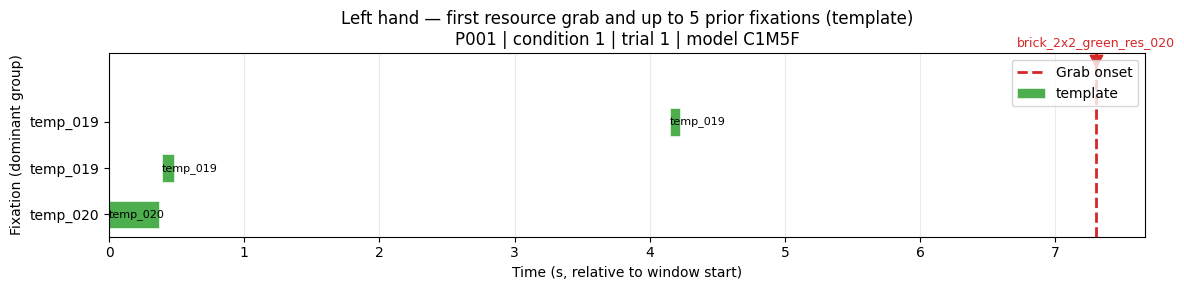

[plot_first_grab_fixation_timeline] Left hand: grab=brick_2x2_green_res_020 (transport) at onset_time=1778060678625; prior fixations plotted=3 (categories: template)


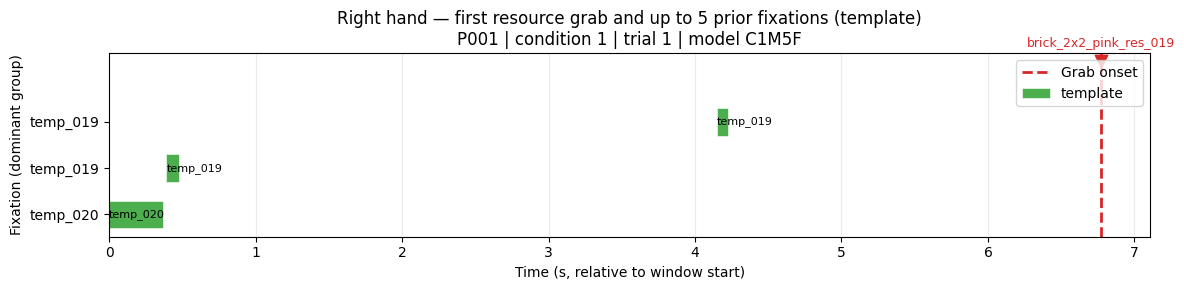

[plot_first_grab_fixation_timeline] Right hand: grab=brick_2x2_pink_res_019 (transport) at onset_time=1778060678092; prior fixations plotted=3 (categories: template)


In [100]:
def _first_resource_grab(grasp_events: pd.DataFrame, hand: str) -> pd.Series | None:
    """Return the earliest transport/correction resource grab for one hand."""
    grabs = _prepare_resource_grabs(grasp_events)
    hand_grabs = grabs[grabs['hand'] == hand].sort_values('onset_time')
    if hand_grabs.empty:
        return None
    return hand_grabs.iloc[0]


def _fixations_before_grab(
    brick_fixation_events_df: pd.DataFrame,
    grab_row: pd.Series,
    *,
    fixation_categories: set[str],
    max_fixations: int = 10,
) -> pd.DataFrame:
    """Select up to N fixations (filtered by category) ending before the grab onset."""
    trial_mask = (
        (brick_fixation_events_df['participant_id'] == grab_row['participant_id'])
        & (brick_fixation_events_df['condition_number'] == grab_row['condition_number'])
        & (brick_fixation_events_df['trial_number'] == grab_row['trial_number'])
        & (brick_fixation_events_df['model_name'] == grab_row['model_name'])
    )

    prior_fixations = brick_fixation_events_df[
        trial_mask
        & brick_fixation_events_df['brick_fixation'].isin(fixation_categories)
        & (brick_fixation_events_df['start_time'] < grab_row['onset_time'])
    ].sort_values('start_time')

    return prior_fixations.tail(max_fixations).copy()


def plot_first_grab_fixation_timeline(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
    hand: str,
    *,
    fixation_categories: set[str],
    max_fixations: int = 10,
) -> None:
    """Plot one timeline: first grab onset for a hand + preceding fixations."""
    if not fixation_categories:
        print('[plot_first_grab_fixation_timeline] No fixation categories selected — nothing to plot.')
        return

    grab_row = _first_resource_grab(grasp_events, hand)
    if grab_row is None:
        print(f'[plot_first_grab_fixation_timeline] No {hand}-hand resource grabs found.')
        return

    fixations = _fixations_before_grab(
        brick_fixation_events_df,
        grab_row,
        fixation_categories=fixation_categories,
        max_fixations=max_fixations,
    )

    category_label = ', '.join(sorted(fixation_categories))

    # Convert absolute timestamps to seconds relative to the timeline window start.
    window_start = grab_row['onset_time']
    if not fixations.empty:
        window_start = min(window_start, fixations['start_time'].min())

    def to_rel_seconds(timestamp) -> float:
        return (timestamp - window_start) / 1000.0

    grab_t = to_rel_seconds(grab_row['onset_time'])
    category_colors = {
        'template': '#2ca02c',
        'res_on_resource_table': '#1f77b4',
    }

    n_rows = max(len(fixations), 1)
    fig, ax = plt.subplots(figsize=(12, max(3.0, 0.45 * n_rows + 1.5)))

    for idx, (_, fixation_row) in enumerate(fixations.iterrows()):
        y = idx
        start_t = to_rel_seconds(fixation_row['start_time'])
        end_t = to_rel_seconds(fixation_row['end_time'])
        category = str(fixation_row['brick_fixation'])
        color = category_colors.get(category, '#7f7f7f')
        label = category if category not in ax.get_legend_handles_labels()[1] else None

        ax.barh(
            y,
            max(end_t - start_t, 0.01),
            left=start_t,
            height=0.6,
            color=color,
            alpha=0.85,
            edgecolor='white',
            linewidth=0.5,
            label=label,
        )
        ax.text(
            start_t,
            y,
            str(fixation_row.get('dominant_group', '')),
            va='center',
            ha='left',
            fontsize=8,
            color='black',
        )

    ax.axvline(
        grab_t,
        color='#d62728',
        linewidth=2,
        linestyle='--',
        label='Grab onset',
    )
    ax.scatter(
        [grab_t],
        [n_rows + 0.3],
        color='#d62728',
        s=80,
        marker='v',
        zorder=5,
    )
    ax.text(
        grab_t,
        n_rows + 0.55,
        str(grab_row.get('brick_type', 'grab')),
        ha='center',
        va='bottom',
        fontsize=9,
        color='#d62728',
    )

    ax.set_yticks(range(len(fixations)))
    ax.set_yticklabels([str(row.get('dominant_group', '')) for _, row in fixations.iterrows()])
    ax.set_xlabel('Time (s, relative to window start)')
    ax.set_ylabel('Fixation (dominant group)')
    ax.set_title(
        f'{hand} hand — first resource grab and up to {max_fixations} prior fixations ({category_label})\n'
        f"P{grab_row['participant_id']} | condition {grab_row['condition_number']} | "
        f"trial {grab_row['trial_number']} | model {grab_row['model_name']}"
    )
    ax.grid(True, axis='x', alpha=0.25)
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()

    print(
        f"[plot_first_grab_fixation_timeline] {hand} hand: grab={grab_row['brick_type']} "
        f"({grab_row['grasp_type']}) at onset_time={grab_row['onset_time']}; "
        f"prior fixations plotted={len(fixations)} (categories: {category_label})"
    )


# --- Plot configuration (adjust before running) ---
PLOT_TEMPLATE_FIXATIONS = True
PLOT_RESOURCE_FIXATIONS = False
MAX_FIXATIONS_TO_PLOT = 5

PLOT_FIXATION_CATEGORIES = {
    category
    for category, enabled in (
        ('template', PLOT_TEMPLATE_FIXATIONS),
        ('res_on_resource_table', PLOT_RESOURCE_FIXATIONS),
    )
    if enabled
}

# One timeline plot per hand
plot_first_grab_fixation_timeline(
    brick_fixation_events_df,
    grasp_events,
    'Left',
    fixation_categories=PLOT_FIXATION_CATEGORIES,
    max_fixations=MAX_FIXATIONS_TO_PLOT,
)
plot_first_grab_fixation_timeline(
    brick_fixation_events_df,
    grasp_events,
    'Right',
    fixation_categories=PLOT_FIXATION_CATEGORIES,
    max_fixations=MAX_FIXATIONS_TO_PLOT,
)


### Match_Typ_Left / Match_Typ_Right — fixation–grab sequence labels
 Labels describe the relationship between template fixations and resource grabs
 within each trial (across both hands):
   FG   = template fixation before this grab (or between previous grab and this one)
   FGG  = no new template fixation since FG; this is the 2nd grab in the chain
   FGGG = 3rd grab without intervening template fixation, etc.
   unclassified = grab with no prior template fixation in the trial timeline

In [101]:


MATCH_TYP_TEMPLATE = 'template'
MATCH_TYP_UNCLASSIFIED = 'unclassified'
HAND_ORDER = {'Left': 0, 'Right': 1}


def _match_typ_label(grab_count: int) -> str:
    """Build FG / FGG / FGGG ... from the number of grabs since last template look."""
    if grab_count <= 0:
        return MATCH_TYP_UNCLASSIFIED
    return 'F' + ('G' * grab_count)


def _has_template_fixation_before_grab(
    template_fixations: pd.DataFrame,
    prev_grab_onset,
    grab_onset,
) -> bool:
    """Return True when a template fixation precedes the grab in the relevant window."""
    for _, fixation in template_fixations.iterrows():
        if fixation['start_time'] >= grab_onset:
            continue
        if prev_grab_onset is None:
            return True
        if fixation['end_time'] > prev_grab_onset and fixation['start_time'] < grab_onset:
            return True
    return False


def compute_grab_match_typ_labels(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> dict[tuple, str]:
    """Assign FG/FGG/... labels to every resource grab, ordered across both hands."""
    grabs = _prepare_resource_grabs(grasp_events)
    labels: dict[tuple, str] = {}

    template_by_trial = {
        key: trial_df[trial_df['brick_fixation'] == MATCH_TYP_TEMPLATE].sort_values('start_time')
        for key, trial_df in brick_fixation_events_df.groupby(TRIAL_GROUP_COLS, dropna=False)
    }

    for trial_key, trial_grabs in grabs.groupby(TRIAL_GROUP_COLS, dropna=False):
        template_fixations = template_by_trial.get(trial_key, pd.DataFrame())
        trial_grabs = trial_grabs.copy()
        trial_grabs['_hand_order'] = trial_grabs['hand'].map(HAND_ORDER)
        trial_grabs = trial_grabs.sort_values(['onset_time', '_hand_order'])

        prev_grab_onset = None
        grabs_since_template = 0

        for _, grab in trial_grabs.iterrows():
            grab_onset = grab['onset_time']
            if _has_template_fixation_before_grab(template_fixations, prev_grab_onset, grab_onset):
                grabs_since_template = 1
                label = 'FG'
            elif prev_grab_onset is None:
                label = MATCH_TYP_UNCLASSIFIED
                grabs_since_template = 0
            elif grabs_since_template > 0:
                grabs_since_template += 1
                label = _match_typ_label(grabs_since_template)
            else:
                label = MATCH_TYP_UNCLASSIFIED

            labels[(trial_key, grab['hand'], grab_onset)] = label
            prev_grab_onset = grab_onset

    return labels


def assign_match_typ_columns(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """Fill Match_Typ_Left and Match_Typ_Right on brick_fixation_events_df."""
    df = brick_fixation_events_df.copy()
    grab_labels = compute_grab_match_typ_labels(df, grasp_events)
    grabs = _prepare_resource_grabs(grasp_events)
    grabs_by_trial = {
        key: group for key, group in grabs.groupby(TRIAL_GROUP_COLS, dropna=False)
    }

    df['Match_Typ_Left'] = pd.NA
    df['Match_Typ_Right'] = pd.NA

    for row_idx, row in df.iterrows():
        trial_key = tuple(row[col] for col in TRIAL_GROUP_COLS)
        trial_grabs = grabs_by_trial.get(trial_key, pd.DataFrame())

        for hand, match_col in (('Left', 'Match_Typ_Left'), ('Right', 'Match_Typ_Right')):
            grab_col = f'{hand}_Grab'
            if pd.isna(row[grab_col]):
                continue

            grab_row = _select_overlapping_grab(
                trial_grabs,
                row['start_time'],
                row['end_time'],
                hand,
            )
            if grab_row is None:
                hand_grabs = trial_grabs[
                    (trial_grabs['hand'] == hand)
                    & (trial_grabs['brick_type'] == row[grab_col])
                ].sort_values('onset_time')
                grab_row = hand_grabs.iloc[0] if not hand_grabs.empty else None

            if grab_row is not None:
                label_key = (trial_key, hand, grab_row['onset_time'])
                df.at[row_idx, match_col] = grab_labels.get(label_key, pd.NA)

    return df


brick_fixation_events_df = assign_match_typ_columns(brick_fixation_events_df, grasp_events)

print('[assign_match_typ_columns] Match_Typ_Left counts:')
print(brick_fixation_events_df['Match_Typ_Left'].value_counts(dropna=True))
print('\n[assign_match_typ_columns] Match_Typ_Right counts:')
print(brick_fixation_events_df['Match_Typ_Right'].value_counts(dropna=True))

grab_rows = brick_fixation_events_df[
    brick_fixation_events_df['Left_Grab'].notna() | brick_fixation_events_df['Right_Grab'].notna()
]
print('\n[assign_match_typ_columns] Sample rows with match labels:')
display_cols = [
    'participant_id', 'condition_number', 'trial_number', 'model_name',
    'start_time', 'brick_fixation', 'Left_Grab', 'Right_Grab',
    'Match_Typ_Left', 'Match_Typ_Right', 'Single_Dual_Grab',
]
print(grab_rows[display_cols].drop_duplicates(
    subset=[
        'participant_id', 'condition_number', 'trial_number', 'model_name',
        'Left_Grab', 'Right_Grab', 'Match_Typ_Left', 'Match_Typ_Right',
    ]
).head(15).to_string(index=False))


[assign_match_typ_columns] Match_Typ_Left counts:
Match_Typ_Left
FG              4836
FGG             3572
FGGG             899
FGGGG            532
FGGGGG            87
unclassified      59
FGGGGGG           35
FGGGGGGG           9
FGGGGGGGG          6
Name: count, dtype: int64

[assign_match_typ_columns] Match_Typ_Right counts:
Match_Typ_Right
FG              6121
FGG             2784
FGGG            1306
FGGGG            431
FGGGGG           119
unclassified      67
FGGGGGG           26
FGGGGGGG          24
FGGGGGGGGGG        3
FGGGGGGGG          2
FGGGGGGGGG         2
Name: count, dtype: int64

[assign_match_typ_columns] Sample rows with match labels:
participant_id  condition_number  trial_number model_name    start_time        brick_fixation                Left_Grab              Right_Grab Match_Typ_Left Match_Typ_Right Single_Dual_Grab
           001                 1             1      C1M5F 1778060677669 res_on_resource_table                     <NA>  brick_2x2_pink_res_019   

In [102]:
print(brick_fixation_events_df)

      run_id  condition_number  trial_number model_name     start_time  \
0         37                 1             1      C1M5F  1778060671323   
1         39                 1             1      C1M5F  1778060671714   
2         67                 1             1      C1M5F  1778060674136   
3         71                 1             1      C1M5F  1778060674391   
4         85                 1             1      C1M5F  1778060675470   
...      ...               ...           ...        ...            ...   
57159   9616                 3             6      C2M3F  1781263069302   
57160   <NA>                 3             6      C2M3F  1781263069813   
57161   9688                 3             6      C2M3F  1781263076090   
57162   9698                 3             6      C2M3F  1781263077835   
57163   <NA>                 3             6      C2M3F  1781263078146   

            end_time duration_ms n_samples dominant_group  \
0      1778060671691         368        75       t

### Adding Event variable and fixation and grabbing order

In [103]:
TRIAL_GROUP_COLS = ['participant_id', 'condition_number', 'trial_number', 'model_name']

def add_event_and_counts(brick_fixation_events_df: pd.DataFrame) -> pd.DataFrame:
    df = brick_fixation_events_df.copy()

    # Ensure chronological order within each trial
    df = df.sort_values(TRIAL_GROUP_COLS + ['start_time']).reset_index(drop=True)

    # --- Row type flags (based on your definitions) ---
    # .fillna(False): brick_fixation contains pd.NA for grab-only rows, and
    # pd.NA propagates through .eq() instead of becoming False — fillna
    # collapses those back to real booleans.
    is_template_fix = df['brick_fixation'].eq('template').fillna(False)
    is_resource_fix = df['brick_fixation'].eq('res_on_resource_table').fillna(False)

    is_grab_row = df['Left_Grab'].notna() | df['Right_Grab'].notna()

    # --- Build event id per trial ---
    def _per_trial_assign(trial_df: pd.DataFrame) -> pd.DataFrame:
        t_is_template = trial_df['brick_fixation'].eq('template').fillna(False)
        t_is_grab = trial_df['Left_Grab'].notna() | trial_df['Right_Grab'].notna()

        event_ids = np.full(len(trial_df), np.nan, dtype=float)

        current_event = 0
        started = False
        seen_grab_since_start = False

        for i in range(len(trial_df)):
            if t_is_template.iat[i]:
                if (not started) or seen_grab_since_start:
                    current_event += 1
                    started = True
                    seen_grab_since_start = False
                event_ids[i] = current_event
            else:
                if started:
                    event_ids[i] = current_event

            if started and t_is_grab.iat[i]:
                seen_grab_since_start = True

        trial_df = trial_df.copy()
        trial_df['event'] = pd.Series(event_ids, index=trial_df.index).astype('Int64')
        return trial_df

    event_series = (
        df.groupby(TRIAL_GROUP_COLS, dropna=False, group_keys=False)
          .apply(_per_trial_assign, include_groups=False)['event']
    )
    df['event'] = event_series

    # --- Counts within each event (per trial) ---
    df['template_fixation_count'] = (
        df.groupby(TRIAL_GROUP_COLS + ['event'], dropna=False)['brick_fixation']
          .transform(lambda s: s.eq('template').fillna(False).cumsum())
          .astype('Int64')
    )
    df.loc[~is_template_fix, 'template_fixation_count'] = pd.NA

    df['resource_fixation_count'] = (
        df.groupby(TRIAL_GROUP_COLS + ['event'], dropna=False)['brick_fixation']
          .transform(lambda s: s.eq('res_on_resource_table').fillna(False).cumsum())
          .astype('Int64')
    )
    df.loc[~is_resource_fix, 'resource_fixation_count'] = pd.NA

    df['grab_count'] = (
        df.assign(_is_grab=df['Left_Grab'].notna() | df['Right_Grab'].notna())
          .groupby(TRIAL_GROUP_COLS + ['event'], dropna=False)['_is_grab']
          .transform(lambda s: s.cumsum())
          .astype('Int64')
    )
    df.loc[~is_grab_row, 'grab_count'] = pd.NA

    return df

brick_fixation_events_df = add_event_and_counts(brick_fixation_events_df)

In [104]:
print(brick_fixation_events_df)

      run_id  condition_number  trial_number model_name     start_time  \
0         37                 1             1      C1M5F  1778060671323   
1         39                 1             1      C1M5F  1778060671714   
2         67                 1             1      C1M5F  1778060674136   
3         71                 1             1      C1M5F  1778060674391   
4         85                 1             1      C1M5F  1778060675470   
...      ...               ...           ...        ...            ...   
57159   9616                 3             6      C2M3F  1781263069302   
57160   <NA>                 3             6      C2M3F  1781263069813   
57161   9688                 3             6      C2M3F  1781263076090   
57162   9698                 3             6      C2M3F  1781263077835   
57163   <NA>                 3             6      C2M3F  1781263078146   

            end_time duration_ms n_samples dominant_group  \
0      1778060671691         368        75       t

Some rows have an overlap between e.g. FG and FGG 

## Event timeline visualization (fixations + FG/FGG/FGGG grabs)

Found 1364 event(s) with an FGGG grab.


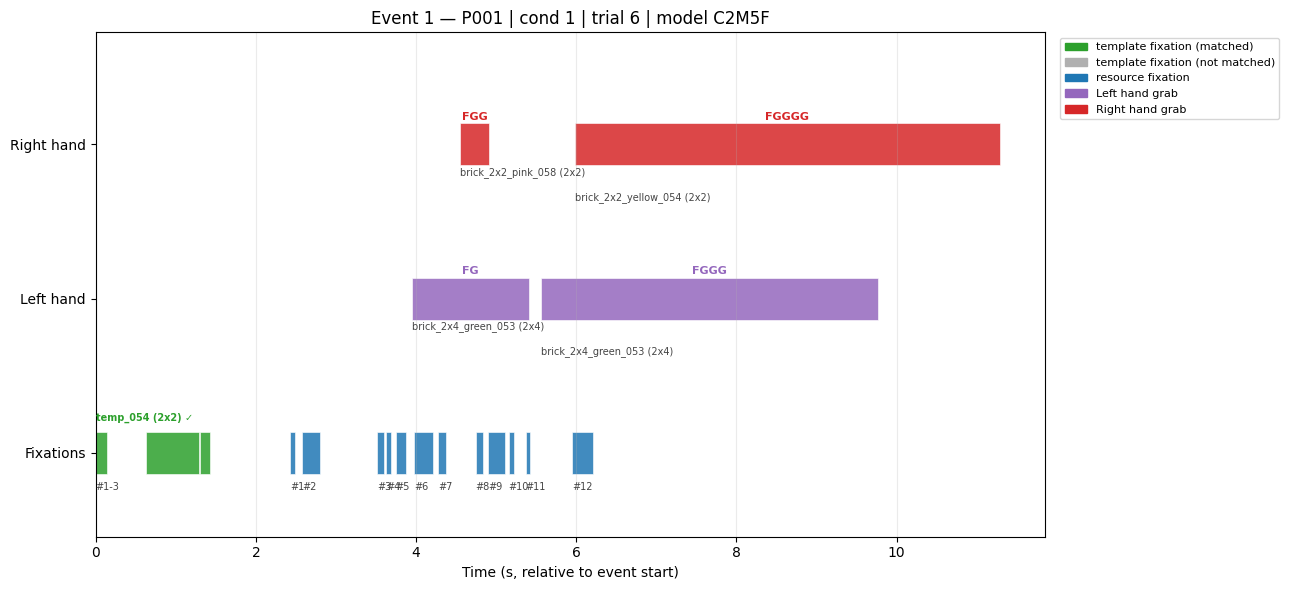

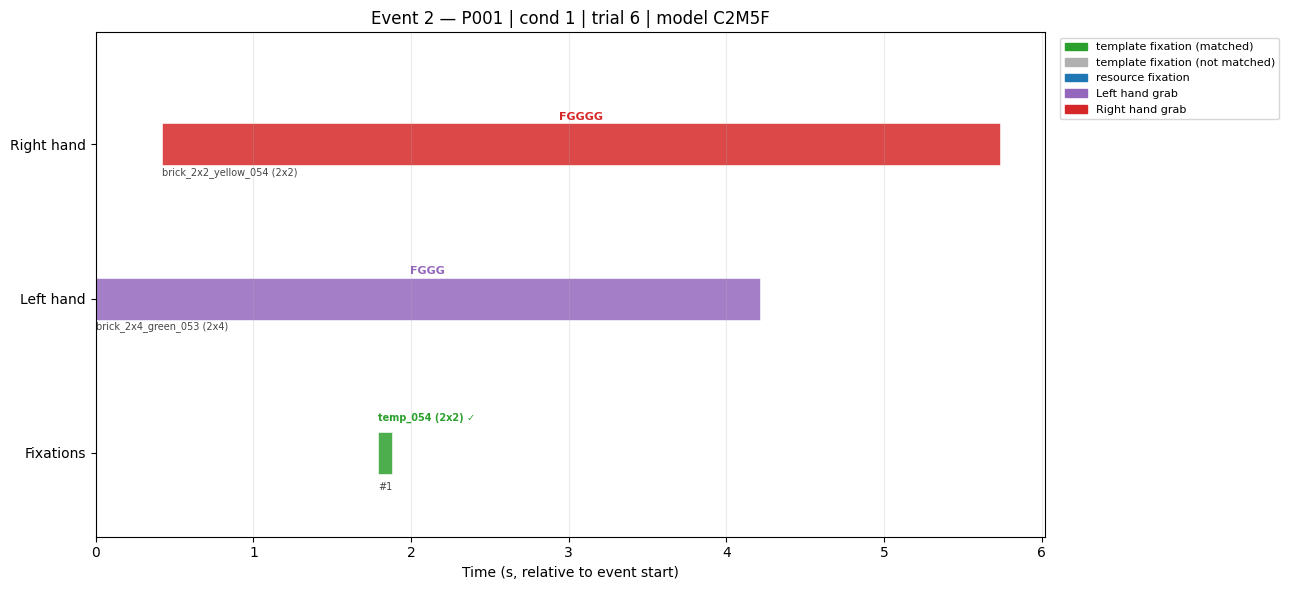

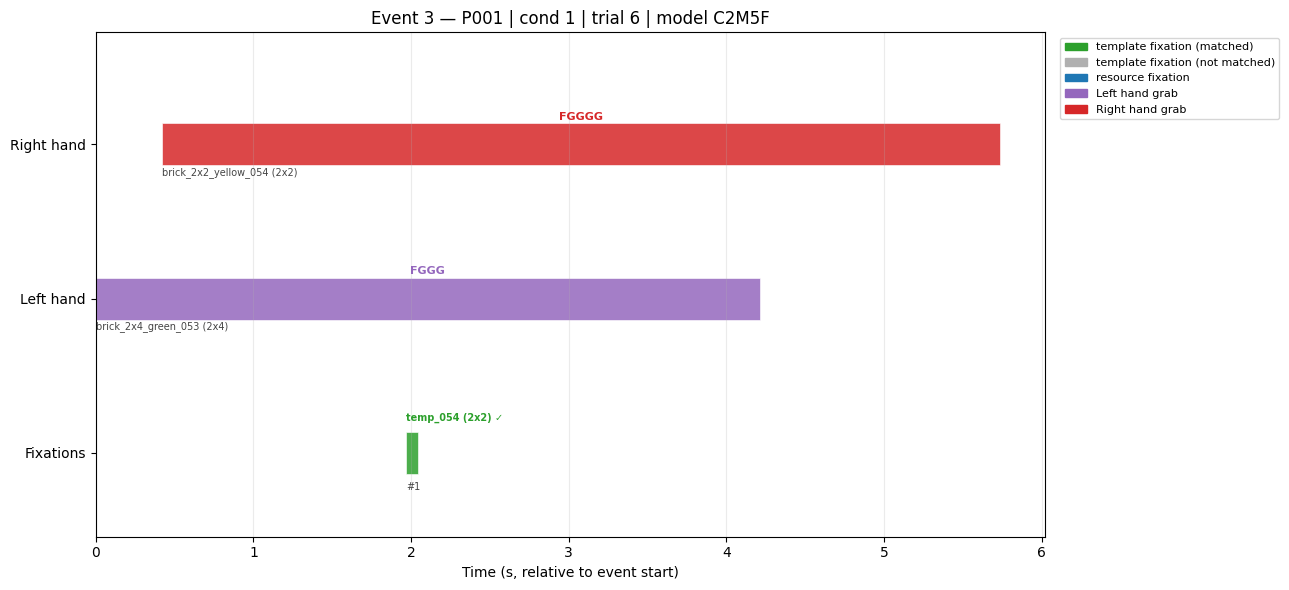

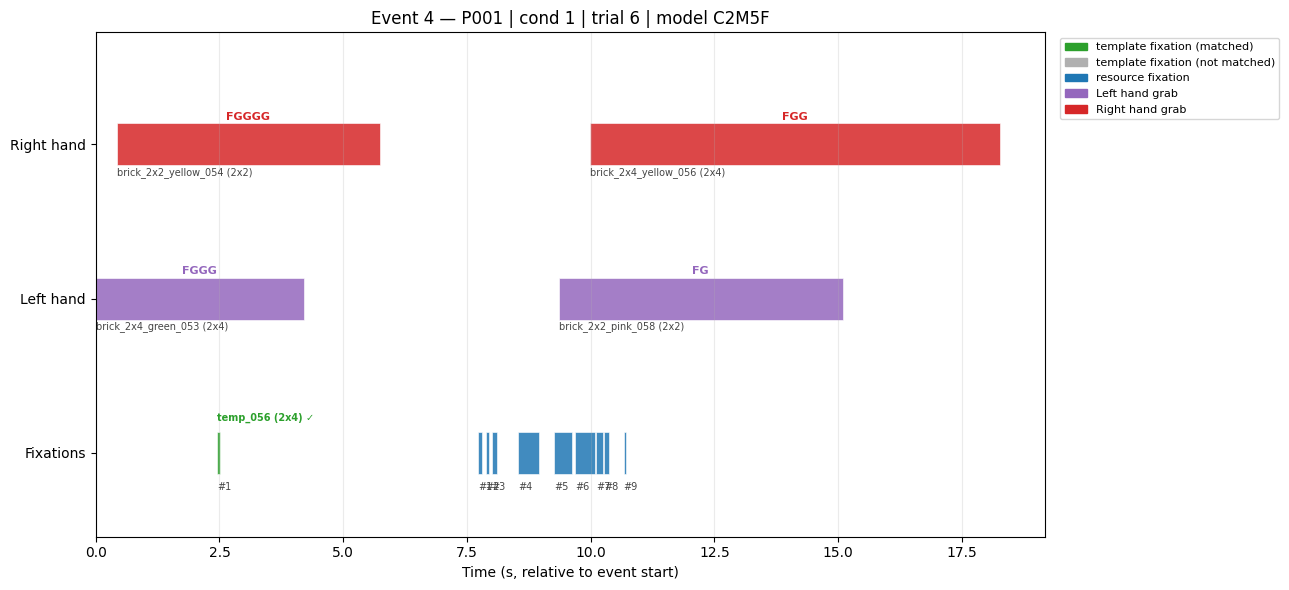

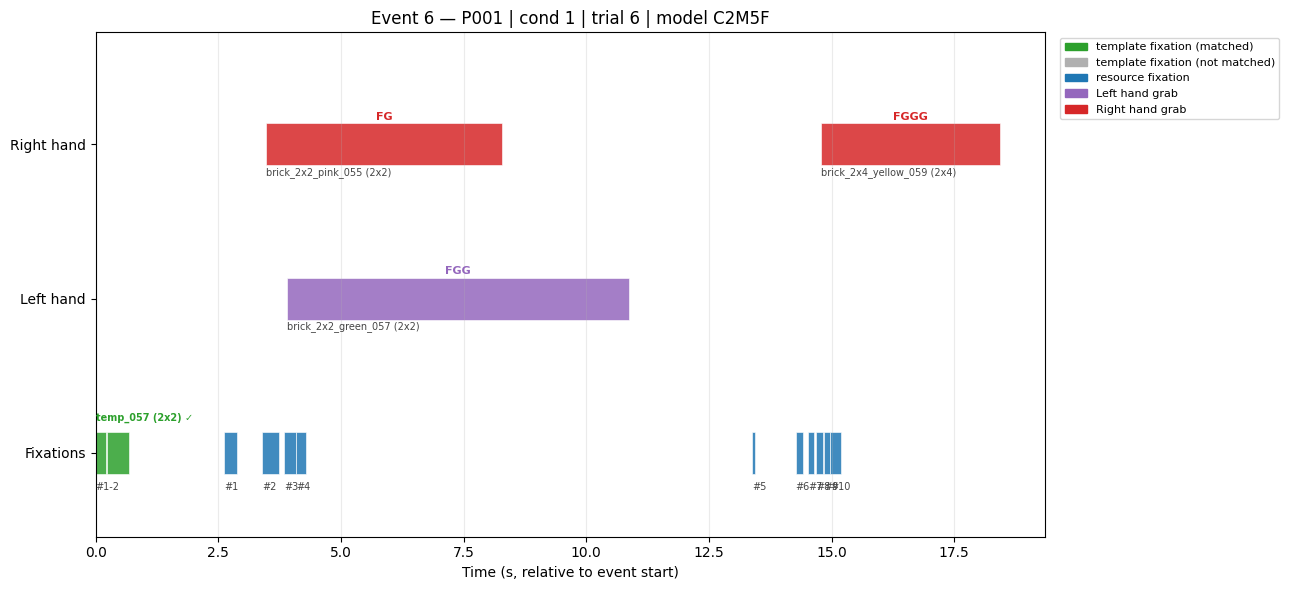

In [105]:
# =============================================================================
# Event timeline visualization — both hands together, with FG/FGG/FGGG labels
# =============================================================================

FIXATION_CATEGORY_COLORS = {
    'template': '#2ca02c',                 # green
    'res_on_resource_table': '#1f77b4',    # blue
}
HAND_COLORS = {
    'Left': '#9467bd',   # purple
    'Right': '#d62728',  # red
}

# Row positions — widened gap between Left/Right rows so even a worst-case
# two-tier label stack can't bleed into the neighboring row.
ROW_FIX, ROW_LEFT, ROW_RIGHT = 0, 2.2, 4.4


def find_events_with_label(
    brick_fixation_events_df: pd.DataFrame,
    label: str,
) -> list[tuple]:
    """Return (trial_key_tuple, event_id) pairs where either hand shows `label`."""
    hits = brick_fixation_events_df[
        (brick_fixation_events_df['Match_Typ_Left'] == label)
        | (brick_fixation_events_df['Match_Typ_Right'] == label)
    ]
    keys = (
        hits[TRIAL_GROUP_COLS + ['event']]
        .dropna(subset=['event'])
        .drop_duplicates()
    )
    return [
        (tuple(row[col] for col in TRIAL_GROUP_COLS), row['event'])
        for _, row in keys.iterrows()
    ]


def _event_grabs(
    event_rows: pd.DataFrame,
    trial_grabs: pd.DataFrame,
    grab_labels: dict,
    trial_key: tuple,
) -> list[dict]:
    """Re-fetch true onset/offset + Match_Typ label for every grab touching this event."""
    seen: dict[tuple, dict] = {}

    for _, row in event_rows.iterrows():
        for hand, grab_col in (('Left', 'Left_Grab'), ('Right', 'Right_Grab')):
            if pd.isna(row[grab_col]):
                continue

            grab_row = _select_overlapping_grab(
                trial_grabs, row['start_time'], row['end_time'], hand
            )
            if grab_row is None:
                continue

            key = (hand, grab_row['onset_time'])
            if key in seen:
                continue

            label_key = (trial_key, hand, grab_row['onset_time'])
            seen[key] = {
                'hand': hand,
                'onset_time': grab_row['onset_time'],
                'offset_time': grab_row['offset_time'],
                'brick_type': grab_row['brick_type'],
                'canonical_id': _canonical_brick_id(grab_row['brick_type']),
                'size': _brick_size(grab_row['brick_type']),
                'match_typ': grab_labels.get(label_key, pd.NA),
            }

    return sorted(seen.values(), key=lambda g: g['onset_time'])


def plot_event_timeline(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
    trial_key: tuple,
    event_id,
    grab_labels: dict | None = None,
) -> None:
    """Plot one event: template/resource fixations + both hands' grabs, with FG/FGG/... labels."""
    trial_mask = pd.Series(True, index=brick_fixation_events_df.index)
    for col, val in zip(TRIAL_GROUP_COLS, trial_key):
        trial_mask &= brick_fixation_events_df[col] == val

    event_rows = brick_fixation_events_df[
        trial_mask & (brick_fixation_events_df['event'] == event_id)
    ].sort_values('start_time')

    if event_rows.empty:
        print(f'[plot_event_timeline] No rows found for trial={trial_key}, event={event_id}')
        return

    if grab_labels is None:
        grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)

    all_grabs = _prepare_resource_grabs(grasp_events)
    trial_grabs_mask = pd.Series(True, index=all_grabs.index)
    for col, val in zip(TRIAL_GROUP_COLS, trial_key):
        trial_grabs_mask &= all_grabs[col] == val
    trial_grabs = all_grabs[trial_grabs_mask]

    grabs = _event_grabs(event_rows, trial_grabs, grab_labels, trial_key)
    grabbed_ids = {g['canonical_id'] for g in grabs if g['canonical_id']}

    window_start = event_rows['start_time'].min()
    if grabs:
        window_start = min(window_start, min(g['onset_time'] for g in grabs))

    def to_rel(ts) -> float:
        return (ts - window_start) / 1000.0

    fixation_rows = event_rows[event_rows['brick_fixation'].notna()].copy()

    fig, ax = plt.subplots(figsize=(13, 6))

# --- Fixation bars ---
    # Group consecutive fixation rows that share the same category + brick id into
    # one "run" (repeated glances at the same brick), so they get ONE label instead
    # of one per row.
    fixation_rows['_canonical_id'] = fixation_rows.apply(
        lambda r: _canonical_brick_id(r.get('dominant_hit_obj_name'))
        if r['brick_fixation'] == 'template' else None,
        axis=1,
    )
    run_changed = (
        (fixation_rows['brick_fixation'] != fixation_rows['brick_fixation'].shift())
        | (fixation_rows['_canonical_id'] != fixation_rows['_canonical_id'].shift())
    )
    fixation_rows['_run_id'] = run_changed.cumsum()
    for run_id, run_df in fixation_rows.groupby('_run_id'):
        category = run_df['brick_fixation'].iloc[0]

        if category == 'template':
            canonical_id = run_df['_canonical_id'].iloc[0]
            is_match = canonical_id is not None and canonical_id in grabbed_ids
            # Matched template fixations stay green; unmatched ones go grey,
            # so match status is visible on the bar itself, not just the label.
            color = FIXATION_CATEGORY_COLORS['template'] if is_match else '#b0b0b0'
        else:
            color = FIXATION_CATEGORY_COLORS.get(category, '#7f7f7f')
            is_match = None  # not applicable to resource fixations

        for _, frow in run_df.iterrows():
            start_t, end_t = to_rel(frow['start_time']), to_rel(frow['end_time'])
            ax.barh(ROW_FIX, max(end_t - start_t, 0.02), left=start_t, height=0.6,
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

        run_start_t = to_rel(run_df['start_time'].iloc[0])
        count_col = 'template_fixation_count' if category == 'template' else 'resource_fixation_count'
        counts = run_df[count_col].dropna().astype(int)
        if len(counts):
            count_label = f'#{counts.min()}' if counts.min() == counts.max() else f'#{counts.min()}-{counts.max()}'
            ax.annotate(count_label, (run_start_t, ROW_FIX - 0.42),
                        ha='left', va='top', fontsize=7, color='#444')

        if category == 'template':
            size = _brick_size(run_df['dominant_hit_obj_name'].iloc[0])
            marker = '✓' if is_match else '·'
            marker_color = FIXATION_CATEGORY_COLORS['template'] if is_match else '#b0b0b0'
            id_label = run_df['dominant_group'].iloc[0]
            size_label = f' ({size})' if size else ''
            ax.annotate(
                f"{id_label}{size_label} {marker}",
                (run_start_t, ROW_FIX + 0.42), ha='left', va='bottom',
                fontsize=7, color=marker_color, fontweight='bold' if is_match else 'normal',
            )

# --- Grab bars ---
    # Place labels close to their bar first, then use matplotlib's actual
    # rendered text bounding boxes to detect real overlaps and only push a
    # label further away when it genuinely collides with its neighbor.
    NEAR_TIER, FAR_TIER, STEP = 0.32, 0.68, 0.36

    row_for_hand = {'Left': ROW_LEFT, 'Right': ROW_RIGHT}
    grabs_by_hand: dict[str, list[dict]] = {'Left': [], 'Right': []}
    for grab in grabs:
        grabs_by_hand[grab['hand']].append(grab)

    top_annotations: dict[str, list] = {'Left': [], 'Right': []}
    bottom_annotations: dict[str, list] = {'Left': [], 'Right': []}

    for hand, hand_grabs in grabs_by_hand.items():
        y = row_for_hand[hand]
        hand_grabs = sorted(hand_grabs, key=lambda g: g['onset_time'])

        for grab in hand_grabs:
            start_t, end_t = to_rel(grab['onset_time']), to_rel(grab['offset_time'])
            color = HAND_COLORS[hand]
            ax.barh(y, max(end_t - start_t, 0.02), left=start_t, height=0.6,
                    color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

            label = str(grab['match_typ']) if pd.notna(grab['match_typ']) else '?'
            top_ann = ax.annotate(label, ((start_t + end_t) / 2, y + NEAR_TIER),
                                   ha='center', va='bottom', fontsize=8,
                                   fontweight='bold', color=color)
            top_annotations[hand].append(top_ann)

            short_label = grab['canonical_id'] or grab['brick_type']
            size_label = f" ({grab['size']})" if grab['size'] else ''
            bottom_ann = ax.annotate(f"{short_label}{size_label}", (start_t, y - NEAR_TIER),
                                      ha='left', va='top', fontsize=7, color='#444')
            bottom_annotations[hand].append(bottom_ann)

    # --- Declutter: force a real render, then nudge overlapping labels apart ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    def _declutter(annotations: list, y_base: float, push_up: bool, pad: float = 1.05) -> None:
            """Push each annotation further from its row until it no longer
            overlaps the previous one's actual rendered bounding box."""
            for i in range(1, len(annotations)):
                prev_ann, cur_ann = annotations[i - 1], annotations[i]
                level = 0
                while True:
                    prev_bbox = prev_ann.get_window_extent(renderer=renderer).expanded(pad, pad)
                    cur_bbox = cur_ann.get_window_extent(renderer=renderer).expanded(pad, pad)
                    if not prev_bbox.overlaps(cur_bbox):
                        break
                    level += 1
                    new_y = y_base + level * STEP if push_up else y_base - level * STEP
                    x, _ = cur_ann.get_position()
                    cur_ann.set_position((x, new_y))
                    if level > 4:
                        break


    for hand in ('Left', 'Right'):
        y = row_for_hand[hand]
        _declutter(top_annotations[hand], y + NEAR_TIER, push_up=True)
        _declutter(bottom_annotations[hand], y - NEAR_TIER, push_up=False)

    ax.set_yticks([ROW_FIX, ROW_LEFT, ROW_RIGHT])
    ax.set_yticklabels(['Fixations', 'Left hand', 'Right hand'])
    ax.set_ylim(ROW_FIX - 1.2, ROW_RIGHT + 1.6)
    ax.set_xlabel('Time (s, relative to event start)')
    ax.set_title(
        f"Event {event_id} — P{trial_key[0]} | cond {trial_key[1]} | "
        f"trial {trial_key[2]} | model {trial_key[3]}"
    )
    ax.grid(True, axis='x', alpha=0.25)

    legend_handles = [
        mpatches.Patch(color=FIXATION_CATEGORY_COLORS['template'], label='template fixation (matched)'),
        mpatches.Patch(color='#b0b0b0', label='template fixation (not matched)'),
        mpatches.Patch(color=FIXATION_CATEGORY_COLORS['res_on_resource_table'], label='resource fixation'),
        mpatches.Patch(color=HAND_COLORS['Left'], label='Left hand grab'),
        mpatches.Patch(color=HAND_COLORS['Right'], label='Right hand grab'),
    ]
    ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    fig.tight_layout()
    plt.show()


# --- Example usage: plot every event containing an FGGG ---
fggg_events = find_events_with_label(brick_fixation_events_df, 'FGGG')
print(f'Found {len(fggg_events)} event(s) with an FGGG grab.')

grab_labels_cache = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)

for trial_key, event_id in fggg_events[:5]:
    plot_event_timeline(brick_fixation_events_df, grasp_events, trial_key, event_id, grab_labels_cache)

In [106]:
#Sanity check - does the filter work/do I have fixations on the template,
# that do not match with the grabbed bricks
event_mask = (
    (brick_fixation_events_df['participant_id'] == 'P001')
    & (brick_fixation_events_df['condition_number'] == 1)
    & (brick_fixation_events_df['trial_number'] == 6)
    & (brick_fixation_events_df['model_name'] == 'C2M5F')
    & (brick_fixation_events_df['event'] == 1)
)
rows = brick_fixation_events_df[event_mask]

template_rows = rows[rows['brick_fixation'] == 'template']
print('Total template fixation rows:', len(template_rows))
print(template_rows['dominant_hit_obj_name'].value_counts(dropna=False))

Total template fixation rows: 0
Series([], Name: count, dtype: int64)


In [107]:
def get_event_rows(
    brick_fixation_events_df: pd.DataFrame,
    participant_id=None,
    condition_number=None,
    trial_number=None,
    model_name=None,
    event=None,
    match_typ=None,   # e.g. 'FG', 'FGG', 'FGGG' — matches either hand
) -> pd.DataFrame:
    """Flexible filter — only supplied (non-None) arguments constrain the mask."""
    mask = pd.Series(True, index=brick_fixation_events_df.index)
    filters = {
        'participant_id': participant_id,
        'condition_number': condition_number,
        'trial_number': trial_number,
        'model_name': model_name,
        'event': event,
    }
    for col, val in filters.items():
        if val is not None:
            mask &= brick_fixation_events_df[col] == val

    if match_typ is not None:
        mask &= (
            (brick_fixation_events_df['Match_Typ_Left'] == match_typ)
            | (brick_fixation_events_df['Match_Typ_Right'] == match_typ)
        )

    return brick_fixation_events_df[mask]


def list_events(
    brick_fixation_events_df: pd.DataFrame,
    **filters,
) -> pd.DataFrame:
    """List every distinct (trial, event) combo matching optional filters.
    Same filter kwargs as get_event_rows (participant_id, event, match_typ, ...).
    """
    rows = get_event_rows(brick_fixation_events_df, **filters)
    return (
        rows.dropna(subset=['event'])[TRIAL_GROUP_COLS + ['event']]
        .drop_duplicates()
        .sort_values(TRIAL_GROUP_COLS + ['event'])
        .reset_index(drop=True)
    )

def plot_events(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
    events: pd.DataFrame,
    grab_labels: dict | None = None,
    max_plots: int | None = None,
) -> None:
    """Plot every (trial, event) row from a list_events()-style dataframe."""
    if grab_labels is None:
        grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)

    for i, row in events.iterrows():
        if max_plots is not None and i >= max_plots:
            break
        trial_key = tuple(row[col] for col in TRIAL_GROUP_COLS)
        plot_event_timeline(
            brick_fixation_events_df, grasp_events, trial_key, row['event'], grab_labels
        )

    run_id  condition_number  trial_number model_name     start_time  \
351   4453                 1             6      C2M5F  1778061244013   
352   4457                 1             6      C2M5F  1778061244169   

          end_time duration_ms n_samples dominant_group  \
351  1778061244102          89        20        res_056   
352  1778061244380         211        43        res_058   

                 plot_group  ...              Right_Grab Grap_Typ_Left  \
351  res_056_resource_table  ...  brick_2x2_pink_res_058    correction   
352  res_058_resource_table  ...  brick_2x2_pink_res_058    correction   

     Grap_Typ_Right Match_Typ_Left Match_Typ_Right  Single_Dual_Grab  event  \
351      correction             FG             FGG              dual      1   
352      correction             FG             FGG              dual      1   

     template_fixation_count  resource_fixation_count  grab_count  
351                     <NA>                        8           3  
352     

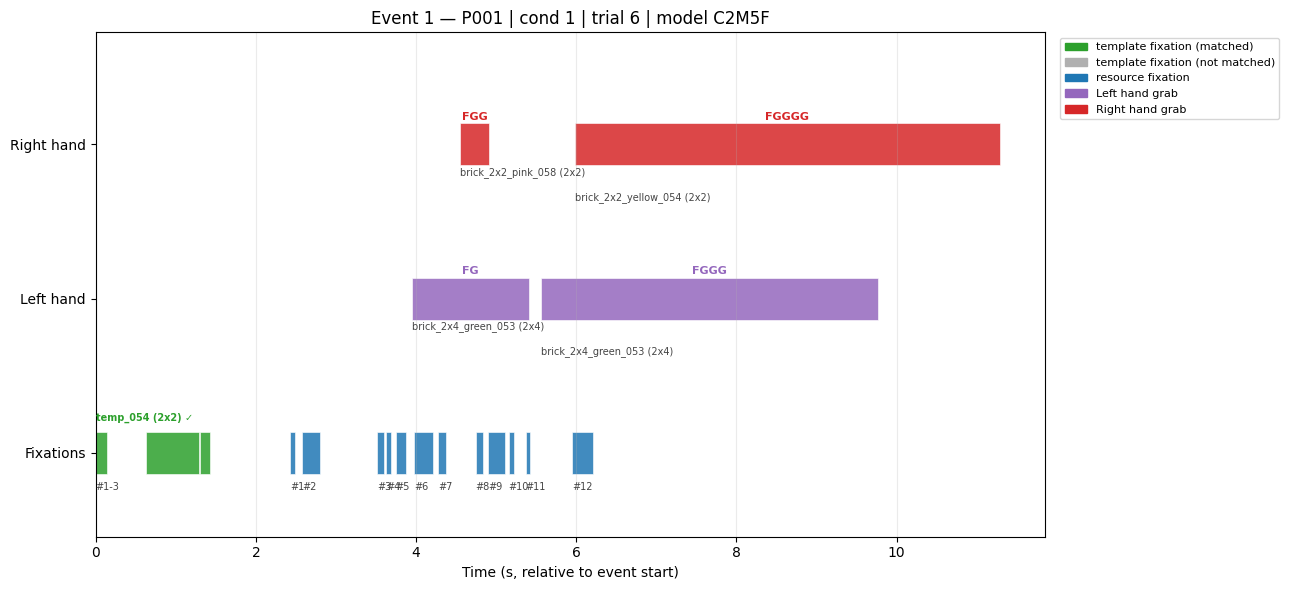

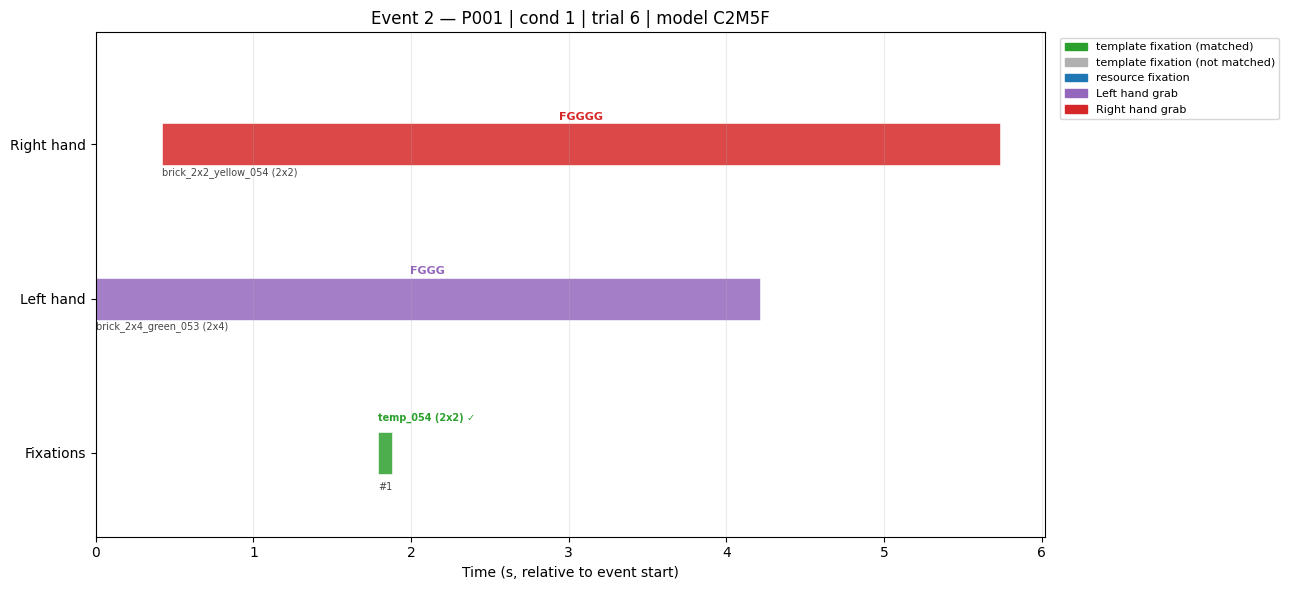

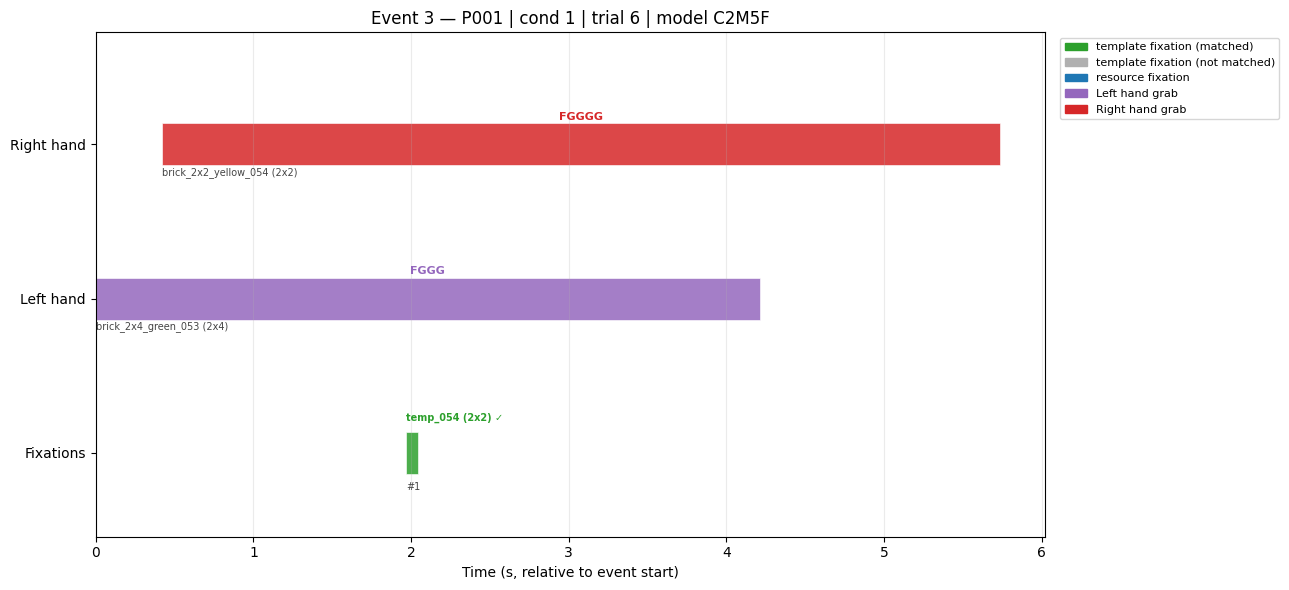

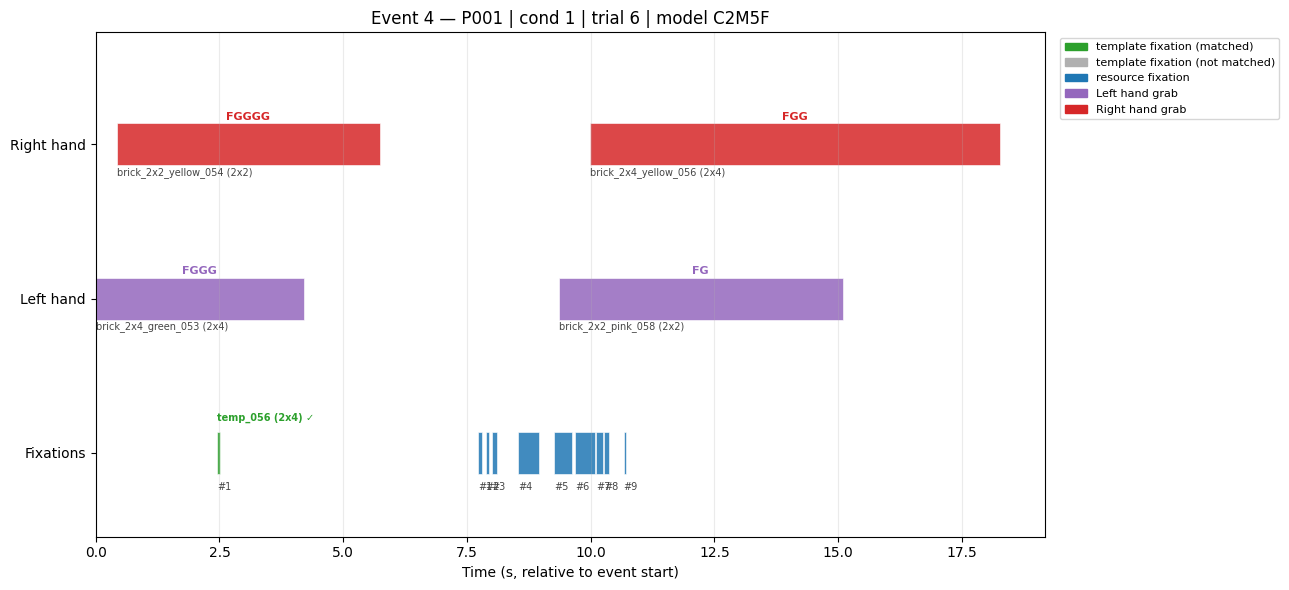

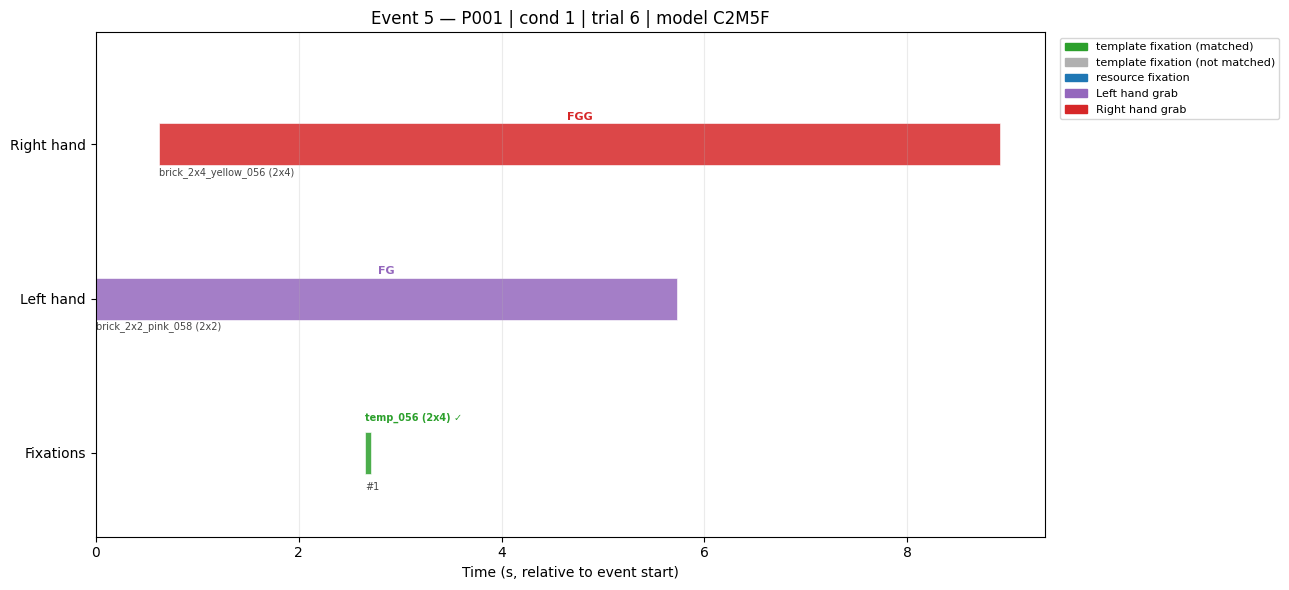

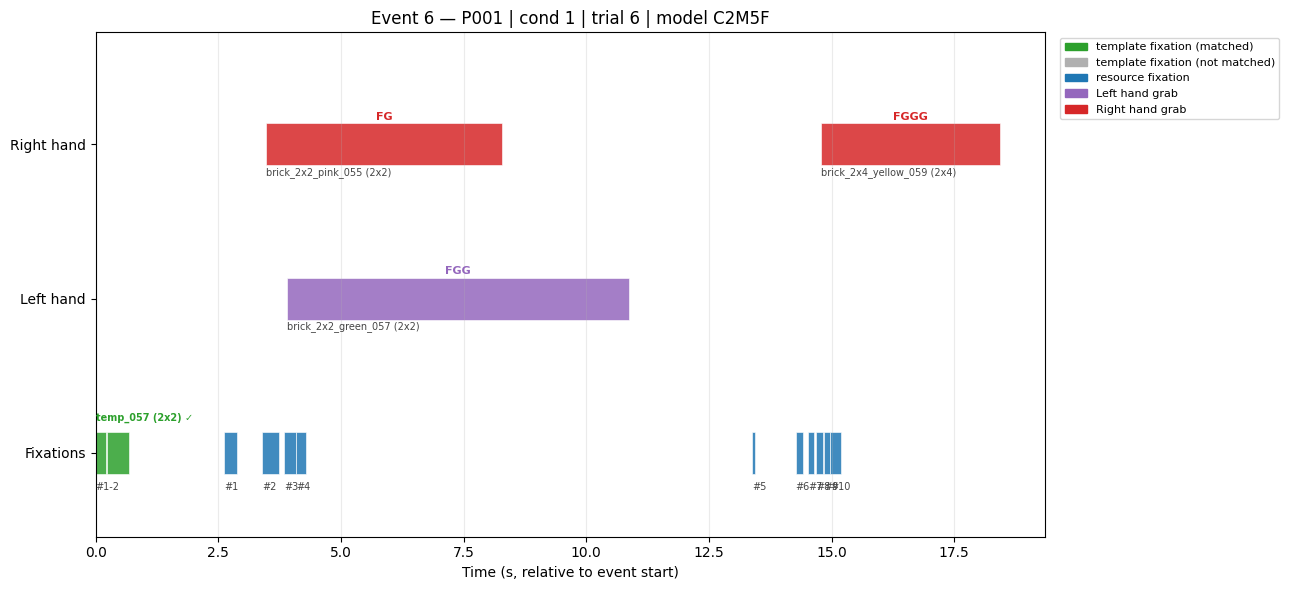

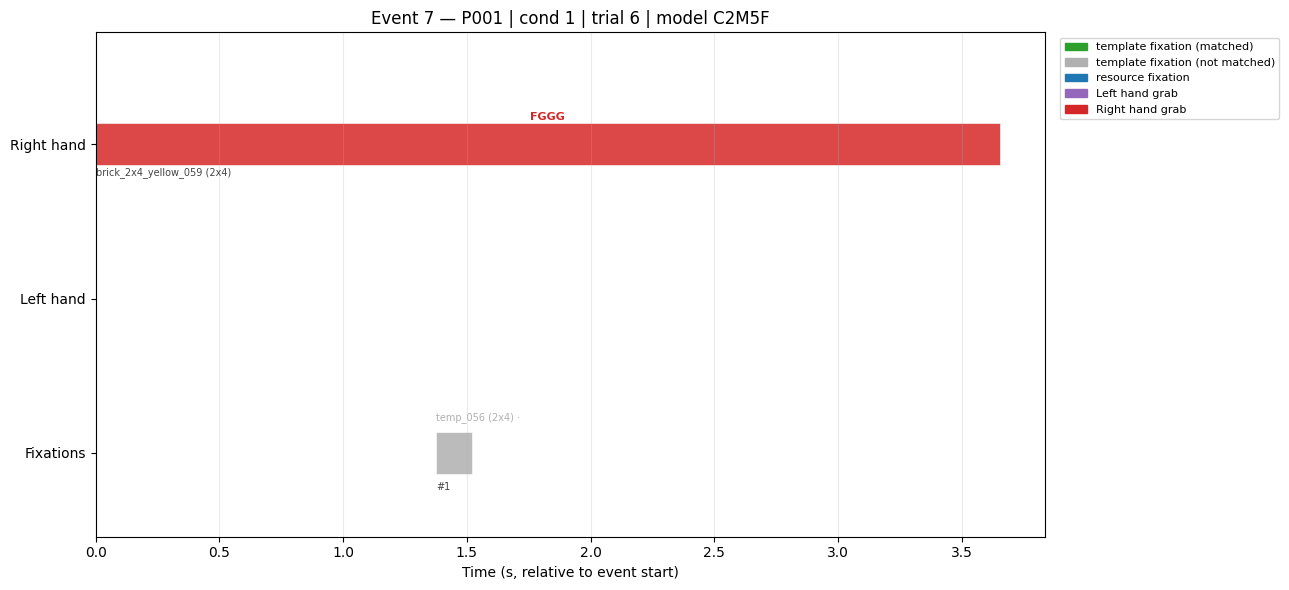

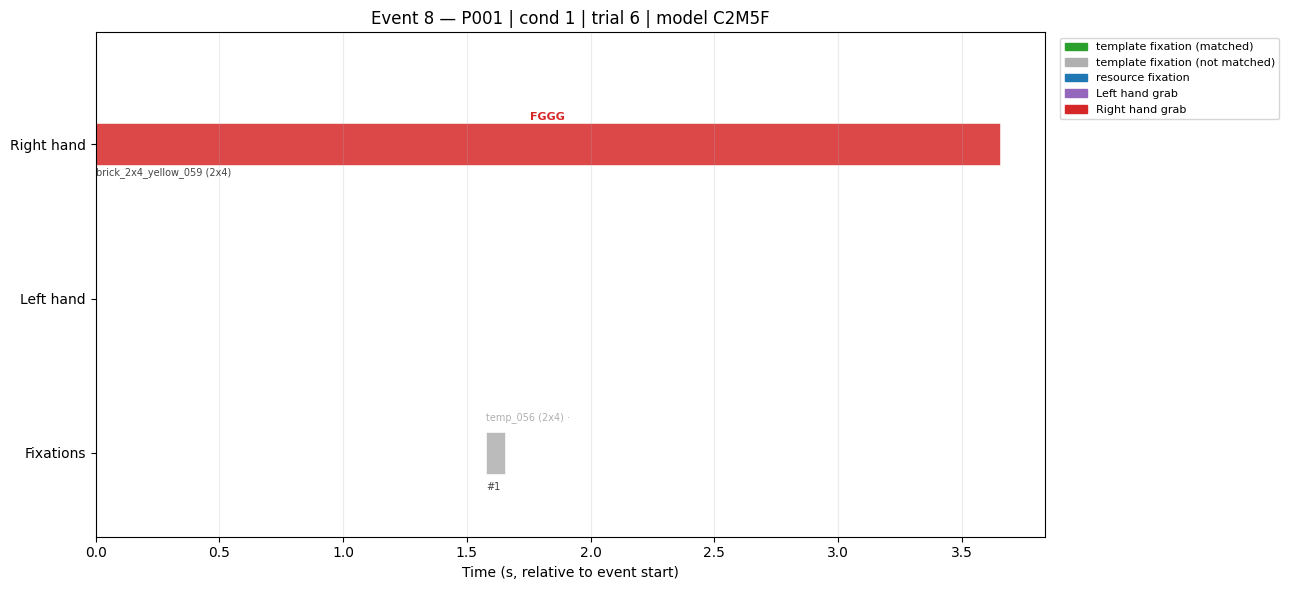

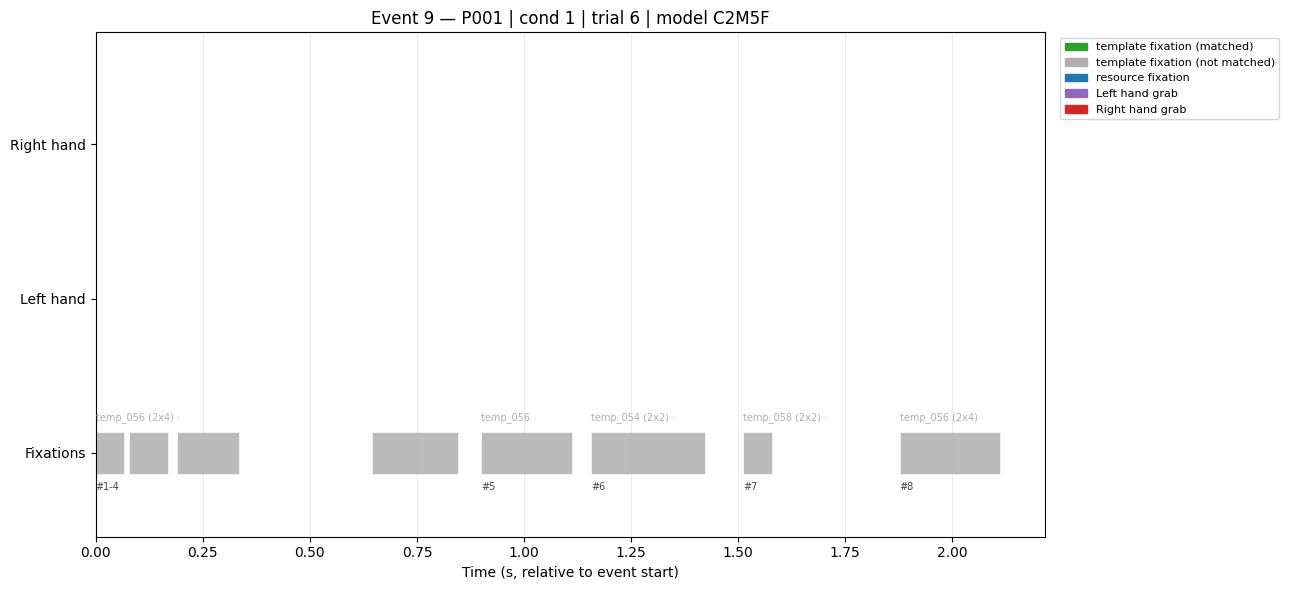

In [108]:
# Sanity-check style: rows for one specific event, as a dataframe (no plot)
rows = get_event_rows(
    brick_fixation_events_df,
    participant_id='001', condition_number=1, trial_number=6,
    model_name='C2M5F', event=1, match_typ='FGG',
)
print(rows)

# Every event in one trial, plotted
events = list_events(
    brick_fixation_events_df,
    participant_id='001', condition_number=1, trial_number=6, model_name='C2M5F',
)
plot_events(brick_fixation_events_df, grasp_events, events)

# Every FGGG anywhere, across all participants — replaces find_events_with_label
events = list_events(brick_fixation_events_df, match_typ='FGGG')
#plot_events(brick_fixation_events_df, grasp_events, events, max_plots=10)

# All FG-labeled events for one participant only
events = list_events(brick_fixation_events_df, participant_id='P001', match_typ='FG')
#plot_events(brick_fixation_events_df, grasp_events, events)

# Every event in one trial that contains ANY multi-grab chain (FGG or longer)
# — can't express "starts with FGG or FGGG or ..." as one column match, so
# this one still needs an explicit OR/regex rather than the match_typ kwarg:
multi_grab_mask = (
    brick_fixation_events_df['Match_Typ_Left'].str.match(r'^FGG+$', na=False)
    | brick_fixation_events_df['Match_Typ_Right'].str.match(r'^FGG+$', na=False)
)
events = (
    brick_fixation_events_df[multi_grab_mask]
    .dropna(subset=['event'])[TRIAL_GROUP_COLS + ['event']]
    .drop_duplicates()
)
#plot_events(brick_fixation_events_df, grasp_events, events)

# Sanity check 
- to see what happens after the last fixations on the template desk, when there was no further grab on the resource area. 

In [109]:
def load_preprocessed_participant(participant_id: str) -> pd.DataFrame:
    """Reconstruct preprocessed_data for ONE participant, on demand, by
    reading their raw CSV and re-running the same 6 preprocessing steps
    used in the pipeline. Needed because full preprocessed_data is no
    longer kept in memory across all participants (that's what caused
    the original memory blowup) — but rebuilding it for a single
    participant is cheap and safe."""
    participant_id = str(participant_id).zfill(3)
    csv_files = sorted(INPUT_FOLDER.glob('*.csv'))
    match = next(
        (f for f in csv_files if participant_id_from_filename(f.name) == participant_id),
        None,
    )
    if match is None:
        raise FileNotFoundError(f'No raw CSV found for participant {participant_id}')

    frame = pd.read_csv(match, low_memory=False)
    frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    if 'source_file' not in frame.columns:
        frame['source_file'] = match.name
    if 'participant_id' not in frame.columns:
        frame['participant_id'] = participant_id_from_filename(match.name)
    frame['participant_id'] = frame['participant_id'].astype('string').str.zfill(3)

    data = exclude_participants(frame, PARTICIPANT_IDS_TO_EXCLUDE)
    del frame
    data = remove_condition0(data)
    data = remove_specific_models_per_participant(data, MODEL_EXCLUSION_EXCEL, MODEL_EXCLUSION_SHEET)
    data = remove_non_building_models(data)
    data = swap_xz_columns(data)
    data = tech_obj_renaming(data)
    return data

In [110]:
# see which participants actually exist in the data
print(brick_fixation_events_df['participant_id'].unique())

# then, for a real participant, see what trial/model/condition combos exist
pid = '004'  # replace with an actual ID from the list above
print(
    brick_fixation_events_df[brick_fixation_events_df['participant_id'] == pid][
        ['condition_number', 'trial_number', 'model_name']
    ].drop_duplicates()
)

['001' '002' '003' '004' '005' '006' '007' '008' '009' '010' '011' '012'
 '013' '014' '015' '016' '017' '018' '019' '020' '021' '022' '023' '024'
 '025' '026' '027' '028' '029' '030' '031' '032' '033' '034' '035' '037'
 '038' '039' '040' '041' '042' '043' '044' '045' '046' '047' '048' '049'
 '050' '051']
      condition_number  trial_number model_name
3302                 1             1      C2M1F
3360                 1             2      C1M2A
3393                 1             3      C3M1F
3482                 1             4      C2M6A
3512                 1             5      C3M2A
3678                 1             6      C1M5F
3684                 2             1      C1M3F
3692                 2             2      C3M6A
3872                 2             3      C3M5F
3962                 2             4      C1M6A
3971                 2             5      C2M3F
3997                 2             6      C2M4A
4066                 3             1      C3M4A
4295                 3

In [111]:
rows_for_this_trial = get_event_rows(
    brick_fixation_events_df,
    participant_id='004', condition_number=1, trial_number=6, model_name='C1M5F',
)
last_row = rows_for_this_trial.sort_values('start_time').iloc[-1]

participant_raw = load_preprocessed_participant('004')

trial_mask = (
    (participant_raw['participant_id'] == '004')
    & (participant_raw['condition_number'] == 1)
    & (participant_raw['trial_number'] == 2)
)
trial_raw = participant_raw[trial_mask]

print('Last kept fixation ends at:', last_row['end_time'])
print('Trial data actually ends at:', trial_raw['raw_timestamp'].max())
print('Gap after last kept fixation (ms):', trial_raw['raw_timestamp'].max() - last_row['end_time'])

del participant_raw  # free it once you're done inspecting this trial
gc.collect()

Excluded participants found and removed: []
[remove_condition0] Removed 106294 rows (condition 0). Remaining: 561593
[model_exclusion] Removed 0 rows via participant/model exclusions.
[remove_non_building_models] Removed 238550 rows (TM/None). Remaining: 323043
[swap_xz_columns] Variables processed: 36 | Actually swapped: 36 | Columns: 141 → 141
[tech_obj_renaming] Processed object columns: 1
Last kept fixation ends at: 1778137243933
Trial data actually ends at: 1778136432752
Gap after last kept fixation (ms): -811181


6913

In [112]:
gap_start = last_row['end_time']
gap_end = trial_raw['raw_timestamp'].max()

# --- 1. What was the raw gaze doing in this window? ---
gap_gaze = trial_raw[
    (trial_raw['raw_timestamp'] >= gap_start) & (trial_raw['raw_timestamp'] <= gap_end)
].copy()

print('Raw samples in gap:', len(gap_gaze))
print('\nevent_type counts in gap:')
print(gap_gaze['event_type'].value_counts(dropna=False))

gap_gaze = prepare_fixation_sample_columns(gap_gaze)
print('\nfixation_category counts in gap (fixation samples only):')
print(gap_gaze[gap_gaze['event_type'] == 'fixation']['fixation_category'].value_counts(dropna=False))
print('\nhit_obj_group counts in gap (fixation samples only):')
print(gap_gaze[gap_gaze['event_type'] == 'fixation']['hit_obj_group'].value_counts(dropna=False).head(15))

# --- 2. Did ANY grab happen in this window, of any type? ---
grab_trial_mask = (
    (grasp_events['participant_id'] == '001')
    & (grasp_events['trial_condition'] == 1)
    & (grasp_events['trial_number'] == 6)
)
gap_grabs = grasp_events[
    grab_trial_mask
    & (grasp_events['onset_time'] <= gap_end)
    & (grasp_events['offset_time'] >= gap_start)
]

print('\nGrabs overlapping the gap (any grasp_type):')
print(gap_grabs[['hand', 'grasp_type', 'brick_type', 'onset_time', 'offset_time']])

Raw samples in gap: 0

event_type counts in gap:
Series([], Name: count, dtype: int64)

fixation_category counts in gap (fixation samples only):
Series([], Name: count, dtype: int64)

hit_obj_group counts in gap (fixation samples only):
Series([], Name: count, dtype: int64)

Grabs overlapping the gap (any grasp_type):
Empty DataFrame
Columns: [hand, grasp_type, brick_type, onset_time, offset_time]
Index: []


## Validate zero-grab (trailing) events

In [113]:
print('PARTICIPANT_LIMIT:', PARTICIPANT_LIMIT)
print('Participants in brick_fixation_events_df:', brick_fixation_events_df['participant_id'].nunique())
print(sorted(brick_fixation_events_df['participant_id'].unique()))

PARTICIPANT_LIMIT: None
Participants in brick_fixation_events_df: 50
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051']


In [114]:
def _resource_grabs_by_trial(grasp_events: pd.DataFrame) -> dict[tuple, pd.DataFrame]:
    """Filter + group resource-desk grabs by trial ONCE, so lookups are O(1) dict access
    instead of re-filtering the whole grasp_events table per event."""
    grabs = _prepare_resource_grabs(grasp_events)
    return {key: group for key, group in grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}


def find_zero_grab_events(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """Every event with no resource grabs, flagged as safe-to-exclude or suspicious.
    Single groupby pass over brick_fixation_events_df — scales to many participants."""
    grabs_by_trial = _resource_grabs_by_trial(grasp_events)
    rows = []

    grouped = brick_fixation_events_df.dropna(subset=['event']).groupby(
        TRIAL_GROUP_COLS + ['event'], dropna=False
    )

    for (*trial_key_vals, event_id), event_rows in grouped:
        trial_key = tuple(trial_key_vals)
        has_grab = (event_rows['Left_Grab'].notna() | event_rows['Right_Grab'].notna()).any()
        if has_grab:
            continue

        event_end = event_rows['end_time'].max()
        trial_grabs = grabs_by_trial.get(trial_key)
        suspicious = (
            (trial_grabs['onset_time'] > event_end).any()
            if trial_grabs is not None else False
        )

        rows.append({
            **dict(zip(TRIAL_GROUP_COLS, trial_key)),
            'event': event_id,
            'suspicious_later_grab_exists': suspicious,
        })

    return pd.DataFrame(rows)


# Keep this as a separate small utility for ad-hoc single-trial checks
# (e.g. when investigating one suspicious case by hand) — not used internally
# by find_zero_grab_events anymore, since that now uses the precomputed dict.
def trial_has_later_resource_grab(
    grasp_events: pd.DataFrame,
    trial_key: tuple,
    after_time,
) -> bool:
    grabs_by_trial = _resource_grabs_by_trial(grasp_events)
    trial_grabs = grabs_by_trial.get(trial_key)
    if trial_grabs is None:
        return False
    return (trial_grabs['onset_time'] > after_time).any()

In [115]:
zero_grab_events = find_zero_grab_events(brick_fixation_events_df, grasp_events)
zero_grab_events.to_csv(OUTPUT_FOLDER / 'zero_grab_events.csv', index=False)
print(f"Zero-grab events: {len(zero_grab_events)}")
print(f"Suspicious: {zero_grab_events['suspicious_later_grab_exists'].sum()}")

Zero-grab events: 566
Suspicious: 0


# Add a dataset for testing Statistical Analysis

In [ ]:
# For later testing
test_df = brick_fixation_events_df[brick_fixation_events_df['participant_id'] == '001'].copy()

# develop/test build_event_summary against test_df first
summary_test = build_event_summary(test_df)
print(summary_test.shape)
print(summary_test.head())

NameError: name 'build_event_summary' is not defined

In [116]:
def classify_event_grab_pattern(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """For every event, classify its grab pattern: none / single / simultaneous
    dual (both hands overlapping in time) / same-hand chain / sequential
    different-hand (no time overlap). Also records the Match_Typ sequence."""
    grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)
    all_grabs = _prepare_resource_grabs(grasp_events)
    grabs_by_trial = {key: g for key, g in all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}

    rows = []
    grouped = brick_fixation_events_df.dropna(subset=['event']).groupby(
        TRIAL_GROUP_COLS + ['event'], dropna=False
    )

    for (*trial_key_vals, event_id), event_rows in grouped:
        trial_key = tuple(trial_key_vals)
        trial_grabs = grabs_by_trial.get(trial_key, pd.DataFrame())
        grabs = _event_grabs(event_rows, trial_grabs, grab_labels, trial_key)

        n_grabs = len(grabs)
        if n_grabs == 0:
            pattern = 'no_grab'
        elif n_grabs == 1:
            pattern = 'single'
        else:
            hands = {g['hand'] for g in grabs}
            if len(hands) == 1:
                pattern = 'same_hand_chain'
            else:
                # any temporal overlap between a Left and a Right grab?
                left = [g for g in grabs if g['hand'] == 'Left']
                right = [g for g in grabs if g['hand'] == 'Right']
                overlap = any(
                    _intervals_overlap(l['onset_time'], l['offset_time'], r['onset_time'], r['offset_time'])
                    for l in left for r in right
                )
                pattern = 'simultaneous_dual' if overlap else 'sequential_different_hand'

        match_typ_seq = [str(g['match_typ']) for g in grabs]

        rows.append({
            **dict(zip(TRIAL_GROUP_COLS, trial_key)),
            'event': event_id,
            'n_grabs': n_grabs,
            'pattern': pattern,
            'match_typ_sequence': match_typ_seq,
        })

    return pd.DataFrame(rows)


event_patterns = classify_event_grab_pattern(brick_fixation_events_df, grasp_events)
print(event_patterns['pattern'].value_counts())
print()
print(event_patterns['n_grabs'].value_counts().sort_index())

pattern
simultaneous_dual            4607
single                       2719
no_grab                       566
same_hand_chain                48
sequential_different_hand      34
Name: count, dtype: int64

n_grabs
0      566
1     2719
2     3854
3      384
4      375
5       49
6       12
7       11
8        2
9        1
10       1
Name: count, dtype: int64


In [ ]:
print(event_patterns)

In [117]:
def classify_event_grab_pattern_v2(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """For every event, record exact n_grabs, the temporal hand sequence
    (e.g. 'L>R' or 'L>L>R'), and how many consecutive grab-pairs overlap
    in time — so multi-grab events can be inspected precisely instead of
    bucketed into single/dual/other."""
    grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)
    all_grabs = _prepare_resource_grabs(grasp_events)
    grabs_by_trial = {key: g for key, g in all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}

    rows = []
    grouped = brick_fixation_events_df.dropna(subset=['event']).groupby(
        TRIAL_GROUP_COLS + ['event'], dropna=False
    )

    for (*trial_key_vals, event_id), event_rows in grouped:
        trial_key = tuple(trial_key_vals)
        trial_grabs = grabs_by_trial.get(trial_key, pd.DataFrame())
        grabs = _event_grabs(event_rows, trial_grabs, grab_labels, trial_key)  # already time-sorted

        n_grabs = len(grabs)
        hand_seq = '>'.join(g['hand'][0] for g in grabs)  # e.g. 'L>R', 'L>L>R'
        match_typ_seq = '>'.join(str(g['match_typ']) for g in grabs)

        # how many CONSECUTIVE grab pairs (in time order) temporally overlap
        n_overlapping_consecutive_pairs = sum(
            1
            for a, b in zip(grabs, grabs[1:])
            if _intervals_overlap(a['onset_time'], a['offset_time'], b['onset_time'], b['offset_time'])
        )
        n_pairs = max(n_grabs - 1, 0)

        rows.append({
            **dict(zip(TRIAL_GROUP_COLS, trial_key)),
            'event': event_id,
            'n_grabs': n_grabs,
            'hand_sequence': hand_seq,
            'match_typ_sequence': match_typ_seq,
            'n_overlapping_consecutive_pairs': n_overlapping_consecutive_pairs,
            'n_pairs': n_pairs,
            'all_pairs_overlap': (n_overlapping_consecutive_pairs == n_pairs) if n_pairs > 0 else None,
            'no_pairs_overlap': (n_overlapping_consecutive_pairs == 0) if n_pairs > 0 else None,
        })

    return pd.DataFrame(rows)


event_patterns_v2 = classify_event_grab_pattern_v2(brick_fixation_events_df, grasp_events)

print('=== n_grabs distribution ===')
print(event_patterns_v2['n_grabs'].value_counts().sort_index())

print('\n=== Hand sequence patterns, per n_grabs (top 10 each) ===')
for n in sorted(event_patterns_v2['n_grabs'].unique()):
    if n == 0:
        continue
    subset = event_patterns_v2[event_patterns_v2['n_grabs'] == n]
    print(f'\n--- n_grabs = {n} (total {len(subset)}) ---')
    print(subset['hand_sequence'].value_counts().head(10))

print('\n=== Overlap summary for n_grabs >= 2 ===')
multi = event_patterns_v2[event_patterns_v2['n_grabs'] >= 2]
print('All consecutive pairs overlap:', multi['all_pairs_overlap'].sum())
print('No consecutive pairs overlap:', multi['no_pairs_overlap'].sum())
print('Partial overlap (some but not all):',
      len(multi) - multi['all_pairs_overlap'].sum() - multi['no_pairs_overlap'].sum())

print('\n=== Most common match_typ sequences, n_grabs >= 2 (top 15) ===')
print(multi['match_typ_sequence'].value_counts().head(15))

=== n_grabs distribution ===
n_grabs
0      566
1     2719
2     3854
3      384
4      375
5       49
6       12
7       11
8        2
9        1
10       1
Name: count, dtype: int64

=== Hand sequence patterns, per n_grabs (top 10 each) ===

--- n_grabs = 1 (total 2719) ---
hand_sequence
L    1370
R    1349
Name: count, dtype: int64

--- n_grabs = 2 (total 3854) ---
hand_sequence
R>L    2119
L>R    1692
R>R      35
L>L       8
Name: count, dtype: int64

--- n_grabs = 3 (total 384) ---
hand_sequence
R>L>R    139
L>R>R     93
L>R>L     47
R>L>L     46
R>R>L     28
L>L>R     27
R>R>R      3
L>L>L      1
Name: count, dtype: int64

--- n_grabs = 4 (total 375) ---
hand_sequence
L>R>L>R    117
R>L>R>L     95
L>R>R>L     79
R>L>L>R     57
R>L>R>R      8
L>L>R>R      5
R>R>R>L      3
R>R>L>R      3
L>R>R>R      2
R>R>L>L      2
Name: count, dtype: int64

--- n_grabs = 5 (total 49) ---
hand_sequence
L>R>R>L>R    7
L>R>L>R>R    7
L>R>L>R>L    6
R>L>R>R>L    4
R>L>R>L>R    3
L>L>R>R>L    3
R>L>L

In [118]:
def _is_clean_chain(labels: list[str]) -> bool:
    if not labels:
        return True
    if labels[0] != 'FG':
        return False
    for i in range(1, len(labels)):
        if labels[i] != 'F' + 'G' * (i + 1):
            return False
    return True


def build_event_summary(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """One row per event, classified into:
      - 'excluded_no_grab'            : no resource grab in the event
      - 'excluded_unclassified_start' : first grab has no prior template look at all (any timing)
      - 'excluded_inconsistent_chain' : 2+ grabs, chain resets mid-event
      - 'single' / 'dual_or_chain'    : PLANNING pattern -> F_match / set_match
      - 'confirmatory_single' / 'confirmatory_dual' : CONFIRMATORY pattern -> glance_match / set_glance_match

    Brick identity matching now uses dominant_group (fixation side) and
    brick_type (grab side), both reduced to just their numeric core via
    _numeric_brick_id — fixes the earlier issue where dominant_hit_obj_name
    could resolve to a stud's raw name or unrelated scenery instead of the
    brick actually being looked at.
    """
    grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)
    all_grabs = _prepare_resource_grabs(grasp_events)
    grabs_by_trial = {key: g for key, g in all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}

    rows = []
    grouped = brick_fixation_events_df.dropna(subset=['event']).groupby(
        TRIAL_GROUP_COLS + ['event'], dropna=False
    )

    for (*trial_key_vals, event_id), event_rows in grouped:
        trial_key = tuple(trial_key_vals)
        trial_grabs = grabs_by_trial.get(trial_key, pd.DataFrame())
        grabs = _event_grabs(event_rows, trial_grabs, grab_labels, trial_key)
        n_grabs = len(grabs)

        base = dict(zip(TRIAL_GROUP_COLS, trial_key))
        base.update(
            event=event_id, n_grabs=n_grabs,
            F_match=pd.NA, set_match=pd.NA,
            glance_match=pd.NA, set_glance_match=pd.NA,
            n_correct=pd.NA, n_missing=pd.NA, n_extra=pd.NA,
            grabbed_ids=None, fixated_ids=None,
        )

        if n_grabs == 0:
            base['category'] = 'excluded_no_grab'
            rows.append(base)
            continue

        labels = [str(g['match_typ']) for g in grabs]

        if labels[0] == 'unclassified':
            base['category'] = 'excluded_unclassified_start'
            rows.append(base)
            continue

        if n_grabs >= 2 and not _is_clean_chain(labels):
            base['category'] = 'excluded_inconsistent_chain'
            rows.append(base)
            continue

        # CHANGED: use brick_type -> _numeric_brick_id (was brick_type -> _canonical_brick_id)
        grabbed_ids = {_numeric_brick_id(g['brick_type']) for g in grabs}
        grabbed_ids.discard(None)
        base['grabbed_ids'] = grabbed_ids

        first_grab_start = min(g['onset_time'] for g in grabs)
        all_template_rows = event_rows[event_rows['brick_fixation'] == 'template']
        before_rows = all_template_rows[all_template_rows['start_time'] < first_grab_start]

        # CHANGED: use dominant_group -> _numeric_brick_id (was dominant_hit_obj_name -> _canonical_brick_id)
        fixated_before = {_numeric_brick_id(v) for v in before_rows['dominant_group'].dropna()}
        fixated_before.discard(None)
        fixated_any = {_numeric_brick_id(v) for v in all_template_rows['dominant_group'].dropna()}
        fixated_any.discard(None)

        is_planning = bool(fixated_before)
        fixated_ids = fixated_before if is_planning else fixated_any
        base['fixated_ids'] = fixated_ids

        n_correct = len(grabbed_ids & fixated_ids)
        n_missing = len(fixated_ids - grabbed_ids)
        n_extra = len(grabbed_ids - fixated_ids)

        if n_grabs == 1:
            match_value = bool(grabbed_ids & fixated_ids) if fixated_ids else False
            if is_planning:
                base.update(category='single', F_match=match_value)
            else:
                base.update(category='confirmatory_single', glance_match=match_value)
        else:
            set_match_value = (grabbed_ids == fixated_ids) if fixated_ids else False
            base.update(n_correct=n_correct, n_missing=n_missing, n_extra=n_extra)
            if is_planning:
                base.update(category='dual_or_chain', set_match=set_match_value)
            else:
                base.update(category='confirmatory_dual', set_glance_match=set_match_value)

        rows.append(base)

    return pd.DataFrame(rows)


event_summary = build_event_summary(brick_fixation_events_df, grasp_events)

print(event_summary['category'].value_counts())
print()
print('F_match (single, planning):')
print(event_summary.loc[event_summary['category'] == 'single', 'F_match'].value_counts(dropna=False))
print('\nset_match (dual_or_chain, planning):')
print(event_summary.loc[event_summary['category'] == 'dual_or_chain', 'set_match'].value_counts(dropna=False))
print('\nglance_match (confirmatory_single):')
print(event_summary.loc[event_summary['category'] == 'confirmatory_single', 'glance_match'].value_counts(dropna=False))
print('\nset_glance_match (confirmatory_dual):')
print(event_summary.loc[event_summary['category'] == 'confirmatory_dual', 'set_glance_match'].value_counts(dropna=False))

category
confirmatory_single            2101
dual_or_chain                  1950
confirmatory_dual              1895
excluded_inconsistent_chain     836
single                          614
excluded_no_grab                566
excluded_unclassified_start      12
Name: count, dtype: int64

F_match (single, planning):
F_match
True     371
False    243
Name: count, dtype: int64

set_match (dual_or_chain, planning):
set_match
False    1892
True       58
Name: count, dtype: int64

glance_match (confirmatory_single):
glance_match
False    1608
True      493
Name: count, dtype: int64

set_glance_match (confirmatory_dual):
set_glance_match
False    1890
True        5
Name: count, dtype: int64


In [119]:
unmatched = sorted(set(fix_ids) - set(grab_ids))

non_brick_pattern = re.compile(r'(?i)wall|plate|desk|base|floor|ceiling|volume|snap|ui')
stud_pattern = re.compile(r'(?i)stud')
malformed_temp_res = re.compile(r'(temp|res|dis)\d')  # token glued directly to digits, no underscore

buckets = {'non_brick_scenery': [], 'stud_subpart': [], 'malformed_id': [], 'other': []}

for uid in unmatched:
    if non_brick_pattern.search(uid):
        buckets['non_brick_scenery'].append(uid)
    elif stud_pattern.search(uid):
        buckets['stud_subpart'].append(uid)
    elif malformed_temp_res.search(uid):
        buckets['malformed_id'].append(uid)
    else:
        buckets['other'].append(uid)

for name, items in buckets.items():
    print(f'{name}: {len(items)} of {len(unmatched)}')
    print(' ', items[:8])
    print()

non_brick_scenery: 3 of 290
  ['Model_plate', 'Wall_Left', 'model_desk_base']

stud_subpart: 280 of 290
  ['stud_top_1_005', 'stud_top_1_006', 'stud_top_1_008', 'stud_top_1_011', 'stud_top_1_012', 'stud_top_1_013', 'stud_top_1_014', 'stud_top_1_016']

malformed_id: 1 of 290
  ['brick_2x2_blue_temp118']

other: 6 of 290
  ['brick_1x3_yellow_76', 'brick_2x2_blue_079', 'brick_2x2_green_002', 'brick_2x2_green_004', 'brick_2x2_pink_001', 'brick_2x2_pink_003']



In [121]:
mismatch = brick_fixation_events_df[
    (brick_fixation_events_df['brick_fixation'] == 'template')
    & (brick_fixation_events_df['dominant_group'].notna())
    & (brick_fixation_events_df['dominant_hit_obj_name'].notna())
].copy()

mismatch['num_from_group'] = mismatch['dominant_group'].apply(_numeric_brick_id)
mismatch['num_from_name'] = mismatch['dominant_hit_obj_name'].apply(_numeric_brick_id)

n_diff = (mismatch['num_from_group'] != mismatch['num_from_name']).sum()
print(f'{n_diff} of {len(mismatch)} rows disagree')
print(mismatch.loc[mismatch['num_from_group'] != mismatch['num_from_name'],
                    ['dominant_group', 'dominant_hit_obj_name']].drop_duplicates().head(15))

623 of 38322 rows disagree
     dominant_group      dominant_hit_obj_name
134        temp_070  brick_1x3_yellow_temp_069
161        temp_102                Model_plate
181        temp_098    brick_2x2_pink_temp_101
244        temp_097    brick_2x2_pink_temp_101
640        temp_116                  Wall_Left
664        temp_114    brick_2x2_pink_temp_115
707        temp_042  brick_2x4_yellow_temp_044
727        temp_044   brick_2x4_green_temp_042
833        temp_120   brick_2x4_green_temp_117
1150       temp_094    brick_2x2_blue_temp_095
1285       temp_093   brick_1x3_green_temp_092
1294       temp_029  brick_2x4_yellow_temp_031
1353       temp_027                  Wall_Left
1549       temp_126                  Wall_Left
1600       temp_119     brick_2x2_blue_temp118


In [122]:
fix_ids_v2 = brick_fixation_events_df.loc[
    brick_fixation_events_df['brick_fixation'] == 'template', 'dominant_group'
].dropna().apply(_numeric_brick_id)

grab_ids_v2 = _prepare_resource_grabs(grasp_events)['brick_type'].dropna().apply(_numeric_brick_id)

still_unmatched = set(fix_ids_v2) - set(grab_ids_v2)
print(f'{len(still_unmatched)} of {fix_ids_v2.nunique()} unique fixated IDs still unmatched')
print(sorted(still_unmatched)[:20])

0 of 126 unique fixated IDs still unmatched
[]


In [123]:
event_summary = build_event_summary(brick_fixation_events_df, grasp_events)
print(event_summary['category'].value_counts())
print()
print('F_match (single, planning):')
print(event_summary.loc[event_summary['category'] == 'single', 'F_match'].value_counts(dropna=False))
print('\nset_match (dual_or_chain, planning):')
print(event_summary.loc[event_summary['category'] == 'dual_or_chain', 'set_match'].value_counts(dropna=False))

category
confirmatory_single            2101
dual_or_chain                  1950
confirmatory_dual              1895
excluded_inconsistent_chain     836
single                          614
excluded_no_grab                566
excluded_unclassified_start      12
Name: count, dtype: int64

F_match (single, planning):
F_match
True     371
False    243
Name: count, dtype: int64

set_match (dual_or_chain, planning):
set_match
False    1892
True       58
Name: count, dtype: int64


In [120]:
# 1. Confirm _numeric_brick_id actually exists and does what we expect
print(_numeric_brick_id('stud_top_1_temp_005'))   # expect '5'
print(_numeric_brick_id('temp_008'))               # expect '8'
print(_numeric_brick_id('brick_2x2_pink_040_res_040'))  # expect '40' (or whatever your real format is)

# 2. Confirm dominant_group actually differs from dominant_hit_obj_name in your data
# (if this comes back 0, the fix has nothing to correct in the first place)
mismatch = brick_fixation_events_df[
    (brick_fixation_events_df['brick_fixation'] == 'template')
    & (brick_fixation_events_df['dominant_group'].notna())
    & (brick_fixation_events_df['dominant_hit_obj_name'].notna())
]
n_diff = (
    mismatch['dominant_group'].apply(_numeric_brick_id)
    != mismatch['dominant_hit_obj_name'].apply(_canonical_brick_id).apply(lambda x: re.sub(r'\D', '', str(x)) if x else None)
).sum()
print(f'Rows where dominant_group and dominant_hit_obj_name disagree: {n_diff} of {len(mismatch)}')

# 3. Check for a DUPLICATE build_event_summary definition somewhere later in
# the notebook that might be silently overriding the fixed one
import inspect
print(inspect.getsource(build_event_summary)[:500])  # does this show dominant_group or dominant_hit_obj_name?

# 4. Confirm event_summary was actually rebuilt just now, not a stale variable
print(id(event_summary))  # run this, then rerun build_event_summary cell, then rerun this line — id should change

5
8
40
Rows where dominant_group and dominant_hit_obj_name disagree: 38322 of 38322
def build_event_summary(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """One row per event, classified into:
      - 'excluded_no_grab'            : no resource grab in the event
      - 'excluded_unclassified_start' : first grab has no prior template look at all (any timing)
      - 'excluded_inconsistent_chain' : 2+ grabs, chain resets mid-event
      - 'single' / 'dual_or_chain'    : PLANNING pattern -> F_match / set_match
      - 'confirm
6118638176


"All fixated bricks grabbed, plus extra(s)" events: 296

Example:
  Participant 001 | trial 2 | event 1
  n_grabs=2  n_correct=1  n_missing=0  n_extra=1
  fixated_ids: {'8'}
  grabbed_ids: {'5', '8'}
  -> read as: '1 correct + 1 extra' (set_match=False, but not a total miss)


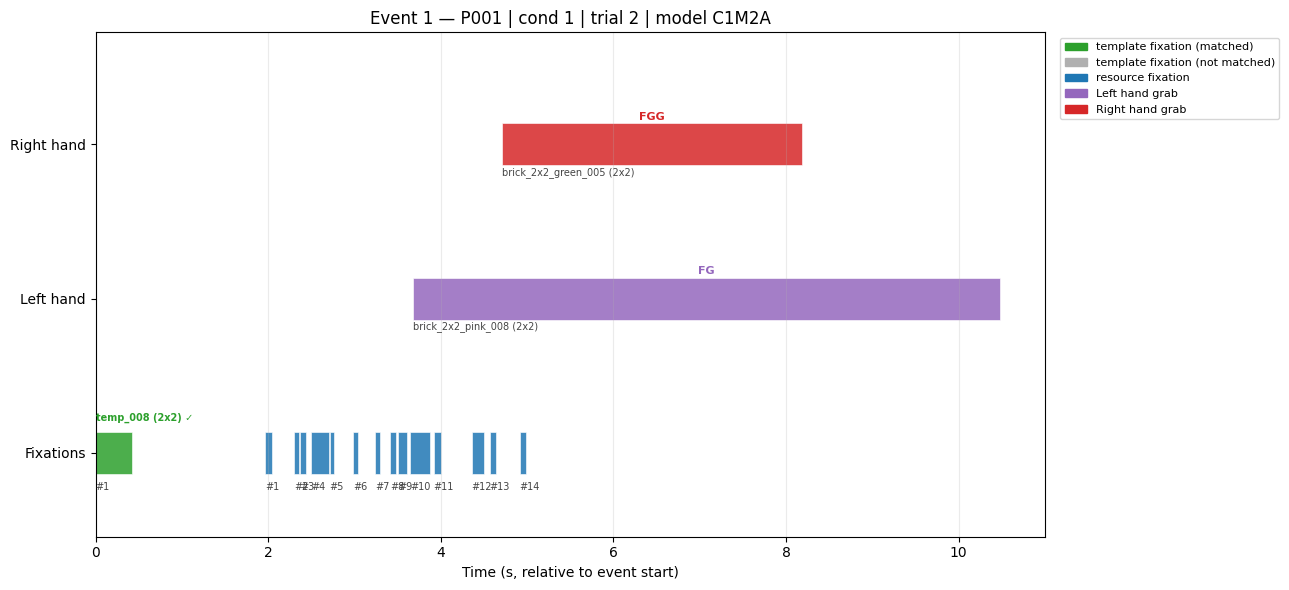

In [89]:
# Find a dual_or_chain event that's set_match=False due to extras, not
# total mismatch — i.e. everything fixated WAS grabbed, plus something else.
partial_extra = event_summary[
    (event_summary['category'] == 'dual_or_chain')
    & (event_summary['set_match'] == False)
    & (event_summary['n_missing'] == 0)
    & (event_summary['n_extra'] > 0)
]

print(f'"All fixated bricks grabbed, plus extra(s)" events: {len(partial_extra)}')

if not partial_extra.empty:
    example = partial_extra.iloc[0]
    print('\nExample:')
    print(f"  Participant {example['participant_id']} | trial {example['trial_number']} | "
          f"event {example['event']}")
    print(f"  n_grabs={example['n_grabs']}  "
          f"n_correct={example['n_correct']}  n_missing={example['n_missing']}  n_extra={example['n_extra']}")
    print(f"  fixated_ids: {example['fixated_ids']}")
    print(f"  grabbed_ids: {example['grabbed_ids']}")
    print(f"  -> read as: '{example['n_correct']} correct + {example['n_extra']} extra' "
          f"(set_match=False, but not a total miss)")

    # visualize it directly using the tooling you already have
    trial_key = tuple(example[col] for col in TRIAL_GROUP_COLS)
    plot_event_timeline(brick_fixation_events_df, grasp_events, trial_key, example['event'])

In [90]:
dual = event_summary[event_summary['category'] == 'dual_or_chain'].copy()
dual['n_fixated'] = dual['fixated_ids'].apply(len)

print('n_fixated vs n_grabs, for dual_or_chain events:')
print(pd.crosstab(dual['n_fixated'], dual['n_grabs']))

print('\nWhen set_match is False, why?')
false_dual = dual[dual['set_match'] == False]
print('  n_missing == 0 (all fixated bricks WERE grabbed, just extras too):',
      (false_dual['n_missing'] == 0).sum())
print('  n_correct == 0 (total mismatch, nothing fixated was grabbed):',
      (false_dual['n_correct'] == 0).sum())
print('  partial (some correct, some missing):',
      ((false_dual['n_correct'] > 0) & (false_dual['n_missing'] > 0)).sum())

# The exact event from your screenshot, for direct confirmation
example = event_summary[
    (event_summary['participant_id'].astype(str).str.zfill(3) == '001')
    & (event_summary['trial_number'] == 2) & (event_summary['condition_number'] == 1)
    & (event_summary['model_name'] == 'C1M2A') & (event_summary['event'] == 1)
]
print('\nThis exact plotted event:')
print(example[['n_grabs', 'category', 'set_match', 'n_correct', 'n_missing', 'n_extra',
                'fixated_ids', 'grabbed_ids']])

n_fixated vs n_grabs, for dual_or_chain events:
n_grabs     2   3   4   5   6   7   8   9   10
n_fixated                                     
1          162  25  55   8   1   0   0   0   0
2          212  38  62   8   1   0   0   0   0
3          249  51  62   6   1   2   1   0   1
4          233  61  45   6   0   1   1   0   0
5          180  55  28   5   3   3   0   0   0
6          104  35  16   5   0   1   0   0   0
7           82  14  13   4   2   2   0   0   0
8           34  11   6   4   0   0   0   0   0
9           22   5   3   1   1   0   0   0   0
10          14   1   2   0   0   1   0   1   0

When set_match is False, why?
  n_missing == 0 (all fixated bricks WERE grabbed, just extras too): 296
  n_correct == 0 (total mismatch, nothing fixated was grabbed): 248
  partial (some correct, some missing): 1348

This exact plotted event:
   n_grabs       category set_match n_correct n_missing n_extra fixated_ids  \
5        2  dual_or_chain     False         1         0       1  

Total n_correct==0 events: 248

n_fixated distribution for these:
n_fixated
1    83
2    75
3    40
4    35
5     9
6     3
7     2
8     1
Name: count, dtype: int64

Participant 051 | trial 3 | event 5 | n_grabs=3 | n_fixated=1
  fixated_ids: {'56'}
  grabbed_ids: {'57', '58', '59'}


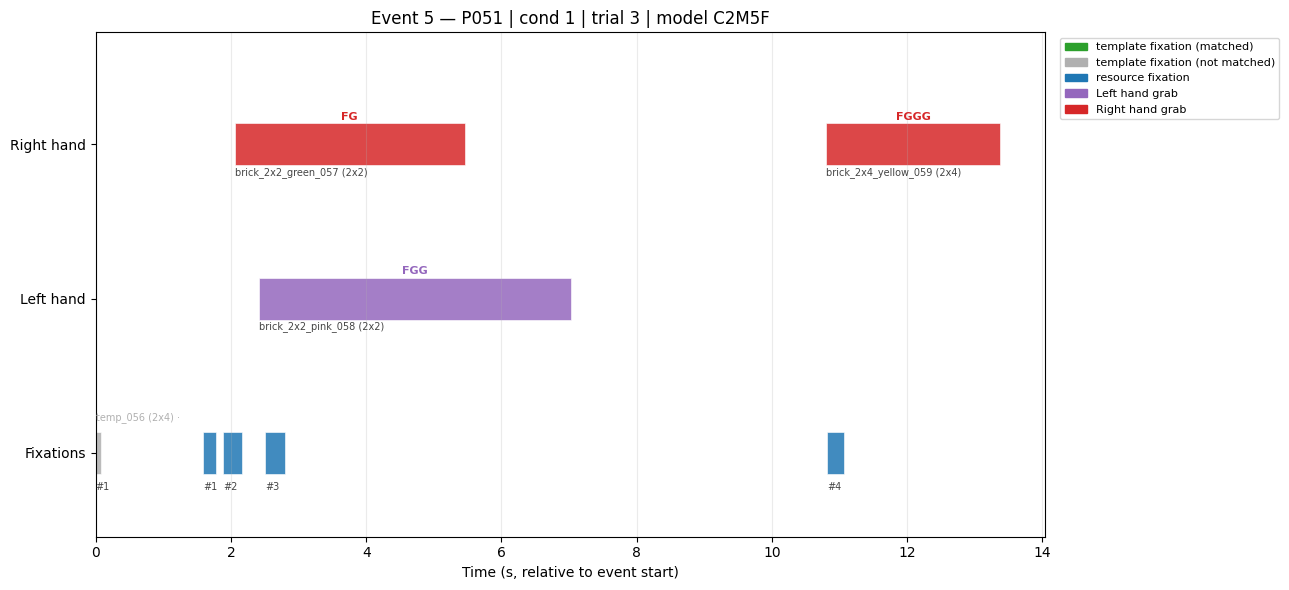


Participant 017 | trial 3 | event 10 | n_grabs=2 | n_fixated=1
  fixated_ids: {'73'}
  grabbed_ids: {'74', '72'}


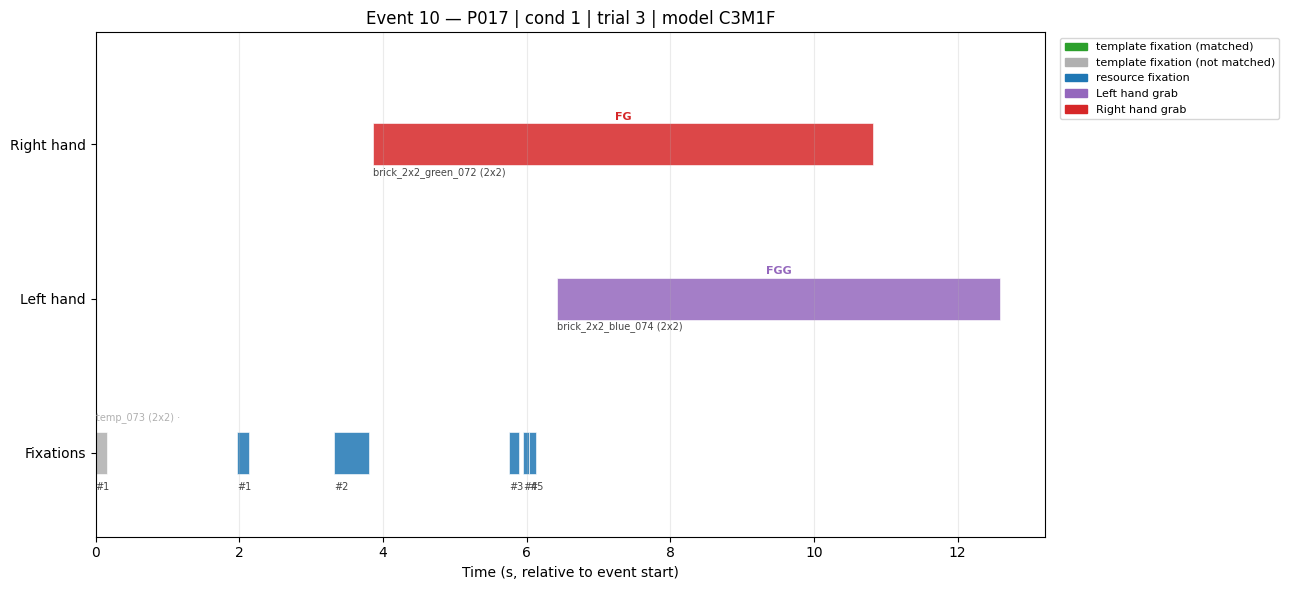


Participant 017 | trial 2 | event 5 | n_grabs=2 | n_fixated=1
  fixated_ids: {'28'}
  grabbed_ids: {'29', '30'}


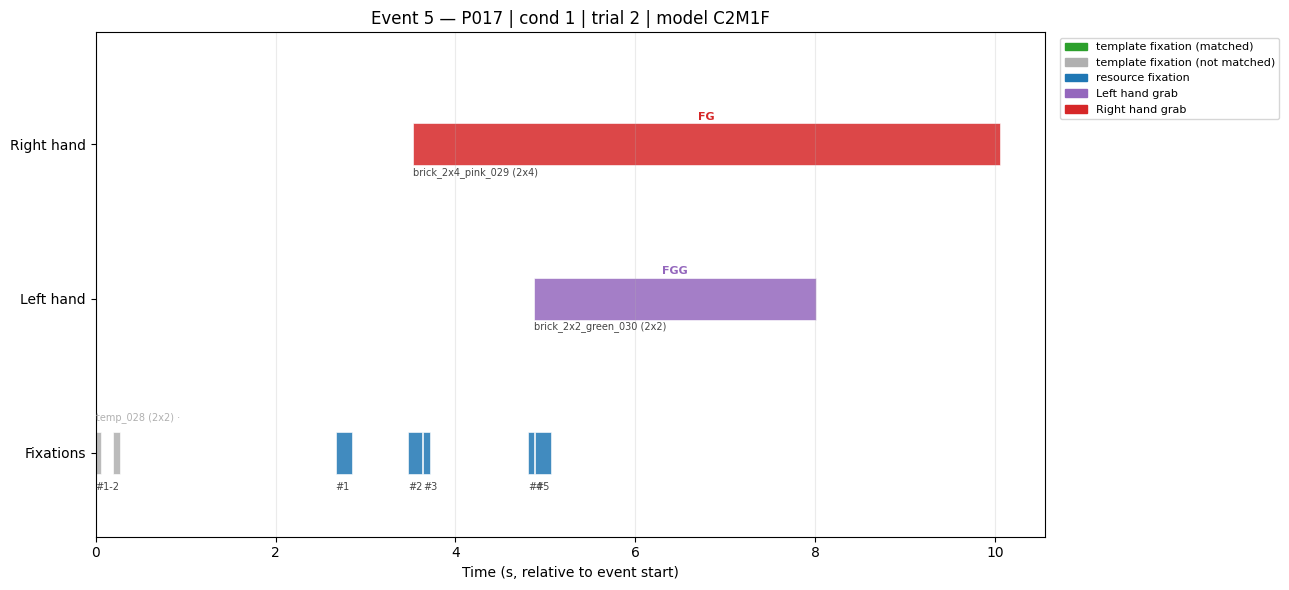

In [91]:
zero_overlap = dual = event_summary[
    (event_summary['category'] == 'dual_or_chain')
    & (event_summary['n_correct'] == 0)
].copy()

zero_overlap['n_fixated'] = zero_overlap['fixated_ids'].apply(len)

print(f'Total n_correct==0 events: {len(zero_overlap)}')
print('\nn_fixated distribution for these:')
print(zero_overlap['n_fixated'].value_counts().sort_index())

# Sample a few, prioritizing simple cases first (fewest fixations) so we're
# not starting with the most confusing high-scan-count examples
sample = zero_overlap.sort_values('n_fixated').head(3)

for _, row in sample.iterrows():
    print(f"\nParticipant {row['participant_id']} | trial {row['trial_number']} | "
          f"event {row['event']} | n_grabs={row['n_grabs']} | n_fixated={row['n_fixated']}")
    print(f"  fixated_ids: {row['fixated_ids']}")
    print(f"  grabbed_ids: {row['grabbed_ids']}")
    trial_key = tuple(row[col] for col in TRIAL_GROUP_COLS)
    plot_event_timeline(brick_fixation_events_df, grasp_events, trial_key, row['event'])

In [92]:
def fixation_before_first_grab(row) -> bool:
    """True if ANY template fixation timestamp in this event precedes the
    onset of the event's first (earliest) grab."""
    trial_key = tuple(row[col] for col in TRIAL_GROUP_COLS)
    event_rows = get_event_rows(brick_fixation_events_df, **dict(zip(TRIAL_GROUP_COLS, trial_key)), event=row['event'])

    template_rows = event_rows[event_rows['brick_fixation'] == 'template']
    if template_rows.empty:
        return False

    grab_rows = event_rows[event_rows['Left_Grab'].notna() | event_rows['Right_Grab'].notna()]
    if grab_rows.empty:
        return False

    first_grab_start = grab_rows['start_time'].min()
    return (template_rows['start_time'] < first_grab_start).any()


zero_overlap = event_summary[
    (event_summary['category'] == 'dual_or_chain') & (event_summary['n_correct'] == 0)
].copy()

zero_overlap['fixation_before_grab'] = zero_overlap.apply(fixation_before_first_grab, axis=1)
print(zero_overlap['fixation_before_grab'].value_counts())

fixation_before_grab
True    248
Name: count, dtype: int64


In [62]:
def _is_clean_chain(labels: list[str]) -> bool:
    """True when match_typ labels form one unbroken chain: FG, FGG, FGGG, ...
    with no reset (a second 'FG', or any label that isn't exactly one G
    longer than the previous one)."""
    if not labels:
        return True
    if labels[0] != 'FG':
        return False
    for i in range(1, len(labels)):
        expected = 'F' + 'G' * (i + 1)
        if labels[i] != expected:
            return False
    return True


def build_event_summary(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """One row per event, classified into:
      - 'excluded_no_grab'             : trailing events with no resource grab
      - 'excluded_unclassified_start'  : first grab has no prior template look at all
      - 'excluded_fixation_after_grab' : the event's template fixation(s) all occur AFTER
                                          the first grab already started — there's no fixation
                                          that could causally have informed that grab, so
                                          comparing fixated vs grabbed bricks isn't meaningful
                                          here (confirmed empirically: this explains ~79% of
                                          what looked like "complete mismatch" cases)
      - 'single'                       : exactly 1 grab, fixation precedes it -> F_match
      - 'dual_or_chain'                : 2+ grabs, one unbroken FG->FGG->... chain,
                                          fixation precedes first grab -> set_match
      - 'excluded_inconsistent_chain'  : 2+ grabs, chain resets mid-event (e.g. FG appears twice)

    F_match: loose version — grabbed brick was among ANY template(s) fixated
    BEFORE the first grab in the event.

    set_match: strict set equality (grabbed bricks == fixated-before-first-grab
    bricks). n_correct/n_missing/n_extra let you distinguish "extras only"
    from "true partial/complete mismatch" without changing set_match itself.
    """
    grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)
    all_grabs = _prepare_resource_grabs(grasp_events)
    grabs_by_trial = {key: g for key, g in all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}

    rows = []
    grouped = brick_fixation_events_df.dropna(subset=['event']).groupby(
        TRIAL_GROUP_COLS + ['event'], dropna=False
    )

    for (*trial_key_vals, event_id), event_rows in grouped:
        trial_key = tuple(trial_key_vals)
        trial_grabs = grabs_by_trial.get(trial_key, pd.DataFrame())
        grabs = _event_grabs(event_rows, trial_grabs, grab_labels, trial_key)
        n_grabs = len(grabs)

        base = dict(zip(TRIAL_GROUP_COLS, trial_key))
        base.update(
            event=event_id, n_grabs=n_grabs,
            F_match=pd.NA, set_match=pd.NA,
            n_correct=pd.NA, n_missing=pd.NA, n_extra=pd.NA,
            grabbed_ids=None, fixated_ids=None,
        )

        if n_grabs == 0:
            base['category'] = 'excluded_no_grab'
            rows.append(base)
            continue

        labels = [str(g['match_typ']) for g in grabs]

        if labels[0] == 'unclassified':
            base['category'] = 'excluded_unclassified_start'
            rows.append(base)
            continue

        # Only fixations that occurred BEFORE the first grab's onset can have
        # causally informed that grab — later fixations are incidental to
        # already-in-progress grabbing behavior, not a plan for it.
        first_grab_start = min(g['onset_time'] for g in grabs)
        template_rows = event_rows[
            (event_rows['brick_fixation'] == 'template')
            & (event_rows['start_time'] < first_grab_start)
        ]
        fixated_ids = {
            _canonical_brick_id(v) for v in template_rows['dominant_hit_obj_name'].dropna()
        }
        fixated_ids.discard(None)

        if not fixated_ids:
            base['category'] = 'excluded_fixation_after_grab'
            rows.append(base)
            continue

        grabbed_ids = {g['canonical_id'] for g in grabs if g['canonical_id']}
        base['grabbed_ids'] = grabbed_ids
        base['fixated_ids'] = fixated_ids

        if n_grabs == 1:
            base.update(category='single', F_match=bool(grabbed_ids & fixated_ids))

        elif _is_clean_chain(labels):
            n_correct = len(grabbed_ids & fixated_ids)
            n_missing = len(fixated_ids - grabbed_ids)
            n_extra = len(grabbed_ids - fixated_ids)
            base.update(
                category='dual_or_chain',
                set_match=(grabbed_ids == fixated_ids),
                n_correct=n_correct, n_missing=n_missing, n_extra=n_extra,
            )

        else:
            base['category'] = 'excluded_inconsistent_chain'

        rows.append(base)

    return pd.DataFrame(rows)


event_summary = build_event_summary(brick_fixation_events_df, grasp_events)

print(event_summary['category'].value_counts())
print()
print('F_match (single events):')
print(event_summary.loc[event_summary['category'] == 'single', 'F_match'].value_counts(dropna=False))
print()
print('set_match (dual_or_chain events):')
print(event_summary.loc[event_summary['category'] == 'dual_or_chain', 'set_match'].value_counts(dropna=False))

category
excluded_fixation_after_grab    4803
dual_or_chain                   1950
single                           614
excluded_no_grab                 566
excluded_inconsistent_chain       29
excluded_unclassified_start       12
Name: count, dtype: int64

F_match (single events):
F_match
True     354
False    260
Name: count, dtype: int64

set_match (dual_or_chain events):
set_match
False    1909
True       41
Name: count, dtype: int64


In [93]:
def _is_clean_chain(labels: list[str]) -> bool:
    if not labels:
        return True
    if labels[0] != 'FG':
        return False
    for i in range(1, len(labels)):
        if labels[i] != 'F' + 'G' * (i + 1):
            return False
    return True


def build_event_summary(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """One row per event, classified into:
      - 'excluded_no_grab'            : no resource grab in the event
      - 'excluded_unclassified_start' : first grab has no prior template look at all (any timing)
      - 'excluded_inconsistent_chain' : 2+ grabs, chain resets mid-event (e.g. FG appears twice)
      - 'single' / 'dual_or_chain'    : PLANNING pattern — a template fixation precedes the
                                         first grab -> F_match / set_match
      - 'confirmatory_single' / 'confirmatory_dual' : CONFIRMATORY pattern — no fixation precedes
                                         the first grab (grabbing was already underway); any
                                         template fixation elsewhere in the event is treated as
                                         an in-the-moment check/glance rather than a plan
                                         -> glance_match / set_glance_match

    F_match/set_match and glance_match/set_glance_match are mutually exclusive
    per row (only one pair is populated, depending on category) — this keeps
    the "planned" and "confirmatory" behaviors analytically separate rather
    than conflating them into one variable.
    """
    grab_labels = compute_grab_match_typ_labels(brick_fixation_events_df, grasp_events)
    all_grabs = _prepare_resource_grabs(grasp_events)
    grabs_by_trial = {key: g for key, g in all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)}

    rows = []
    grouped = brick_fixation_events_df.dropna(subset=['event']).groupby(
        TRIAL_GROUP_COLS + ['event'], dropna=False
    )

    for (*trial_key_vals, event_id), event_rows in grouped:
        trial_key = tuple(trial_key_vals)
        trial_grabs = grabs_by_trial.get(trial_key, pd.DataFrame())
        grabs = _event_grabs(event_rows, trial_grabs, grab_labels, trial_key)
        n_grabs = len(grabs)

        base = dict(zip(TRIAL_GROUP_COLS, trial_key))
        base.update(
            event=event_id, n_grabs=n_grabs,
            F_match=pd.NA, set_match=pd.NA,
            glance_match=pd.NA, set_glance_match=pd.NA,
            n_correct=pd.NA, n_missing=pd.NA, n_extra=pd.NA,
            grabbed_ids=None, fixated_ids=None,
        )

        if n_grabs == 0:
            base['category'] = 'excluded_no_grab'
            rows.append(base)
            continue

        labels = [str(g['match_typ']) for g in grabs]

        if labels[0] == 'unclassified':
            base['category'] = 'excluded_unclassified_start'
            rows.append(base)
            continue

        if n_grabs >= 2 and not _is_clean_chain(labels):
            base['category'] = 'excluded_inconsistent_chain'
            rows.append(base)
            continue

        grabbed_ids = {g['canonical_id'] for g in grabs if g['canonical_id']}
        base['grabbed_ids'] = grabbed_ids

        first_grab_start = min(g['onset_time'] for g in grabs)
        all_template_rows = event_rows[event_rows['brick_fixation'] == 'template']
        before_rows = all_template_rows[all_template_rows['start_time'] < first_grab_start]

        fixated_before = {_canonical_brick_id(v) for v in before_rows['dominant_hit_obj_name'].dropna()}
        fixated_before.discard(None)
        fixated_any = {_canonical_brick_id(v) for v in all_template_rows['dominant_hit_obj_name'].dropna()}
        fixated_any.discard(None)

        is_planning = bool(fixated_before)
        fixated_ids = fixated_before if is_planning else fixated_any
        base['fixated_ids'] = fixated_ids

        n_correct = len(grabbed_ids & fixated_ids)
        n_missing = len(fixated_ids - grabbed_ids)
        n_extra = len(grabbed_ids - fixated_ids)

        if n_grabs == 1:
            match_value = bool(grabbed_ids & fixated_ids) if fixated_ids else False
            if is_planning:
                base.update(category='single', F_match=match_value)
            else:
                base.update(category='confirmatory_single', glance_match=match_value)
        else:
            set_match_value = (grabbed_ids == fixated_ids) if fixated_ids else False
            base.update(n_correct=n_correct, n_missing=n_missing, n_extra=n_extra)
            if is_planning:
                base.update(category='dual_or_chain', set_match=set_match_value)
            else:
                base.update(category='confirmatory_dual', set_glance_match=set_match_value)

        rows.append(base)

    return pd.DataFrame(rows)


event_summary = build_event_summary(brick_fixation_events_df, grasp_events)

print(event_summary['category'].value_counts())
print()
print('F_match (single, planning):')
print(event_summary.loc[event_summary['category'] == 'single', 'F_match'].value_counts(dropna=False))
print('\nset_match (dual_or_chain, planning):')
print(event_summary.loc[event_summary['category'] == 'dual_or_chain', 'set_match'].value_counts(dropna=False))
print('\nglance_match (confirmatory_single):')
print(event_summary.loc[event_summary['category'] == 'confirmatory_single', 'glance_match'].value_counts(dropna=False))
print('\nset_glance_match (confirmatory_dual):')
print(event_summary.loc[event_summary['category'] == 'confirmatory_dual', 'set_glance_match'].value_counts(dropna=False))

category
confirmatory_single            2101
dual_or_chain                  1950
confirmatory_dual              1895
excluded_inconsistent_chain     836
single                          614
excluded_no_grab                566
excluded_unclassified_start      12
Name: count, dtype: int64

F_match (single, planning):
F_match
True     354
False    260
Name: count, dtype: int64

set_match (dual_or_chain, planning):
set_match
False    1909
True       41
Name: count, dtype: int64

glance_match (confirmatory_single):
glance_match
False    1638
True      463
Name: count, dtype: int64

set_glance_match (confirmatory_dual):
set_glance_match
False    1890
True        5
Name: count, dtype: int64


In [64]:
template_rows_all = brick_fixation_events_df[brick_fixation_events_df['brick_fixation'] == 'template']
n_missing_name = template_rows_all['dominant_hit_obj_name'].isna().sum()
print(f'Template fixation rows: {len(template_rows_all)}')
print(f'...of which missing dominant_hit_obj_name: {n_missing_name} '
      f'({100 * n_missing_name / len(template_rows_all):.1f}%)')

Template fixation rows: 38322
...of which missing dominant_hit_obj_name: 0 (0.0%)


In [65]:
fix_ids = brick_fixation_events_df.loc[
    brick_fixation_events_df['brick_fixation'] == 'template', 'dominant_hit_obj_name'
].dropna().apply(_canonical_brick_id)

grab_ids = _prepare_resource_grabs(grasp_events)['brick_type'].dropna().apply(_canonical_brick_id)

print('Unique canonical IDs from fixations, not appearing in ANY grab (sample):')
print(sorted(set(fix_ids) - set(grab_ids))[:20])
print(f'\n{len(set(fix_ids) - set(grab_ids))} of {fix_ids.nunique()} unique fixated brick IDs never appear among grabbed IDs')

Unique canonical IDs from fixations, not appearing in ANY grab (sample):
['Model_plate', 'Wall_Left', 'brick_1x3_yellow_76', 'brick_2x2_blue_079', 'brick_2x2_blue_temp118', 'brick_2x2_green_002', 'brick_2x2_green_004', 'brick_2x2_pink_001', 'brick_2x2_pink_003', 'model_desk_base', 'stud_top_1_005', 'stud_top_1_006', 'stud_top_1_008', 'stud_top_1_011', 'stud_top_1_012', 'stud_top_1_013', 'stud_top_1_014', 'stud_top_1_016', 'stud_top_1_017', 'stud_top_1_019']

290 of 409 unique fixated brick IDs never appear among grabbed IDs


In [94]:
unmatched = sorted(set(fix_ids) - set(grab_ids))

non_brick_pattern = re.compile(r'(?i)wall|plate|desk|base|floor|ceiling|volume|snap|ui')
stud_pattern = re.compile(r'(?i)stud')
malformed_temp_res = re.compile(r'(temp|res|dis)\d')  # token glued directly to digits, no underscore

buckets = {'non_brick_scenery': [], 'stud_subpart': [], 'malformed_id': [], 'other': []}

for uid in unmatched:
    if non_brick_pattern.search(uid):
        buckets['non_brick_scenery'].append(uid)
    elif stud_pattern.search(uid):
        buckets['stud_subpart'].append(uid)
    elif malformed_temp_res.search(uid):
        buckets['malformed_id'].append(uid)
    else:
        buckets['other'].append(uid)

for name, items in buckets.items():
    print(f'{name}: {len(items)} of {len(unmatched)}')
    print(' ', items[:8])
    print()

non_brick_scenery: 3 of 290
  ['Model_plate', 'Wall_Left', 'model_desk_base']

stud_subpart: 280 of 290
  ['stud_top_1_005', 'stud_top_1_006', 'stud_top_1_008', 'stud_top_1_011', 'stud_top_1_012', 'stud_top_1_013', 'stud_top_1_014', 'stud_top_1_016']

malformed_id: 1 of 290
  ['brick_2x2_blue_temp118']

other: 6 of 290
  ['brick_1x3_yellow_76', 'brick_2x2_blue_079', 'brick_2x2_green_002', 'brick_2x2_green_004', 'brick_2x2_pink_001', 'brick_2x2_pink_003']



# Naive Match-type approach

In [126]:
def naive_match_analysis(
    brick_fixation_events_df: pd.DataFrame,
    grasp_events: pd.DataFrame,
) -> pd.DataFrame:
    """Naive, time-order-only matching — independent of Match_Typ/event columns.

    1. Keep only trials with >=1 template fixation AND >=1 resource-desk grab.
    2. Walk the trial's fixation+grab timeline in order. Template fixations
       accumulate into a running 'fixation set'. Any run of CONSECUTIVE grabs
       (no fixation in between) forms one grab group: size 1 = single,
       size 2 = dual, size 3+ = multi_naive.
    3. Each grab in the group is checked against the fixation set accumulated
       since the LAST grab group (loose membership, not set equality). If it
       matches, the position of the matching fixation is recorded, counting
       backward from the most recent (1 = last fixation, 2 = second-last, ...).
    4. The fixation set is cleared after each grab group and starts fresh.

    One row per individual grab (not per group), so dual/multi groups produce
    multiple rows sharing the same grab_group_id.
    """
    all_grabs = _prepare_resource_grabs(grasp_events)

    template_by_trial = brick_fixation_events_df[
        brick_fixation_events_df['brick_fixation'] == 'template'
    ].groupby(TRIAL_GROUP_COLS, dropna=False)
    grabs_by_trial = all_grabs.groupby(TRIAL_GROUP_COLS, dropna=False)

    valid_trials = set(template_by_trial.groups.keys()) & set(grabs_by_trial.groups.keys())

    rows = []
    for trial_key in valid_trials:
        template_rows = template_by_trial.get_group(trial_key).copy()
        template_rows['numeric_id'] = template_rows['dominant_group'].apply(_numeric_brick_id)
        template_rows = template_rows.dropna(subset=['numeric_id'])

        trial_grabs = grabs_by_trial.get_group(trial_key).copy()
        trial_grabs['numeric_id'] = trial_grabs['brick_type'].apply(_numeric_brick_id)
        trial_grabs = trial_grabs.dropna(subset=['numeric_id'])

        if template_rows.empty or trial_grabs.empty:
            continue

        seq = [
            {'type': 'fixation', 'time': r['start_time'], 'numeric_id': r['numeric_id']}
            for _, r in template_rows.iterrows()
        ] + [
            {'type': 'grab', 'time': r['onset_time'], 'hand': r['hand'],
             'numeric_id': r['numeric_id'], 'brick_type': r['brick_type']}
            for _, r in trial_grabs.iterrows()
        ]
        seq.sort(key=lambda x: x['time'])

        fixation_set: list[str] = []  # most-recent last
        group_id = 0
        i = 0
        while i < len(seq):
            item = seq[i]
            if item['type'] == 'fixation':
                fixation_set.append(item['numeric_id'])
                i += 1
                continue

            group_id += 1
            grab_group = [item]
            j = i + 1
            while j < len(seq) and seq[j]['type'] == 'grab':
                grab_group.append(seq[j])
                j += 1
            i = j

            category = {1: 'single', 2: 'dual'}.get(len(grab_group), 'multi_naive')
            snapshot = list(fixation_set)
            n_fix = len(snapshot)

            for grab in grab_group:
                # rank 1 = most recent fixation (last in snapshot), 2 = second-last, ...
                match_ranks = [
                    n_fix - idx for idx, fid in enumerate(snapshot) if fid == grab['numeric_id']
                ]
                matched_rank = min(match_ranks) if match_ranks else None

                rows.append({
                    **dict(zip(TRIAL_GROUP_COLS, trial_key)),
                    'grab_group_id': group_id,
                    'group_size': len(grab_group),
                    'group_category': category,
                    'hand': grab['hand'],
                    'grab_time': grab['time'],
                    'grabbed_id': grab['numeric_id'],
                    'fixation_set_size': n_fix,
                    'fixation_set': snapshot,
                    'matched': matched_rank is not None,
                    'matched_fixation_rank': matched_rank,
                })

            fixation_set = []  # reset after this grab group

    return pd.DataFrame(rows)


naive_matches = naive_match_analysis(brick_fixation_events_df, grasp_events)

print(naive_matches['group_category'].value_counts())
print()
print('Match rate overall:')
print(naive_matches['matched'].value_counts(normalize=True))
print()
print('Match rate by group category:')
print(naive_matches.groupby('group_category')['matched'].mean())
print()
print('Distribution of matched_fixation_rank (when matched):')
print(naive_matches.loc[naive_matches['matched'], 'matched_fixation_rank'].value_counts().sort_index().head(10))

group_category
dual           3012
multi_naive    2704
single          725
Name: count, dtype: int64

Match rate overall:
matched
True     0.615743
False    0.384257
Name: proportion, dtype: float64

Match rate by group category:
group_category
dual           0.623838
multi_naive    0.619083
single         0.569655
Name: matched, dtype: float64

Distribution of matched_fixation_rank (when matched):
matched_fixation_rank
1.0     1417
2.0      773
3.0      475
4.0      322
5.0      219
6.0      155
7.0      122
8.0       77
9.0       63
10.0      60
Name: count, dtype: int64


In [129]:
naive_matches

,participant_id,condition_number,trial_number,model_name,grab_group_id,group_size,group_category,hand,grab_time,grabbed_id,fixation_set_size,fixation_set,matched,matched_fixation_rank
0,018,3,2,C2M2A,1,3,multi_naive,Right,1779102294024,33,28,"[34, 34, 36, 36, 36, 34, 34, 35, 34, 34, 34, 3...",True,1.0
1,018,3,2,C2M2A,1,3,multi_naive,Left,1779102294547,35,28,"[34, 34, 36, 36, 36, 34, 34, 35, 34, 34, 34, 3...",True,2.0
2,018,3,2,C2M2A,1,3,multi_naive,Right,1779102309713,34,28,"[34, 34, 36, 36, 36, 34, 34, 35, 34, 34, 34, 3...",True,4.0
3,018,3,2,C2M2A,2,1,single,Right,1779102326179,32,6,"[34, 36, 36, 36, 36, 36]",False,NaN
4,018,3,2,C2M2A,3,3,multi_naive,Right,1779102343557,36,19,"[35, 34, 34, 36, 34, 36, 34, 34, 36, 37, 36, 3...",True,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6436,037,3,3,C1M4A,1,5,multi_naive,Right,1780473077395,14,26,"[16, 16, 16, 16, 16, 16, 16, 16, 16, 14, 15, 1...",True,13.0
6437,037,3,3,C1M4A,1,5,multi_naive,Left,1780473077583,14,26,"[16, 16, 16, 16, 16, 16, 16, 16, 16, 14, 15, 1...",True,13.0
6438,037,3,3,C1M4A,1,5,multi_naive,Right,1780473078361,13,26,"[16, 16, 16, 16, 16, 16, 16, 16, 16, 14, 15, 1...",True,4.0
6439,037,3,3,C1M4A,1,5,multi_naive,Right,1780473096361,15,26,"[16, 16, 16, 16, 16, 16, 16, 16, 16, 14, 15, 1...",True,16.0


In [128]:
print(naive_matches.groupby('group_category')['matched'].mean())

group_category
dual           0.623838
multi_naive    0.619083
single         0.569655
Name: matched, dtype: float64


# 3. Statistical Analysis Dataset

Create separate datasets for:

* Single-grab events
* Dual-grab events

Each dataset should contain:

* Participant
* Trial
* Condition
* Event identifier
* Dependent variable (`F_match` or `set_match`)

These datasets are used as input for the logistic mixed-effects models.

In [263]:
# code

# 6. Descriptive Statistics

For reporting descriptive statistics, inspect distributions of variables such as:

*number of events per participant,
*events per condition,
*single vs. dual grabs,
*proportion of matches.

These checks are primarily for identifying outliers or extremely sparse data rather than satisfying model assumptions.

In [264]:
#code and plots

# 7. Logistic Mixed-Effects Models

Fit separate logistic mixed-effects models for:

* Single-grab correspondence (`F_match`)
* Dual-grab correspondence (`set_match`)

Both models include:

* **Fixed effect**

  * Experimental condition

* **Random intercepts**

  * Participant
  * Trial nested within participant

The models estimate whether fixation–selection correspondence differs across experimental conditions while accounting for repeated observations and the hierarchical structure of the data.

In [265]:
# code

# 8. Permutation Baseline

To evaluate whether the observed fixation–selection correspondence exceeds chance levels, construct a permutation-based null model.

Is assumtion free, but need to verify that:

*permutations preserve participant boundaries,
*permutations preserve trial boundaries,
*event order is maintained,
*only fixation assignments are shuffled.

For each participant and trial:

* Preserve:

  * Event order
  * Number of events
  * Grab timing
  * Selected resource brick(s)

* Randomly shuffle:

  * The fixation assignments (`F1` and `F2`) across events.

Following each shuffle:

* Recompute `F_match` for all single-grab events.
* Recompute `set_match` for all dual-grab events.

Repeat this procedure across a large number of permutations to generate null distributions of fixation–selection correspondence.

In [266]:
# code


# 9. Comparison with the Null Distribution

Calculate the observed correspondence rate from the original event matrix.

Compare this observed value against the permutation-derived null distribution to determine whether fixation–selection correspondence is greater than expected by chance while preserving the temporal and hierarchical structure of the experimental data.

In [267]:
# code

# Main
here everything to execute all above.

In [15]:
# =====================================================================
# Main execution — memory-safe streaming version
# Processes ONE participant CSV at a time: load -> preprocess -> grasp ->
# fixation -> event detection -> discard the large raw frame -> next file.
# Never holds more than ~1 participant's raw data in memory at once.
# =====================================================================

import gc


def run_grasp_analysis(data: pd.DataFrame):
    """Chunk, label and categorise grasps for every participant and both hands."""
    hands = ['Left', 'Right']
    grasp_events_per_participant = []
    transport_ids_per_participant: dict = {}

    participant_groups = list(data.groupby('participant_id'))
    for participant_id, participant_df in tqdm(participant_groups, desc="Grasp analysis", unit="participant"):
        participant_df = participant_df.copy()
        participant_df = grasp_chunking(participant_df, hand=None)
        participant_df = interpolate_brick_labels(participant_df)

        for hand in hands:
            grasp_events = identify_grasp_onset_offset(participant_df, hand)
            if grasp_events.empty:
                continue
            grasp_events, transport_ids = categorise_grasps(grasp_events, resource_pos, work_pos, hand)
            grasp_events['participant_id'] = participant_id
            grasp_events_per_participant.append(grasp_events)
            transport_ids_per_participant[(participant_id, hand)] = transport_ids

    all_grasp_events = (
        pd.concat(grasp_events_per_participant, ignore_index=True)
        if grasp_events_per_participant
        else pd.DataFrame()
    )
    return all_grasp_events, transport_ids_per_participant


def process_single_participant_file(csv_file: Path):
    """Run the full pipeline for ONE participant file and return only the
    small, aggregated outputs. The large raw/preprocessed frame is deleted
    before returning, so it can't accumulate across participants."""

    frame = pd.read_csv(csv_file, low_memory=False)
    frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    if 'source_file' not in frame.columns:
        frame['source_file'] = csv_file.name
    if 'participant_id' not in frame.columns:
        frame['participant_id'] = participant_id_from_filename(csv_file.name)
    frame['participant_id'] = frame['participant_id'].astype('string').str.zfill(3)

    data = exclude_participants(frame, PARTICIPANT_IDS_TO_EXCLUDE)
    del frame
    if data.empty:
        return None

    data = remove_condition0(data)
    data = remove_specific_models_per_participant(data, MODEL_EXCLUSION_EXCEL, MODEL_EXCLUSION_SHEET)
    data = remove_non_building_models(data)
    data = swap_xz_columns(data)
    data = tech_obj_renaming(data)
    if data.empty:
        return None

    template_positions = data.loc[
        data['hit_obj_name'].astype(str).str.contains('_temp_', na=False),
        ['object_position_x', 'object_position_z'],
    ].copy()
    template_positions['hit_obj_name'] = '_temp_'

    grasp_events, transport_ids = run_grasp_analysis(data)
    fixation_runs_df, saved_fixations = run_fixation_analysis(data)
    brick_fixation_events_df = build_unified_fixation_grab_df(fixation_runs_df, grasp_events)

    del data
    gc.collect()

    return {
        'grasp_events': grasp_events,
        'fixation_runs_df': fixation_runs_df,
        'saved_fixations': saved_fixations,
        'brick_fixation_events_df': brick_fixation_events_df,
        'template_positions': template_positions,
    }


CACHE_DIR = OUTPUT_FOLDER / 'cache'
CACHE_DIR.mkdir(exist_ok=True)


def run_pipeline_streaming(force_rebuild: bool = False):
    """Memory-safe replacement for main(). Computes + SAVES everything;
    does NOT plot and does NOT compute model_pos — both happen in the
    separate visualization cell, which reads from these cached CSVs."""
    cache_files = {
        'grasp_events': CACHE_DIR / 'grasp_events.csv',
        'fixation_runs_df': CACHE_DIR / 'fixation_runs_df.csv',
        'saved_fixations': CACHE_DIR / 'saved_fixations.csv',
        'brick_fixation_events_df': CACHE_DIR / 'brick_fixation_events_df.csv',
        'template_positions': CACHE_DIR / 'template_positions.csv',
    }

    if not force_rebuild and all(p.exists() for p in cache_files.values()):
        print(f'[run_pipeline_streaming] Loading cached outputs from {CACHE_DIR}')
        return tuple(
            pd.read_csv(cache_files[k])
            for k in ('grasp_events', 'fixation_runs_df', 'brick_fixation_events_df')
        )

    csv_files = sorted(INPUT_FOLDER.glob('*.csv'))
    if PARTICIPANT_LIMIT is not None:
        csv_files = csv_files[:PARTICIPANT_LIMIT]

    grasp_chunks, fixation_chunks, saved_fix_chunks, event_chunks, template_pos_chunks = [], [], [], [], []

    for csv_file in tqdm(csv_files, desc='Processing participants', unit='participant'):
        result = process_single_participant_file(csv_file)
        if result is None:
            continue
        grasp_chunks.append(result['grasp_events'])
        fixation_chunks.append(result['fixation_runs_df'])
        saved_fix_chunks.append(result['saved_fixations'])
        event_chunks.append(result['brick_fixation_events_df'])
        template_pos_chunks.append(result['template_positions'])
        del result
        gc.collect()

    grasp_events = pd.concat(grasp_chunks, ignore_index=True) if grasp_chunks else pd.DataFrame()
    fixation_runs_df = pd.concat(fixation_chunks, ignore_index=True) if fixation_chunks else pd.DataFrame()
    saved_fixations = pd.concat(saved_fix_chunks, ignore_index=True) if saved_fix_chunks else pd.DataFrame()
    brick_fixation_events_df = pd.concat(event_chunks, ignore_index=True) if event_chunks else pd.DataFrame()
    all_template_positions = (
        pd.concat(template_pos_chunks, ignore_index=True) if template_pos_chunks else pd.DataFrame()
    )

    # --- Save FIRST, before any plotting happens ---
    grasp_events.to_csv(cache_files['grasp_events'], index=False)
    fixation_runs_df.to_csv(cache_files['fixation_runs_df'], index=False)
    saved_fixations.to_csv(cache_files['saved_fixations'], index=False)
    brick_fixation_events_df.to_csv(cache_files['brick_fixation_events_df'], index=False)
    all_template_positions.to_csv(cache_files['template_positions'], index=False)
    print(f'[run_pipeline_streaming] Cached outputs to {CACHE_DIR}')

    diagnose_grasp_areas(grasp_events, resource_pos, work_pos)

    return grasp_events, fixation_runs_df, brick_fixation_events_df


# Execute the full analysis pipeline (cached after the first run).
# Set force_rebuild=True whenever you change preprocessing/grasp/fixation
# logic upstream, so you don't silently analyze stale cached data.
grasp_events, fixation_runs_df, brick_fixation_events_df = run_pipeline_streaming(force_rebuild=True)

Processing participants:   0%|          | 0/52 [00:00<?, ?participant/s]

Excluded participants found and removed: []
[remove_condition0] Removed 93486 rows (condition 0). Remaining: 553478
[model_exclusion] Removed 0 rows via participant/model exclusions.
[remove_non_building_models] Removed 199096 rows (TM/None). Remaining: 354382
[swap_xz_columns] Variables processed: 36 | Actually swapped: 36 | Columns: 141 → 141
[tech_obj_renaming] Processed object columns: 1


Grasp type counts:
grasp_type
building      72
transport     56
correction     8
returning      1
Name: count, dtype: int64


Grasp analysis: 100%|██████████| 1/1 [00:01<00:00,  1.38s/participant]

Grasp type counts:
grasp_type
unknown       83
building      80
transport     73
correction    10
returning      2
Name: count, dtype: int64


...

Fixation analysis: 100%|██████████| 1/1 [00:03<00:00,  3.76s/participant]


[run_fixation_analysis] Total fixation runs: 2083
[run_fixation_analysis] Saved runs: 804 -> ../data/output/fixation_runs.csv
[run_fixation_analysis] Saved category counts:
fixation_category
template                 532
res_on_resource_table    272
Name: count, dtype: int64


/var/folders/l9/865lsfkx5mq6b0r7t3k3416m0000gn/T/ipykernel_48526/1956590867.py:226: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  unified = pd.concat(
Processing participants: 100%|██████████| 52/52 [20:04<00:00, 23.16s/participant]

Excluded participants found and removed: []
[remove_condition0] Removed 44765 rows (condition 0). Remaining: 0
[model_exclusion] Removed 0 rows via participant/model exclusions.
[remove_non_building_models] Removed 0 rows (TM/None). Remaining: 0
[swap_xz_columns] Variables processed: 36 | Actually swapped: 36 | Columns: 141 → 141
[tech_obj_renaming] Processed object columns: 0


[run_pipeline_streaming] Cached outputs to ../data/output/cache
[diagnose_grasp_areas] Boundaries -> resource x(0.7, 2.2) z(-0.8, 1.1) | work x(-0.8, 0.6) z(0.3, 1.15)
  onset_pos_x: q05=-1.07 q25=-0.97 med=0.04 q75=1.59 q95=1.85
  onset_pos_z: q05=-0.36 q25=0.03 med=0.50 q75=0.75 q95=1.00
  offset_pos_x: q05=-1.07 q25=-0.97 med=-0.05 q75=0.08 q95=0.71
  offset_pos_z: q05=0.08 q25=0.50 med=0.77 q75=0.97 q95=1.04
  [resource bricks n=11239] pickup onset_x q05=-0.15 q25=0.03 med=1.56 q75=1.75 q95=1.90
                              pickup onset_z q05=-0.41 q25=-0.17 med=0.10 q75=0.91 q95=1.03
                              placed offset_x q05=-0.17 q25=-0.07 med=-0.00 q75=0.08 q95=0.33
                              placed offset_z q05=0.70 q25=0.91 med=0.97 q75=1.01 q95=1.06


[derive_model_pos_from_template_bricks] n=3350505 template samples -> x=(np.float64(-1.60527208), np.float64(-1.38872792)) z=(np.float64(0.316483292), np.float64(0.5510731080000001))
[plot_grasp_areas_fast] Saved plot to: ../data/output/grasp_areas_plot.png


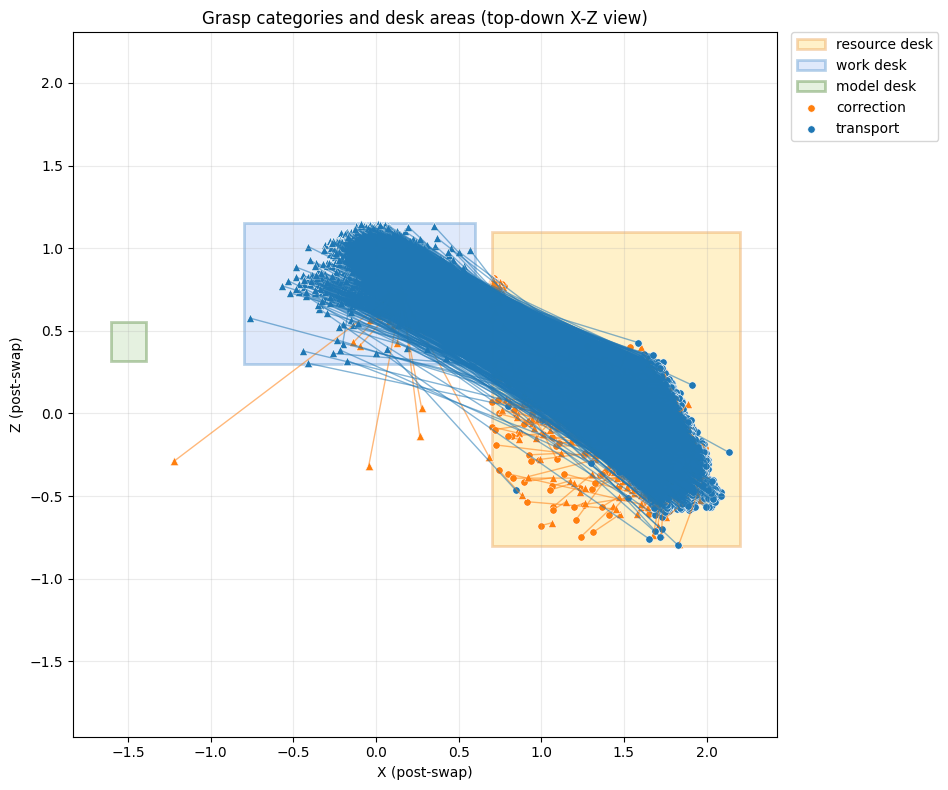

[plot_fixation_areas_fast] Saved plot to: ../data/output/fixation_areas_plot.png


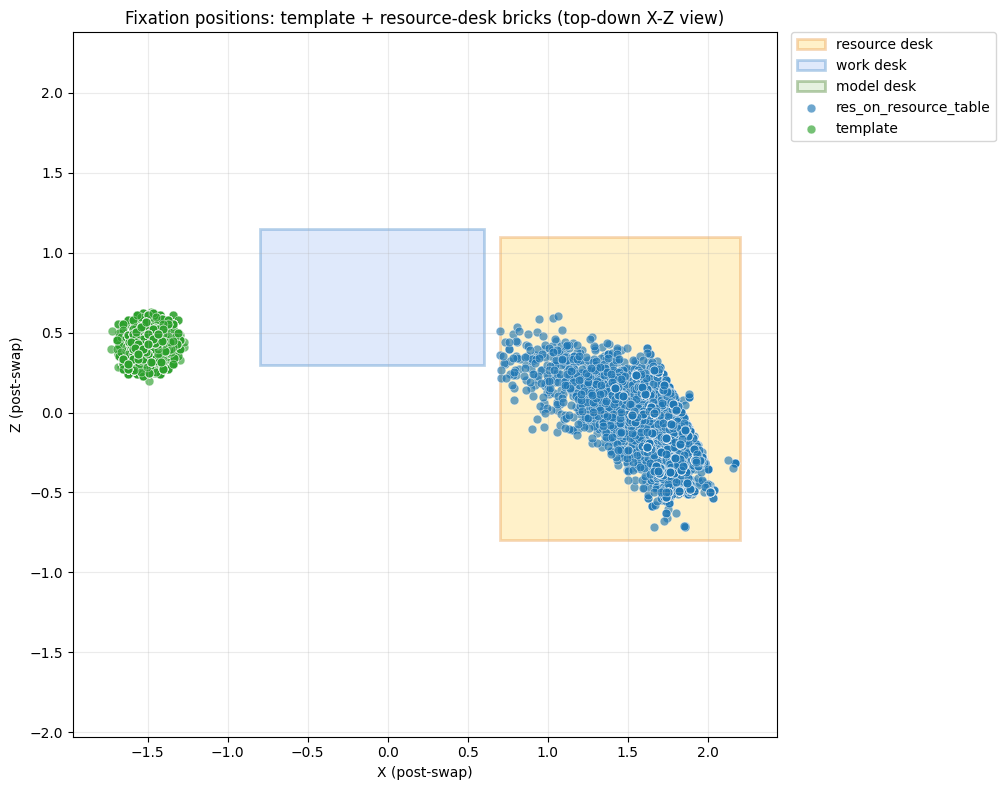

In [ ]:
# =====================================================================
# Visualization — reads cached results, plots with vectorized scatter/
# LineCollection calls instead of per-row ax.plot()/ax.scatter()
# =====================================================================

from matplotlib.collections import LineCollection

saved_fixations = pd.read_csv(CACHE_DIR / 'saved_fixations.csv')
template_positions = pd.read_csv(CACHE_DIR / 'template_positions.csv')

model_pos = derive_model_pos_from_template_bricks(template_positions)


def plot_grasp_areas_fast(grasp_events, resource_pos, workplace_pos, model_pos, output_path=None):
    if grasp_events.empty:
        print('[plot_grasp_areas_fast] No grasp events to plot.')
        return

    allowed = {'correction', 'transport'}
    grasp_events = grasp_events[grasp_events['grasp_type'].isin(allowed)]

    category_colors = {
        'transport': '#1f77b4', 'building': '#2ca02c',
        'correction': '#ff7f0e', 'returning': '#9467bd', 'unknown': '#7f7f7f',
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points, z_points = [], []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    for grasp_type, group in grasp_events.groupby('grasp_type'):
        color = category_colors.get(grasp_type, category_colors['unknown'])

        segments = list(zip(
            zip(group['onset_pos_x'], group['onset_pos_z']),
            zip(group['offset_pos_x'], group['offset_pos_z']),
        ))
        ax.add_collection(LineCollection(segments, colors=color, alpha=0.55, linewidths=1))

        ax.scatter(group['onset_pos_x'], group['onset_pos_z'], color=color, s=28,
                   marker='o', edgecolors='white', linewidths=0.4, label=grasp_type)
        ax.scatter(group['offset_pos_x'], group['offset_pos_z'], color=color, s=36,
                   marker='^', edgecolors='white', linewidths=0.4)

        x_points.extend(group['onset_pos_x'].tolist() + group['offset_pos_x'].tolist())
        z_points.extend(group['onset_pos_z'].tolist() + group['offset_pos_z'].tolist())

    ax.set_xlabel('X (post-swap)')
    ax.set_ylabel('Z (post-swap)')
    ax.set_title('Grasp categories and desk areas (top-down X-Z view)')
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    fig.tight_layout()

    if output_path is None:
        output_path = OUTPUT_FOLDER / 'grasp_areas_plot.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'[plot_grasp_areas_fast] Saved plot to: {output_path}')
    plt.show()


def plot_fixation_areas_fast(fixation_runs, resource_pos, workplace_pos, model_pos, output_path=None):
    plot_df = fixation_runs[
        fixation_runs['fixation_category'].isin(KEEP_FIXATION_CATEGORIES)
    ].dropna(subset=['object_position_x', 'object_position_z'])

    if plot_df.empty:
        print('[plot_fixation_areas_fast] No fixation runs with valid object positions.')
        return

    category_colors = {'template': '#2ca02c', 'res_on_resource_table': '#1f77b4'}

    fig, ax = plt.subplots(figsize=(10, 8))
    draw_desk_rectangles(ax, build_desk_styles(resource_pos, workplace_pos, model_pos))

    x_points, z_points = [], []
    for bounds in [resource_pos, workplace_pos, model_pos]:
        xs, zs = desk_rectangle_corners(bounds)
        x_points.extend(xs)
        z_points.extend(zs)

    for category, group in plot_df.groupby('fixation_category'):
        color = category_colors.get(category, '#7f7f7f')
        ax.scatter(group['object_position_x'], group['object_position_z'], color=color,
                   s=40, alpha=0.65, edgecolors='white', linewidths=0.4, label=category)
        x_points.extend(group['object_position_x'].tolist())
        z_points.extend(group['object_position_z'].tolist())

    ax.set_xlabel('X (post-swap)')
    ax.set_ylabel('Z (post-swap)')
    ax.set_title('Fixation positions: template + resource-desk bricks (top-down X-Z view)')
    set_equal_axis_limits(ax, x_points, z_points)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    fig.tight_layout()

    if output_path is None:
        output_path = OUTPUT_FOLDER / 'fixation_areas_plot.png'
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'[plot_fixation_areas_fast] Saved plot to: {output_path}')
    plt.show()


plot_grasp_areas_fast(grasp_events, resource_pos, work_pos, model_pos)
plot_fixation_areas_fast(saved_fixations, resource_pos, work_pos, model_pos)

In [ ]:
print(brick_fixation_events_df.head(10))
print()
print(f'Rows: {len(brick_fixation_events_df)}')
print(brick_fixation_events_df['Single_Dual_Grab'].value_counts(dropna=False))

  run_id  condition_number  trial_number model_name     start_time  \
0     37                 1             1      C1M5F  1778060671323   
1     39                 1             1      C1M5F  1778060671714   
2     67                 1             1      C1M5F  1778060674136   
3     71                 1             1      C1M5F  1778060674391   
4     85                 1             1      C1M5F  1778060675470   
5    101                 1             1      C1M5F  1778060676458   
6    103                 1             1      C1M5F  1778060676747   
7    107                 1             1      C1M5F  1778060676936   
8    113                 1             1      C1M5F  1778060677136   
9    115                 1             1      C1M5F  1778060677291   

        end_time duration_ms n_samples dominant_group              plot_group  \
0  1778060671691         368        75       temp_020                temp_020   
1  1778060671801          87        19       temp_019              